# Importation des différentes librairies et fonctions :

In [71]:
import sys
sys.path.append('/Users/max/Desktop/Cours/DESU/Projet/test_loading_mat')
from test_loading_mat import parse_value, read_matlab_txt_file

In [72]:
sys.path.append('/Users/max/Desktop/Cours/DESU')
from imports import *

In [73]:
sys.path.append('/Users/max/Desktop/Cours/DESU')
from preprocess import *

In [74]:
sys.path.append('/Users/max/Desktop/Cours/DESU')
from function_interest import *

# Importation des données : 

In [75]:
data = read_mat_txt_files_improved("CSV_EXPORT2")

Fichier C20250429_20250506-B6 lu avec read_matlab_txt_file - Shape : (1192, 13)
Fichier C20250415_20250422-B2 lu avec read_matlab_txt_file - Shape : (1232, 13)
Fichier C20250415_20250423-B1 lu avec read_matlab_txt_file - Shape : (413, 13)
Fichier C20250429_20250506-B1 lu avec read_matlab_txt_file - Shape : (1592, 13)
Fichier C20241210_20241217 lu avec read_matlab_txt_file - Shape : (2346, 13)
Fichier C20250415_20250422-B5 lu avec read_matlab_txt_file - Shape : (3209, 13)
DataFrame créé : df_C20250429_20250506-B6
DataFrame créé : df_C20250415_20250422-B2
DataFrame créé : df_C20250415_20250423-B1
DataFrame créé : df_C20250429_20250506-B1
DataFrame créé : df_C20241210_20241217
DataFrame créé : df_C20250415_20250422-B5

Total : 6 fichiers chargés


# Nettoyage des données (Preprocessing) :

Pour le preprocessing, il est plus intéressant de travailler avec un seul dataframe, plutôt que plusierus dataframes. Et il est plus simple d'enlever certaines colonnes dès le début.

In [76]:
columns_inutiles = ['tracks_raw', 'tracks_interp', 'crossdetection_IDrelated']

df_implemented_all = data_implementation(data, columns_inutiles)

Pourcentage de valeurs manquantes par colonne : 
 ID_IDn                 0.000000
ID_acqTag              0.000000
ID_acqN                0.000000
ID_modality            0.000000
tracks_smooth          0.000000
crossdetection_bool    0.000000
velocity_topend        0.000000
velocity_instant       9.385016
signal_I               0.030048
signal_sigma           0.030048
dtype: float64

Types de données :
 ID_IDn                  object
ID_acqTag               object
ID_acqN                  int64
ID_modality              int64
tracks_smooth           object
crossdetection_bool     object
velocity_topend        float64
velocity_instant        object
signal_I               float64
signal_sigma           float64
dtype: object

Valeurs manquantes :
 ID_IDn                   0
ID_acqTag                0
ID_acqN                  0
ID_modality              0
tracks_smooth            0
crossdetection_bool      0
velocity_topend          0
velocity_instant       937
signal_I                 3
sign

## Sélection des données avec des tresholds

### Vitesse

Comme vu avec Baptiste faire un seuil pour la vitesse à 0.12 (valeur absolue)

In [77]:
df_implemented_all['speed_global'] = df_implemented_all['tracks_smooth'].apply(vitesse_globale)

In [78]:
df_implemented_all = df_implemented_all[(df_implemented_all['speed_global'] < -0.12) | (df_implemented_all['speed_global'] > 0.12)]

### Déplacement

In [79]:
df_implemented_all['deplacement_net'] = df_implemented_all['tracks_smooth'].apply(deplacement_net)

In [80]:
deplacement_net = 0.5
df_implemented_all = df_implemented_all[df_implemented_all['deplacement_net'].abs() > deplacement_net]

### Signal_I/dispersion

In [81]:
df_implemented_all['signal_dispersion'] = df_implemented_all['tracks_smooth'].apply(calculer_dispersion_track)

df_implemented_all['ratio_signal_dispersion'] = df_implemented_all.apply(calculer_ratio_signal_dispersion, axis=1)

In [82]:
calculer_ratio_signal_dispersion = 2
df_implemented_all = df_implemented_all[df_implemented_all['ratio_signal_dispersion'] > calculer_ratio_signal_dispersion]

### Durée du track

In [83]:
df_implemented_all['track_duration'] = df_implemented_all['tracks_smooth'].apply(calculer_duree_track)

In [84]:
track_duration = 10 
df_implemented_all = df_implemented_all[df_implemented_all['track_duration'] > track_duration]

## Observation des outliers

### Signal_I

In [85]:
df_implemented_all = isolation_forest(df_implemented_all, 'signal_I')

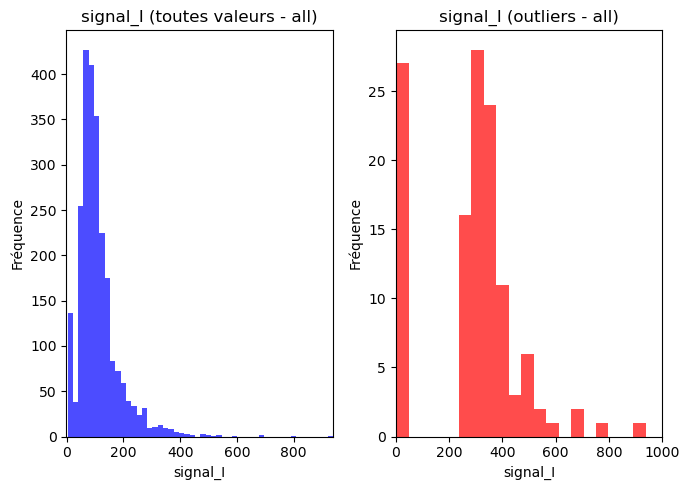

Index([ 367,  527, 1250, 1272, 1458, 1633, 1664, 1749, 1769, 2024,
       ...
       8245, 8596, 8732, 8771, 8937, 9063, 9144, 9183, 9352, 9390],
      dtype='int64', length=122)
122


In [86]:
fig, axs = plt.subplots(1, 2, figsize=(7, 5))

# Toutes les valeurs - df_implemented_all
axs[0].hist(df_implemented_all['signal_I'], bins=50, color='blue', alpha=0.7)
axs[0].set_title("signal_I (toutes valeurs - all)")
axs[0].set_xlabel("signal_I")
axs[0].set_xlim(-1, df_implemented_all['signal_I'].max())
axs[0].set_ylabel("Fréquence")

# Outliers - df_implemented_all
axs[1].hist(df_implemented_all[df_implemented_all['signal_I_outlier']]['signal_I'], bins=20, color='red', alpha=0.7)
axs[1].set_title("signal_I (outliers - all)")
axs[1].set_xlabel("signal_I")
axs[1].set_ylabel("Fréquence")
axs[1].set_xlim(-1, 1000)


plt.tight_layout()
plt.show()

print(df_implemented_all[df_implemented_all['signal_I_outlier']][['signal_I']].index)
print(len(df_implemented_all[df_implemented_all['signal_I_outlier']]))

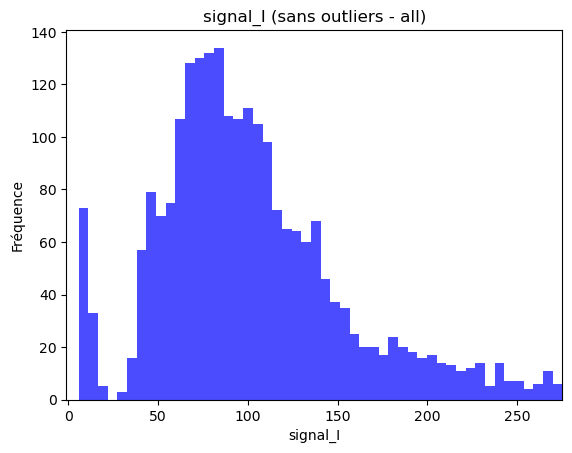

In [87]:
df_implemented_all = df_implemented_all[~df_implemented_all['signal_I_outlier']]

plt.hist(df_implemented_all['signal_I'], bins=50, color='blue', alpha=0.7)
plt.title("signal_I (sans outliers - all)")
plt.xlabel("signal_I")
plt.xlim(-1, df_implemented_all['signal_I'].max())
plt.ylabel("Fréquence")
plt.show()

### Longueur de détection

In [88]:
df_implemented_all['duree_suivi'] = df_implemented_all['tracks_smooth'].apply(calculer_duree_suivi)

df_implemented_all['nb_points'] = df_implemented_all['tracks_smooth'].apply(lambda x: len(x[0]) if isinstance(x, (list, tuple)) and len(x) >= 2 else 0)

In [89]:
df_implemented_all = isolation_forest(df_implemented_all, 'duree_suivi')

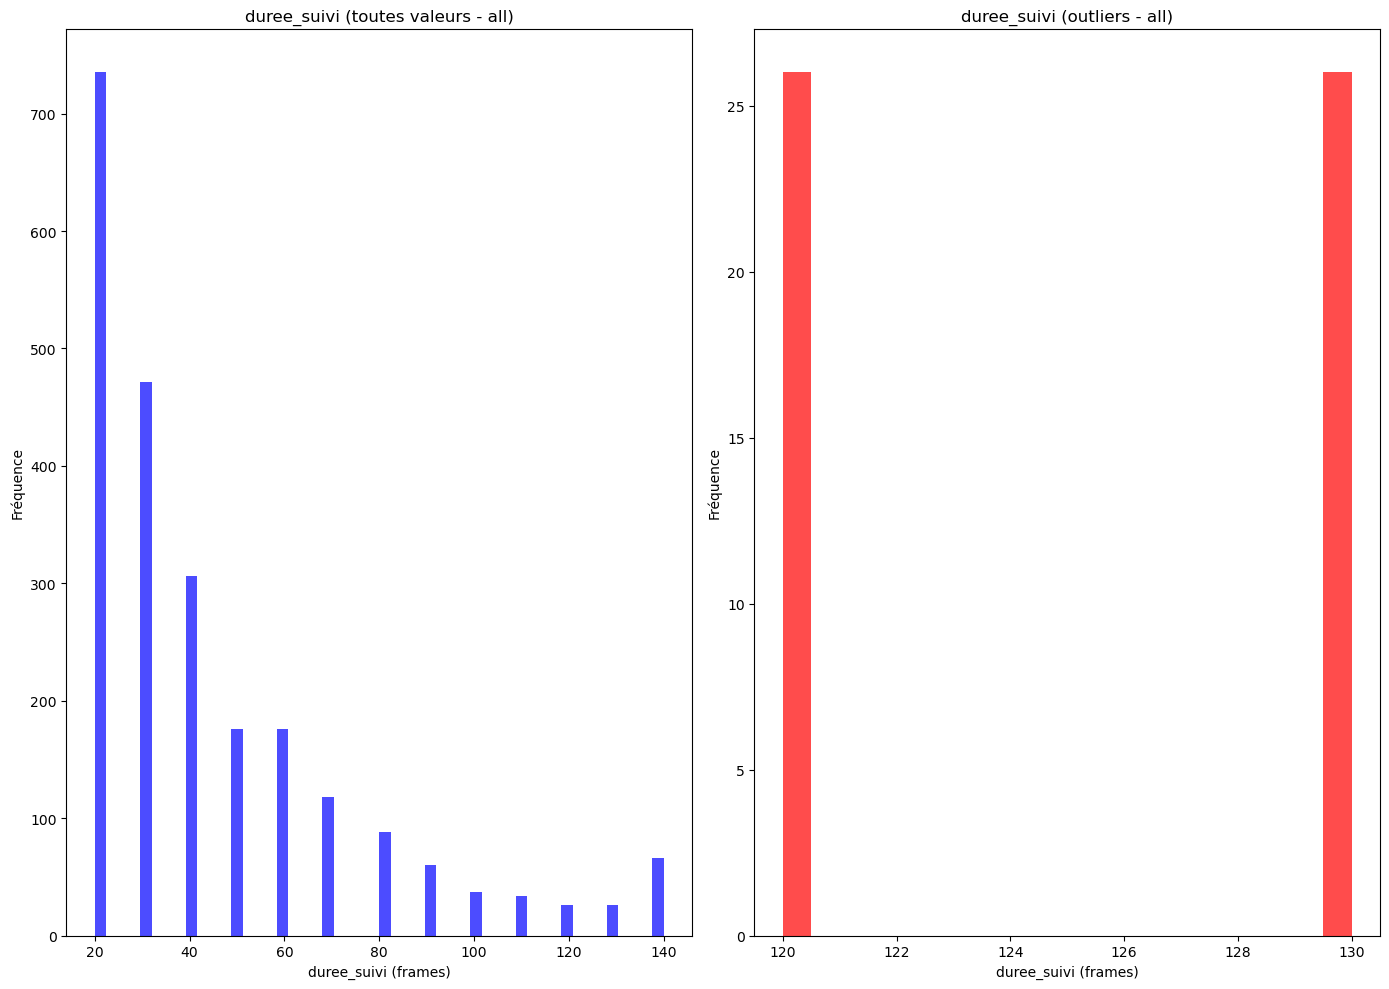

Index([ 284,  333,  621,  964, 2459, 2864, 2964, 3149, 3189, 3196, 3269, 3270,
       3520, 3593, 3686, 3730, 3754, 3970, 4411, 4506, 4676, 4748, 4951, 6500,
       6861, 6878, 6937, 7386, 7487, 7503, 7663, 7813, 8135, 8170, 8323, 8330,
       8406, 8918, 8975, 9018, 9067, 9076, 9115, 9207, 9287, 9361, 9441, 9462,
       9657, 9670, 9757, 9895],
      dtype='int64')
52


In [90]:
fig, axs = plt.subplots(1, 2, figsize=(14, 10))

# Toutes les valeurs - df_implemented_all
axs[0].hist(df_implemented_all['duree_suivi'], bins=50, color='blue', alpha=0.7)
axs[0].set_title("duree_suivi (toutes valeurs - all)")
axs[0].set_xlabel("duree_suivi (frames)")
axs[0].set_ylabel("Fréquence")

# Outliers - df_implemented_all
axs[1].hist(df_implemented_all[df_implemented_all['duree_suivi_outlier']]['duree_suivi'], bins=20, color='red', alpha=0.7)
axs[1].set_title("duree_suivi (outliers - all)")
axs[1].set_xlabel("duree_suivi (frames)")
axs[1].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

print(df_implemented_all[df_implemented_all['duree_suivi_outlier']][['duree_suivi']].index)
print(len(df_implemented_all[df_implemented_all['duree_suivi_outlier']]))

In [91]:
df_implemented_all = df_implemented_all[~df_implemented_all['duree_suivi_outlier']]

# Fin du préprocessing

Une fois ce preprocessing terminé, on peut s'attaquer aux différentes questions d'intérêts présentes autour de ces données.

Mais avant de s'attaquer à ces questions, il faut créer un second dataframe excluant certaines données qui ne seront pas intéressante pour répondre à certaines questions précises. 

In [92]:
exclude_identifiers = ['C20250415_20250422-B2', 'C20250415_20250423-B1']
df_implemented_exclude = data_implementation_with_exclusion(
    df_implemented_all, 
    exclude_identifiers=exclude_identifiers
)

print(len(df_implemented_all), len(df_implemented_exclude))

Identifiants à exclure: ['C20250415_20250422-B2', 'C20250415_20250423-B1']
Lignes exclues: 36
2267 2231


# Questions d'intérêts

## Vitesse

In [93]:
df_implemented_all['speed'] = df_implemented_all['tracks_smooth'].apply(calculer_vitesse)
df_implemented_exclude['speed'] = df_implemented_exclude['tracks_smooth'].apply(calculer_vitesse)

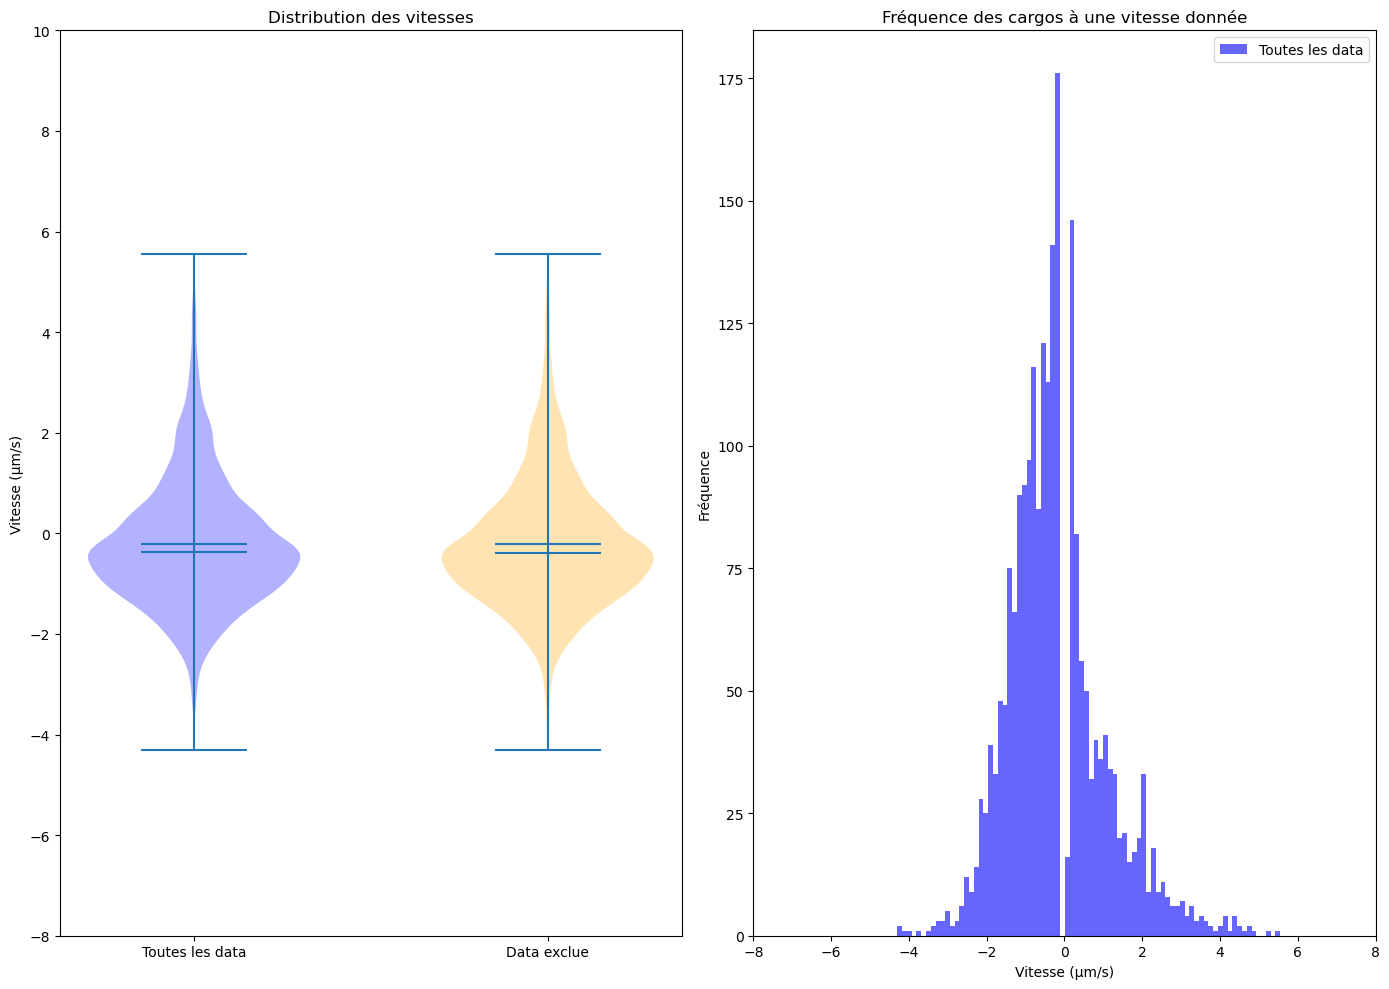

In [94]:
plt.figure(figsize=(14,10))
plt.subplot(1, 2, 1)

data = [df_implemented_all['speed'].dropna(), df_implemented_exclude['speed'].dropna()]
labels = ['Toutes les data', 'Data exclue']
violin = plt.violinplot(data, showmeans=True, showmedians=True, widths=0.6)
plt.xticks([1, 2], labels)
violin['bodies'][0].set_facecolor('blue')
violin['bodies'][1].set_facecolor('orange')
plt.ylabel('Vitesse (µm/s)')
plt.title('Distribution des vitesses')
plt.ylim(-8, 10)
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.hist(df_implemented_all['speed'].dropna(), bins=80, alpha=0.6, label='Toutes les data', color='blue')
plt.xlabel('Vitesse (µm/s)')
plt.ylabel('Fréquence')
plt.title('Fréquence des cargos à une vitesse donnée')
plt.xlim(-8, 8)
plt.legend()
plt.tight_layout()

plt.show()

In [95]:
print("\nData avec partie exclue :")
print(f"Vitesses non-nulles : {df_implemented_exclude['speed'].notna().sum()}", f"& Nombre de vitesse totales : {len(df_implemented_exclude['speed'])}")
print(f"Vitesse moyenne : {df_implemented_exclude['speed'].mean():.2f} µm/s")
print(f"Vitesse médiane : {df_implemented_exclude['speed'].median():.2f} µm/s")
print(f"Vitesse min : {df_implemented_exclude['speed'].min():.2f} µm/s", f"& vitesse max : {df_implemented_exclude['speed'].max():.2f} µm/s")


Data avec partie exclue :
Vitesses non-nulles : 2231 & Nombre de vitesse totales : 2231
Vitesse moyenne : -0.22 µm/s
Vitesse médiane : -0.39 µm/s
Vitesse min : -4.30 µm/s & vitesse max : 5.55 µm/s


### Répartition vitesse par modalité

In [96]:
stats_vitesse_par_modalite(df_implemented_exclude, "Données exclues")


Statistiques descriptives (Données exclues) ---

Front d'onde (n=75)
  Moyenne : -0.04 µm/s
  Médiane : -0.15 µm/s
  Min     : -0.90 µm/s
  Max     : 0.75 µm/s
  Écart-type : 0.32 µm/s
  Quartiles : [-0.2500425 -0.14995    0.2000475]

Fluorescence (n=2156)
  Moyenne : -0.23 µm/s
  Médiane : -0.42 µm/s
  Min     : -4.30 µm/s
  Max     : 5.55 µm/s
  Écart-type : 1.30 µm/s
  Quartiles : [-1.05005 -0.41998  0.4125 ]


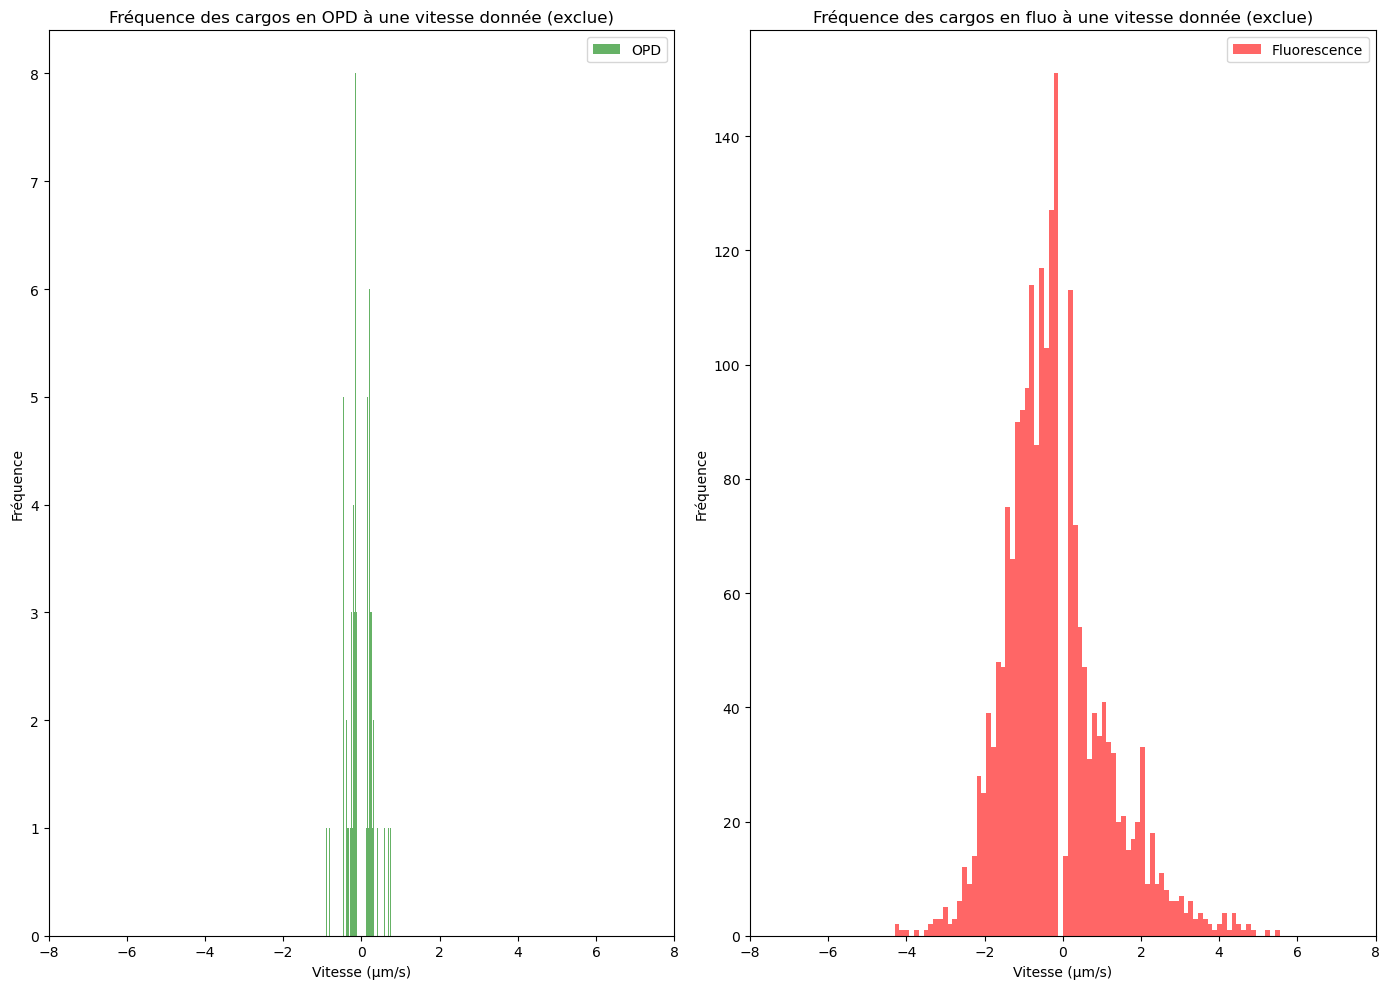

In [97]:
plt.figure(figsize=(14, 10))
plt.subplot(1, 2, 1)
opd_speeds_exclude = df_implemented_exclude[df_implemented_exclude['ID_modality'] == 1]['speed'].dropna()
fluo_speeds_exclude = df_implemented_exclude[df_implemented_exclude['ID_modality'] == 2]['speed'].dropna()

plt.hist(opd_speeds_exclude, bins=80, alpha=0.6, label='OPD', color='green')
plt.xlabel('Vitesse (µm/s)')
plt.ylabel('Fréquence')
plt.title('Fréquence des cargos en OPD à une vitesse donnée (exclue)')
plt.xlim(-8, 8)
plt.legend()
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.hist(fluo_speeds_exclude, bins=80, alpha=0.6, label='Fluorescence', color='red')
plt.xlabel('Vitesse (µm/s)')
plt.ylabel('Fréquence')
plt.title('Fréquence des cargos en fluo à une vitesse donnée (exclue)')
plt.xlim(-8, 8)
plt.legend()
plt.tight_layout()

### Statistiques 

In [98]:
# Extraction des vitesses par modalité
opd_speeds = df_implemented_exclude[df_implemented_exclude['ID_modality'] == 1]['speed'].dropna()
fluo_speeds = df_implemented_exclude[df_implemented_exclude['ID_modality'] == 2]['speed'].dropna()

print("Nombre d'observations par modalité :")
print(f"Nombre d'observations OPD: {len(opd_speeds)}")
print(f"Nombre d'observations Fluorescence: {len(fluo_speeds)}")
print()

# Tests de normalité
print("Tests de normalité : ")
shapiro_opd = stats.shapiro(opd_speeds)
shapiro_fluo = stats.shapiro(fluo_speeds)
print(f"Test de Shapiro-Wilk OPD: W={shapiro_opd.statistic:.4f}, p-value={shapiro_opd.pvalue:.2e}")
if shapiro_opd.pvalue < 0.05:
    print("-> La distribution des vitesses OPD n'est pas normale (p < 0.05)")
print(f"Test de Shapiro-Wilk Fluo: W={shapiro_fluo.statistic:.4f}, p-value={shapiro_fluo.pvalue:.2e}")
if shapiro_fluo.pvalue < 0.05:
    print("-> La distribution des vitesses Fluo n'est pas normale (p < 0.05)")
print()

# Tests d'hétérogénéité des variances
print("Tests d'hétérogénéité des variances : ")
levene_test = levene(opd_speeds, fluo_speeds)
bartlett_test = bartlett(opd_speeds, fluo_speeds)
print(f"Test de Levene: statistique={levene_test.statistic:.4f}, p-value={levene_test.pvalue:.2e}")
print(f"Test de Bartlett: statistique={bartlett_test.statistic:.4f}, p-value={bartlett_test.pvalue:.2e}")
print()

# Tests non paramétriques de comparaison de moyennes/médianes
print("Tests non paramétriques de comparaison de moyennes/médianes : ")

# Test de Mann-Whitney U (équivalent non paramétrique du t-test)
mann_whitney = stats.mannwhitneyu(opd_speeds, fluo_speeds, alternative='two-sided')
print(f"Test de Mann-Whitney U: U={mann_whitney.statistic:.0f}, p-value={mann_whitney.pvalue:.2e}")

# Test de Kolmogorov-Smirnov (teste si les distributions sont différentes)
ks_test = stats.ks_2samp(opd_speeds, fluo_speeds)
print(f"Test de Kolmogorov-Smirnov: D={ks_test.statistic:.4f}, p-value={ks_test.pvalue:.2e}")

# Calcul de la taille d'effet (r de Pearson pour Mann-Whitney)
n1, n2 = len(opd_speeds), len(fluo_speeds)
z_score = stats.norm.ppf(mann_whitney.pvalue/2)  # approximation
effect_size = abs(z_score) / np.sqrt(n1 + n2)
print(f"Taille d'effet (r): {effect_size:.3f}")
print()

print(f"\nTaille d'effet: {effect_interpretation} (r={effect_size:.3f})")

Nombre d'observations par modalité :
Nombre d'observations OPD: 75
Nombre d'observations Fluorescence: 2156

Tests de normalité : 
Test de Shapiro-Wilk OPD: W=0.9611, p-value=2.14e-02
-> La distribution des vitesses OPD n'est pas normale (p < 0.05)
Test de Shapiro-Wilk Fluo: W=0.9610, p-value=1.23e-23
-> La distribution des vitesses Fluo n'est pas normale (p < 0.05)

Tests d'hétérogénéité des variances : 
Test de Levene: statistique=46.8334, p-value=9.95e-12
Test de Bartlett: statistique=135.4659, p-value=2.61e-31

Tests non paramétriques de comparaison de moyennes/médianes : 
Test de Mann-Whitney U: U=100885, p-value=2.59e-04
Test de Kolmogorov-Smirnov: D=0.4427, p-value=1.93e-13
Taille d'effet (r): 0.077


Taille d'effet: petite (r=0.077)


Interprétation des résultats :
Tests d'hétérogénéité:
- Les variances sont significativement différentes (Levene p<0.05)

Tests de comparaison:
- Différence significative entre OPD et Fluorescence
- OPD présente des vitesses significativement plus élevées
- Les distributions sont significativement différentes

In [99]:
# Tests d'asymétrie et de forme des distributions
print("Tests d'asymétrie et de forme des distributions : ")

# Test de skewness (asymétrie)
skew_opd = stats.skew(opd_speeds)
skew_fluo = stats.skew(fluo_speeds)
print(f"Skewness OPD: {skew_opd:.3f}")
print(f"Skewness Fluo: {skew_fluo:.3f}")

# Test statistique de skewness (H0: skewness = 0)
skew_test_opd = stats.skewtest(opd_speeds)
skew_test_fluo = stats.skewtest(fluo_speeds)
print(f"Test de skewness OPD: z={skew_test_opd.statistic:.3f}, p-value={skew_test_opd.pvalue:.2e}")
print(f"Test de skewness Fluo: z={skew_test_fluo.statistic:.3f}, p-value={skew_test_fluo.pvalue:.2e}")

# Test de kurtosis (aplatissement)
kurt_opd = stats.kurtosis(opd_speeds)
kurt_fluo = stats.kurtosis(fluo_speeds)
print(f"Kurtosis OPD: {kurt_opd:.3f}")
print(f"Kurtosis Fluo: {kurt_fluo:.3f}")

# Test statistique de kurtosis (H0: kurtosis = 0, distribution normale)
kurt_test_opd = stats.kurtosistest(opd_speeds)
kurt_test_fluo = stats.kurtosistest(fluo_speeds)
print(f"Test de kurtosis OPD: z={kurt_test_opd.statistic:.3f}, p-value={kurt_test_opd.pvalue:.2e}")
print(f"Test de kurtosis Fluo: z={kurt_test_fluo.statistic:.3f}, p-value={kurt_test_fluo.pvalue:.2e}")

# Test de normalité combiné (D'Agostino-Pearson)
normaltest_opd = stats.normaltest(opd_speeds)
normaltest_fluo = stats.normaltest(fluo_speeds)
print(f"Test de normalité D'Agostino-Pearson OPD: chi2={normaltest_opd.statistic:.3f}, p-value={normaltest_opd.pvalue:.2e}")
print(f"Test de normalité D'Agostino-Pearson Fluo: chi2={normaltest_fluo.statistic:.3f}, p-value={normaltest_fluo.pvalue:.2e}")
print()

# Interprétation de l'asymétrie
print("Interprétration :")
def interpret_skewness(skew_value, test_result, modality):
    if abs(skew_value) < 0.5:
        asymmetry = "approximativement symétrique"
    elif 0.5 <= abs(skew_value) < 1:
        asymmetry = "modérément asymétrique"
    else:
        asymmetry = "fortement asymétrique"
    
    direction = "vers la droite (queue à droite)" if skew_value > 0 else "vers la gauche (queue à gauche)"
    
    significance = "significativement" if test_result.pvalue < 0.05 else "non significativement"
    
    print(f"{modality}: Distribution {asymmetry}")
    if abs(skew_value) > 0.1:
        print(f"  - Asymétrie {direction}")
    print(f"  - L'asymétrie est {significance} différente de 0 (p={test_result.pvalue:.4f})")

interpret_skewness(skew_opd, skew_test_opd, "OPD")
interpret_skewness(skew_fluo, skew_test_fluo, "Fluorescence")

def interpret_kurtosis(kurt_value, test_result, modality):
    if abs(kurt_value) < 0.5:
        shape = "proche d'une distribution normale"
    elif kurt_value > 0.5:
        shape = "plus pointue qu'une distribution normale (leptokurtique)"
    else:
        shape = "plus aplatie qu'une distribution normale (platykurtique)"
    
    significance = "significativement" if test_result.pvalue < 0.05 else "non significativement"
    
    print(f"{modality}: Distribution {shape}")
    print(f"  - L'aplatissement est {significance} différent d'une normale (p={test_result.pvalue:.4f})")

print()
interpret_kurtosis(kurt_opd, kurt_test_opd, "OPD")
interpret_kurtosis(kurt_fluo, kurt_test_fluo, "Fluorescence")

Tests d'asymétrie et de forme des distributions : 
Skewness OPD: -0.004
Skewness Fluo: 0.807
Test de skewness OPD: z=-0.014, p-value=9.89e-01
Test de skewness Fluo: z=13.575, p-value=5.65e-42
Kurtosis OPD: -0.082
Kurtosis Fluo: 1.307
Test de kurtosis OPD: z=0.194, p-value=8.46e-01
Test de kurtosis Fluo: z=7.870, p-value=3.54e-15
Test de normalité D'Agostino-Pearson OPD: chi2=0.038, p-value=9.81e-01
Test de normalité D'Agostino-Pearson Fluo: chi2=246.215, p-value=3.43e-54

Interprétration :
OPD: Distribution approximativement symétrique
  - L'asymétrie est non significativement différente de 0 (p=0.9886)
Fluorescence: Distribution modérément asymétrique
  - Asymétrie vers la droite (queue à droite)
  - L'asymétrie est significativement différente de 0 (p=0.0000)

OPD: Distribution proche d'une distribution normale
  - L'aplatissement est non significativement différent d'une normale (p=0.8458)
Fluorescence: Distribution plus pointue qu'une distribution normale (leptokurtique)
  - L'apla

## Crossdétection

In [100]:
df_implemented_exclude = nettoyer_crossdetection_object(df_implemented_exclude)

particules_crossdetectees(df_implemented_exclude)

Nombre de valeurs True: 170 et nombre de valeurs False : 2061
Nombre de particules: 2231
Nombre de particules crossdétectées: 170 (7.6%)


(                               ID_IDn                    ID_acqTag  ID_acqN  \
 48      C20250429_20250506-B6_ACQ0149  C20250429_20250506-B6_ACQ01        1   
 54      C20250429_20250506-B6_ACQ0155  C20250429_20250506-B6_ACQ01        1   
 80      C20250429_20250506-B6_ACQ0281  C20250429_20250506-B6_ACQ02        2   
 90      C20250429_20250506-B6_ACQ0291  C20250429_20250506-B6_ACQ02        2   
 95      C20250429_20250506-B6_ACQ0296  C20250429_20250506-B6_ACQ02        2   
 ...                               ...                          ...      ...   
 9453  C20250415_20250422-B5_ACQ212679  C20250415_20250422-B5_ACQ21       21   
 9558  C20250415_20250422-B5_ACQ222784  C20250415_20250422-B5_ACQ22       22   
 9750  C20250415_20250422-B5_ACQ252976  C20250415_20250422-B5_ACQ25       25   
 9832  C20250415_20250422-B5_ACQ263058  C20250415_20250422-B5_ACQ26       26   
 9948  C20250415_20250422-B5_ACQ283174  C20250415_20250422-B5_ACQ28       28   
 
       ID_modality                    

In [101]:
cross_detected_exclude, total_particules_exclude, nb_cross_exclude = particules_crossdetectees(df_implemented_exclude)

Nombre de particules: 2231
Nombre de particules crossdétectées: 170 (7.6%)


In [102]:
df_non_cross = df_implemented_exclude[df_implemented_exclude['crossdetection_bool_clean'] == False]

print("Répartition des particules non crossdétectées par modalité :")

opd_non_cross = df_non_cross[df_non_cross['ID_modality'] == 1]
fluo_non_cross = df_non_cross[df_non_cross['ID_modality'] == 2]

total_non_cross = len(df_non_cross)
nb_opd_non_cross = len(opd_non_cross)
nb_fluo_non_cross = len(fluo_non_cross)

pct_opd_non_cross = (nb_opd_non_cross / total_non_cross) * 100
pct_fluo_non_cross = (nb_fluo_non_cross / total_non_cross) * 100

print(f"Total particules non crossdétectées : {total_non_cross}")
print(f"OPD (modalité 1) : {nb_opd_non_cross} particules ({pct_opd_non_cross:.1f}%)")
print(f"Fluorescence (modalité 2) : {nb_fluo_non_cross} particules ({pct_fluo_non_cross:.1f}%)")

# Comparaison avec la répartition globale
print("\nComparaison avec la répartition globale :")

total_global = len(df_implemented_exclude)
opd_global = len(df_implemented_exclude[df_implemented_exclude['ID_modality'] == 1])
fluo_global = len(df_implemented_exclude[df_implemented_exclude['ID_modality'] == 2])

pct_opd_global = (opd_global / total_global) * 100
pct_fluo_global = (fluo_global / total_global) * 100

print(f"Répartition globale :")
print(f"OPD : {opd_global} particules ({pct_opd_global:.1f}%)")
print(f"Fluorescence : {fluo_global} particules ({pct_fluo_global:.1f}%)")

# Calculer l'enrichissement/appauvrissement
enrichissement_opd = pct_opd_non_cross / pct_opd_global
enrichissement_fluo = pct_fluo_non_cross / pct_fluo_global

print(f"\Comparaison à la population globale :")
print(f"OPD : {enrichissement_opd:.2f}x (par rapport à la population globale)")
print(f"Fluorescence : {enrichissement_fluo:.2f}x (par rapport à la population globale)")

Répartition des particules non crossdétectées par modalité :
Total particules non crossdétectées : 2061
OPD (modalité 1) : 68 particules (3.3%)
Fluorescence (modalité 2) : 1993 particules (96.7%)

Comparaison avec la répartition globale :
Répartition globale :
OPD : 75 particules (3.4%)
Fluorescence : 2156 particules (96.6%)
\Comparaison à la population globale :
OPD : 0.98x (par rapport à la population globale)
Fluorescence : 1.00x (par rapport à la population globale)


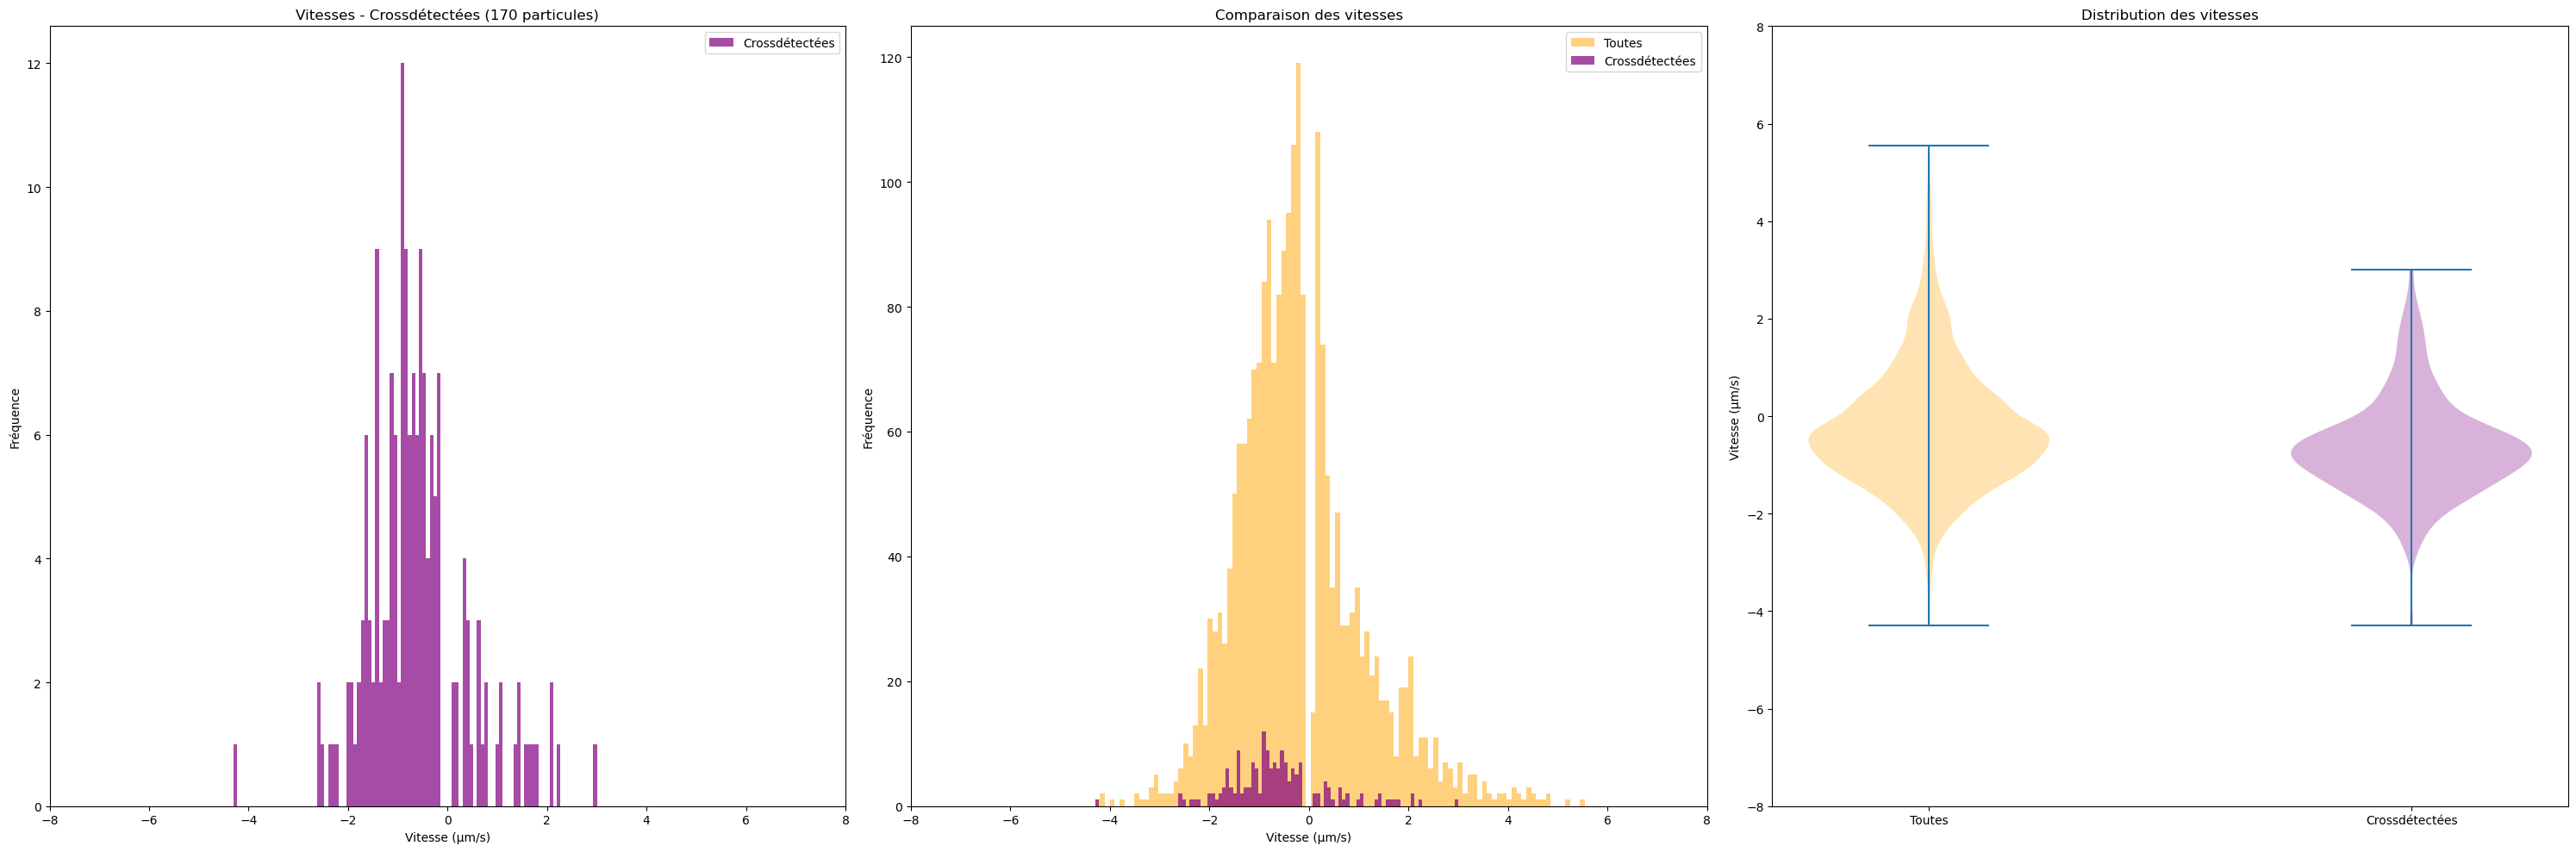

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(30, 10))

# Particules crossdétectées
axes[0].hist(cross_detected_exclude['speed'].dropna(), bins=100, alpha=0.7, color='purple', label='Crossdétectées')
axes[0].set_title(f'Vitesses - Crossdétectées ({nb_cross_exclude} particules)')
axes[0].set_xlabel('Vitesse (µm/s)')
axes[0].set_ylabel('Fréquence')
axes[0].set_xlim(-8, 8)
axes[0].legend()

# Particules crossdétectées et non-crossdétectées
axes[1].hist(df_implemented_exclude['speed'].dropna(), bins=100, alpha=0.5, label='Toutes', color='orange')
axes[1].hist(cross_detected_exclude['speed'].dropna(), bins=100, alpha=0.7, label='Crossdétectées', color='purple')
axes[1].set_title('Comparaison des vitesses')
axes[1].set_xlabel('Vitesse (µm/s)')
axes[1].set_ylabel('Fréquence')
axes[1].set_xlim(-8, 8)
axes[1].legend()

# Comparaison 
data_box = [df_implemented_exclude['speed'].dropna(), cross_detected_exclude['speed'].dropna()]
violinplot = axes[2].violinplot(data_box)
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(['Toutes', 'Crossdétectées'])
violinplot['bodies'][0].set_facecolor('orange')
violinplot['bodies'][1].set_facecolor('purple')
axes[2].set_title('Distribution des vitesses')
axes[2].set_ylabel('Vitesse (µm/s)')
axes[2].set_ylim(-8, 8)

plt.tight_layout()
plt.show()

In [104]:
print(métriques_crossdétectées(df_implemented_exclude, cross_detected_exclude))

                      Toutes  Crossdétectées
Nombre           2231.000000      170.000000
Vitesse moyenne    -0.219656       -0.634902
Vitesse médiane    -0.385757       -0.754975
Vitesse min        -4.300000       -4.300000
Vitesse max         5.549900        3.000000
Écart-type          1.278450        1.015321


### Stat

In [105]:
# Extraction des vitesses pour crossdétectés et non crossdétectés
cross_speeds = cross_detected_exclude['speed'].dropna()
non_cross_speeds = df_implemented_exclude[df_implemented_exclude['crossdetection_bool_clean'] == False]['speed'].dropna()

print("Analyse statistique des vitesses des particules crossdétectées vs non crossdétectées : ")
print(f"Nombre de particules crossdétectées: {len(cross_speeds)}")
print(f"Nombre de particules non crossdétectées: {len(non_cross_speeds)}")
print()

# Statistiques descriptives
print("Statistiques descriptives :")
print(f"Crossdétectées - Moyenne: {cross_speeds.mean():.3f} µm/s, Médiane: {cross_speeds.median():.3f} µm/s")
print(f"Crossdétectées - Écart-type: {cross_speeds.std():.3f} µm/s")
print(f"Non crossdétectées - Moyenne: {non_cross_speeds.mean():.3f} µm/s, Médiane: {non_cross_speeds.median():.3f} µm/s")
print(f"Non crossdétectées - Écart-type: {non_cross_speeds.std():.3f} µm/s")
print()

# Tests de normalité
print("Tests de normalité : ")
shapiro_cross = stats.shapiro(cross_speeds)
shapiro_non_cross = stats.shapiro(non_cross_speeds)
print(f"Test de Shapiro-Wilk Crossdétectées: W={shapiro_cross.statistic:.4f}, p-value={shapiro_cross.pvalue:.2e}")
print(f"Test de Shapiro-Wilk Non crossdétectées: W={shapiro_non_cross.statistic:.4f}, p-value={shapiro_non_cross.pvalue:.2e}")
print()

# Tests d'hétérogénéité des variances
print("Tests d'hétérogénéité des variances : ")
levene_test = levene(cross_speeds, non_cross_speeds)
bartlett_test = bartlett(cross_speeds, non_cross_speeds)
print(f"Test de Levene: statistique={levene_test.statistic:.4f}, p-value={levene_test.pvalue:.2e}")
print(f"Test de Bartlett: statistique={bartlett_test.statistic:.4f}, p-value={bartlett_test.pvalue:.2e}")
print()

# Tests non paramétriques de comparaison
print("Tests non paramétriques de comparaison : ")

# Test de Mann-Whitney U
mann_whitney = stats.mannwhitneyu(cross_speeds, non_cross_speeds, alternative='two-sided')
print(f"Test de Mann-Whitney U: U={mann_whitney.statistic:.0f}, p-value={mann_whitney.pvalue:.2e}")

# Test de Kolmogorov-Smirnov
ks_test = stats.ks_2samp(cross_speeds, non_cross_speeds)
print(f"Test de Kolmogorov-Smirnov: D={ks_test.statistic:.4f}, p-value={ks_test.pvalue:.2e}")

# Calcul de la taille d'effet
n1, n2 = len(cross_speeds), len(non_cross_speeds)
if mann_whitney.pvalue > 0:
    z_score = stats.norm.ppf(mann_whitney.pvalue/2)
    effect_size = abs(z_score) / np.sqrt(n1 + n2)
else:
    effect_size = 0
print(f"Taille d'effet (r): {effect_size:.3f}")
print()

# Tests d'asymétrie et de forme
print("Tests d'asymétrie et de forme : ")

# Test de skewness
skew_cross = stats.skew(cross_speeds)
skew_non_cross = stats.skew(non_cross_speeds)
print(f"Skewness Crossdétectées: {skew_cross:.3f}")
print(f"Skewness Non crossdétectées: {skew_non_cross:.3f}")

skew_test_cross = stats.skewtest(cross_speeds)
skew_test_non_cross = stats.skewtest(non_cross_speeds)
print(f"Test de skewness Crossdétectées: z={skew_test_cross.statistic:.3f}, p-value={skew_test_cross.pvalue:.2e}")
print(f"Test de skewness Non crossdétectées: z={skew_test_non_cross.statistic:.3f}, p-value={skew_test_non_cross.pvalue:.2e}")

# Test de kurtosis
kurt_cross = stats.kurtosis(cross_speeds)
kurt_non_cross = stats.kurtosis(non_cross_speeds)
print(f"Kurtosis Crossdétectées: {kurt_cross:.3f}")
print(f"Kurtosis Non crossdétectées: {kurt_non_cross:.3f}")

kurt_test_cross = stats.kurtosistest(cross_speeds)
kurt_test_non_cross = stats.kurtosistest(non_cross_speeds)
print(f"Test de kurtosis Crossdétectées: z={kurt_test_cross.statistic:.3f}, p-value={kurt_test_cross.pvalue:.2e}")
print(f"Test de kurtosis Non crossdétectées: z={kurt_test_non_cross.statistic:.3f}, p-value={kurt_test_non_cross.pvalue:.2e}")
print()

# Interprétation des résultats
print("Interprétation des résultats :")
alpha = 0.05

print("Tests d'hétérogénéité:")
if levene_test.pvalue < alpha:
    print("- Les variances sont significativement différentes (Levene p<0.05)")
else:
    print("- Les variances ne sont pas significativement différentes (Levene p≥0.05)")

print("\nTests de comparaison:")
if mann_whitney.pvalue < alpha:
    print(f"- Différence significative entre crossdétectées et non crossdétectées (Mann-Whitney p={mann_whitney.pvalue:.2e})")
    if cross_speeds.median() > non_cross_speeds.median():
        print("- Les particules crossdétectées présentent des vitesses significativement plus élevées")
    else:
        print("- Les particules non crossdétectées présentent des vitesses significativement plus élevées")
else:
    print(f"- Pas de différence significative entre crossdétectées et non crossdétectées (Mann-Whitney p={mann_whitney.pvalue:.2e})")

if ks_test.pvalue < alpha:
    print(f"- Les distributions sont significativement différentes (KS p={ks_test.pvalue:.2e})")
else:
    print(f"- Les distributions ne sont pas significativement différentes (KS p={ks_test.pvalue:.2e})")

# Interprétation de la taille d'effet
if effect_size < 0.1:
    effect_interpretation = "négligeable"
elif effect_size < 0.3:
    effect_interpretation = "petite"
elif effect_size < 0.5:
    effect_interpretation = "moyenne"
else:
    effect_interpretation = "grande"

print(f"\nTaille d'effet: {effect_interpretation} (r={effect_size:.3f})")

# Analyse des vitesses extrêmes
print("\nAnalyse des vitesses extrêmes :")
print(f"Vitesses crossdétectées - Min: {cross_speeds.min():.3f}, Max: {cross_speeds.max():.3f}")
print(f"Vitesses non crossdétectées - Min: {non_cross_speeds.min():.3f}, Max: {non_cross_speeds.max():.3f}")

# Pourcentages de vitesses dans différentes plages
def analyze_speed_ranges(speeds, name):
    total = len(speeds)
    slow = len(speeds[abs(speeds) < 1])
    medium = len(speeds[(abs(speeds) >= 1) & (abs(speeds) < 3)])
    fast = len(speeds[abs(speeds) >= 3])
    
    print(f"\n{name}:")
    print(f"  - Vitesses lentes (|v| < 1 µm/s): {slow} ({slow/total*100:.1f}%)")
    print(f"  - Vitesses moyennes (1 ≤ |v| < 3 µm/s): {medium} ({medium/total*100:.1f}%)")  
    print(f"  - Vitesses rapides (|v| ≥ 3 µm/s): {fast} ({fast/total*100:.1f}%)")

analyze_speed_ranges(cross_speeds, "Particules crossdétectées")
analyze_speed_ranges(non_cross_speeds, "Particules non crossdétectées")

Analyse statistique des vitesses des particules crossdétectées vs non crossdétectées : 
Nombre de particules crossdétectées: 170
Nombre de particules non crossdétectées: 2061

Statistiques descriptives :
Crossdétectées - Moyenne: -0.635 µm/s, Médiane: -0.755 µm/s
Crossdétectées - Écart-type: 1.015 µm/s
Non crossdétectées - Moyenne: -0.185 µm/s, Médiane: -0.343 µm/s
Non crossdétectées - Écart-type: 1.292 µm/s

Tests de normalité : 
Test de Shapiro-Wilk Crossdétectées: W=0.9490, p-value=8.18e-06
Test de Shapiro-Wilk Non crossdétectées: W=0.9630, p-value=1.54e-22

Tests d'hétérogénéité des variances : 
Test de Levene: statistique=12.0028, p-value=5.41e-04
Test de Bartlett: statistique=15.8376, p-value=6.90e-05

Tests non paramétriques de comparaison : 
Test de Mann-Whitney U: U=136280, p-value=1.44e-06
Test de Kolmogorov-Smirnov: D=0.2290, p-value=1.02e-07
Taille d'effet (r): 0.102

Tests d'asymétrie et de forme : 
Skewness Crossdétectées: 0.609
Skewness Non crossdétectées: 0.791
Test de 

## Cargo faisant demi-tours

In [106]:
df_implemented_exclude['demi_tour'] = df_implemented_exclude['tracks_smooth'].apply(detecter_demi_tour)
demi_tour_exclude = df_implemented_exclude[df_implemented_exclude['demi_tour'] == True]
print(f'Nombre de cargos qui font demi-tour (exclu): {len(demi_tour_exclude)} sur {len(df_implemented_exclude)} ({len(demi_tour_exclude)/len(df_implemented_exclude)*100:.1f}%)')

Nombre de cargos qui font demi-tour (exclu): 158 sur 2231 (7.1%)


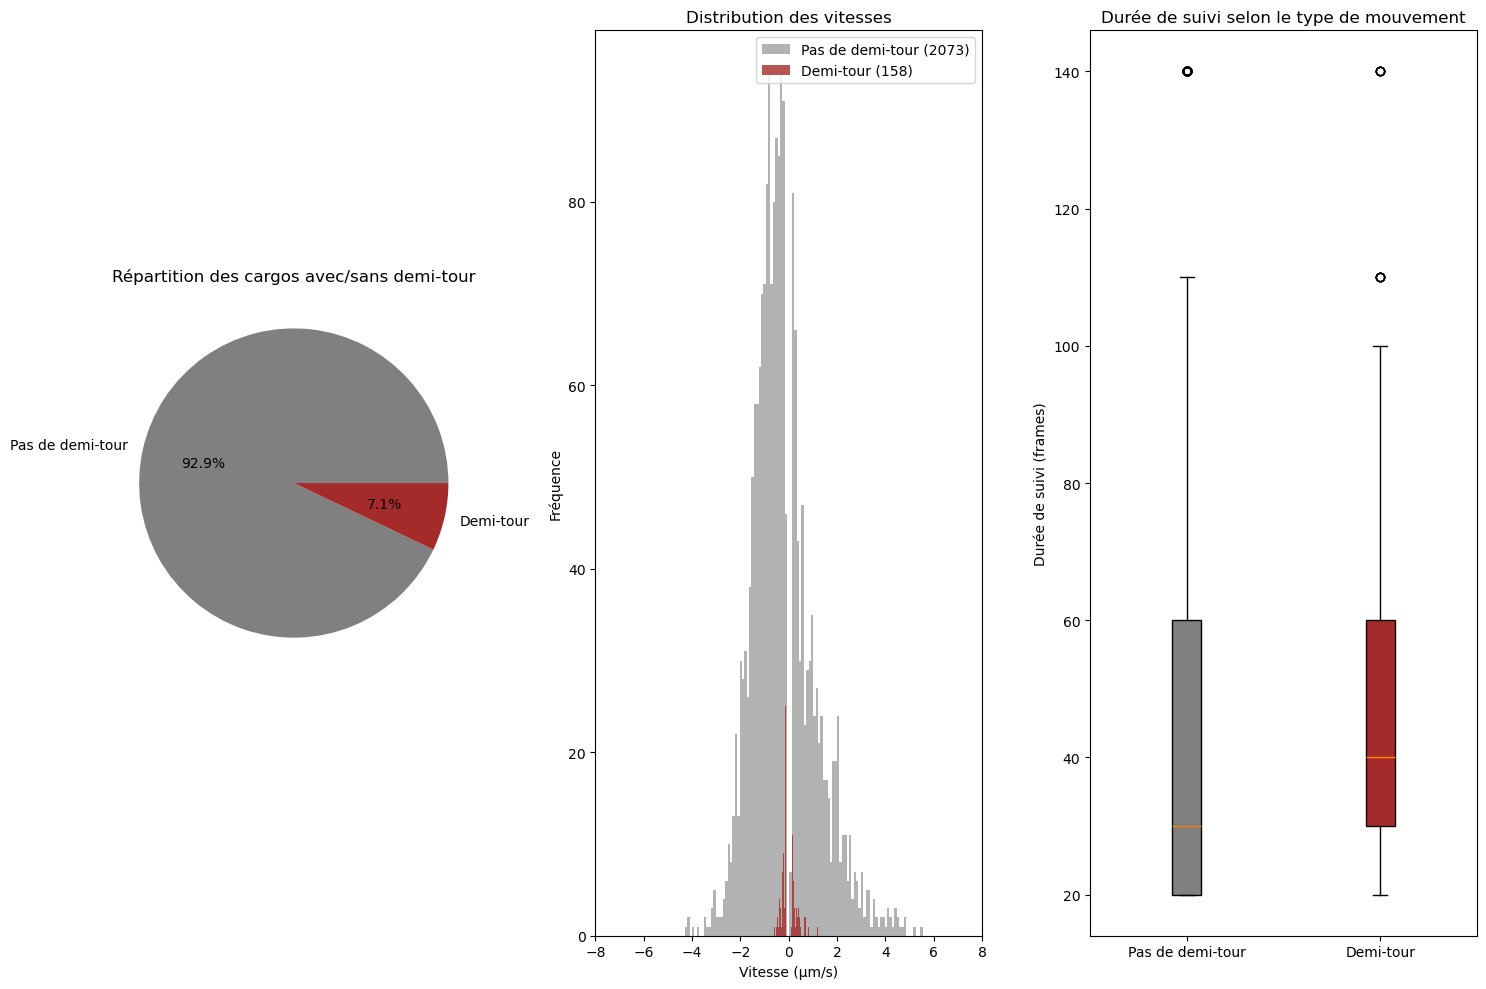

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))

# Répartition demi-tours / normal
demi_tour_counts = df_implemented_exclude['demi_tour'].value_counts()
axes[0].pie(demi_tour_counts.values, labels=['Pas de demi-tour', 'Demi-tour'], 
              autopct='%1.1f%%', colors=['grey', 'brown'])
axes[0].set_title('Répartition des cargos avec/sans demi-tour')

# Vitesses - demi-tours vs normaux
df_normal = df_implemented_exclude[df_implemented_exclude['demi_tour'] == False]
df_demi_tour = df_implemented_exclude[df_implemented_exclude['demi_tour'] == True]

axes[1].hist(df_normal['speed'].dropna(), bins=100, alpha=0.6, 
               label=f'Pas de demi-tour ({len(df_normal)})', color='grey')
if len(df_demi_tour) > 0:
    axes[1].hist(df_demi_tour['speed'].dropna(), bins=100, alpha=0.8, 
                   label=f'Demi-tour ({len(df_demi_tour)})', color='brown')
axes[1].set_xlabel('Vitesse (µm/s)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des vitesses')
axes[1].set_xlim(-8, 8)
axes[1].legend()

# Durée de suivi vs demi-tours
box_plot = axes[2].boxplot([df_normal['duree_suivi'].dropna(), 
                           df_demi_tour['duree_suivi'].dropna()], 
                          labels=['Pas de demi-tour', 'Demi-tour'], 
                          patch_artist=True)

# Définir les couleurs après création
box_plot['boxes'][0].set_facecolor('grey')
if len(box_plot['boxes']) > 1:
    box_plot['boxes'][1].set_facecolor('brown')

axes[2].set_ylabel('Durée de suivi (frames)')
axes[2].set_title('Durée de suivi selon le type de mouvement')

plt.tight_layout()
plt.show()

Répartition :
Normal: 2073 (92.9%)
Demi-tour : 158 (7.1%)


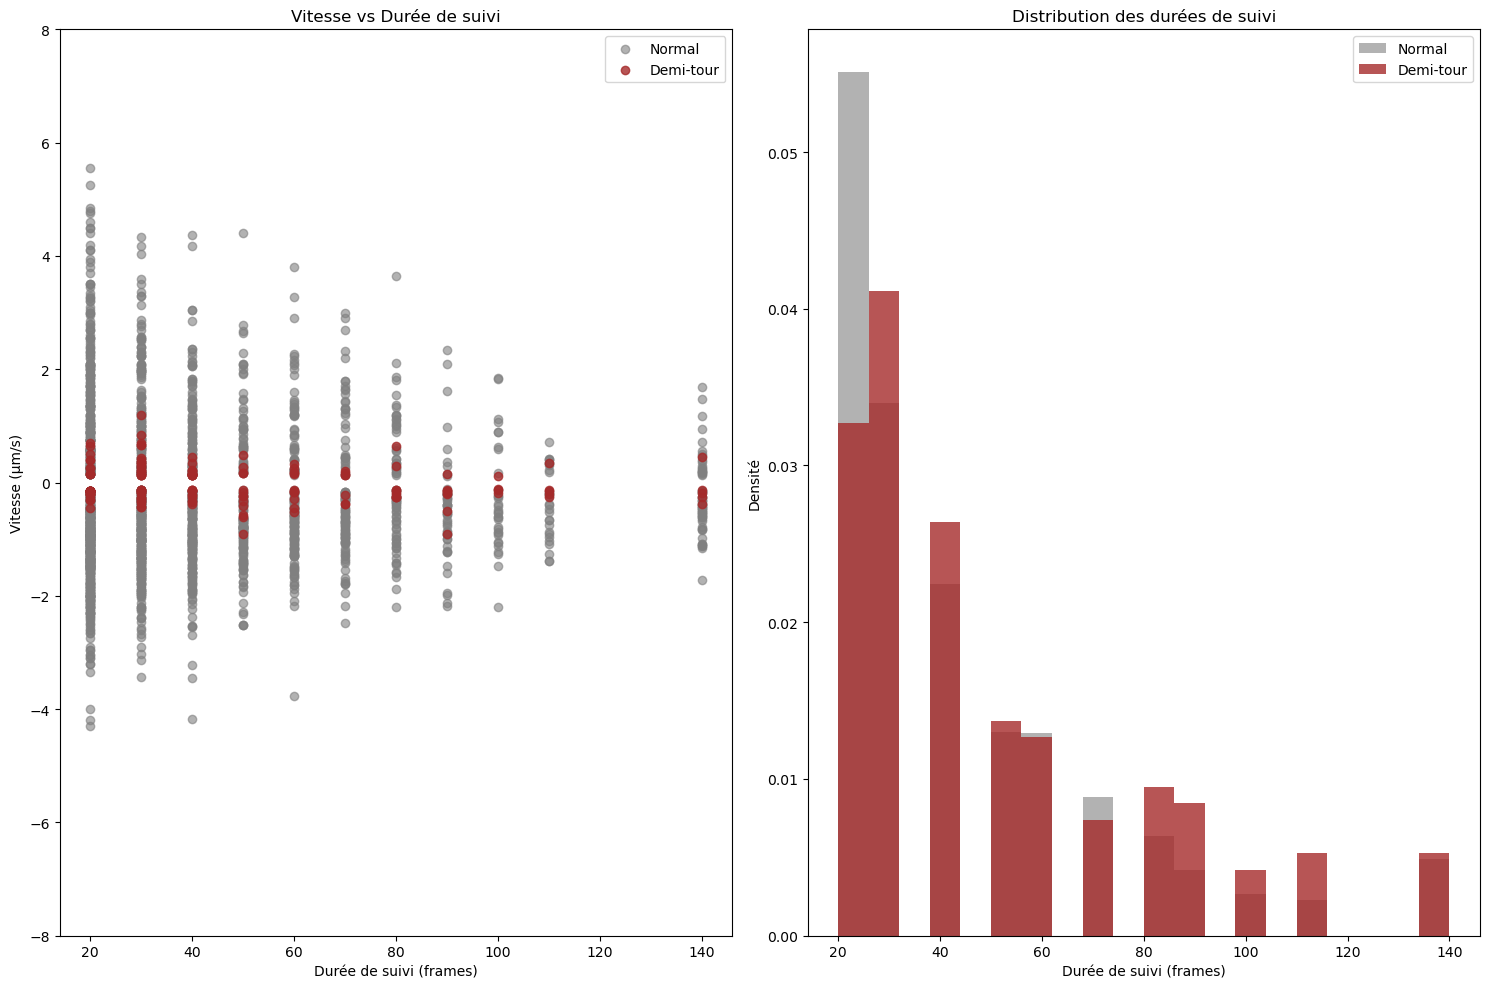


Statistiques comparatives :
Métrique        Normal (moy) Demi-tour (moy) Différence
------------------------------------------------------------
speed           -0.23        -0.02           -91.8     %
duree_suivi     42.90        48.99           14.2      %
nb_points       5.29         5.90            11.5      %


In [108]:
analyser_demi_tours_statistiques(df_implemented_exclude)

Répartition globale :
Normal: 2073 (92.9%)
Demi-tour : 158 (7.1%)

Répartition par modalité :
OPD (75 particules) :
  Normal: 51 (68.0%)
  Demi-tour: 24 (32.0%)
Fluorescence (2156 particules) :
  Normal: 2022 (93.8%)
  Demi-tour: 134 (6.2%)


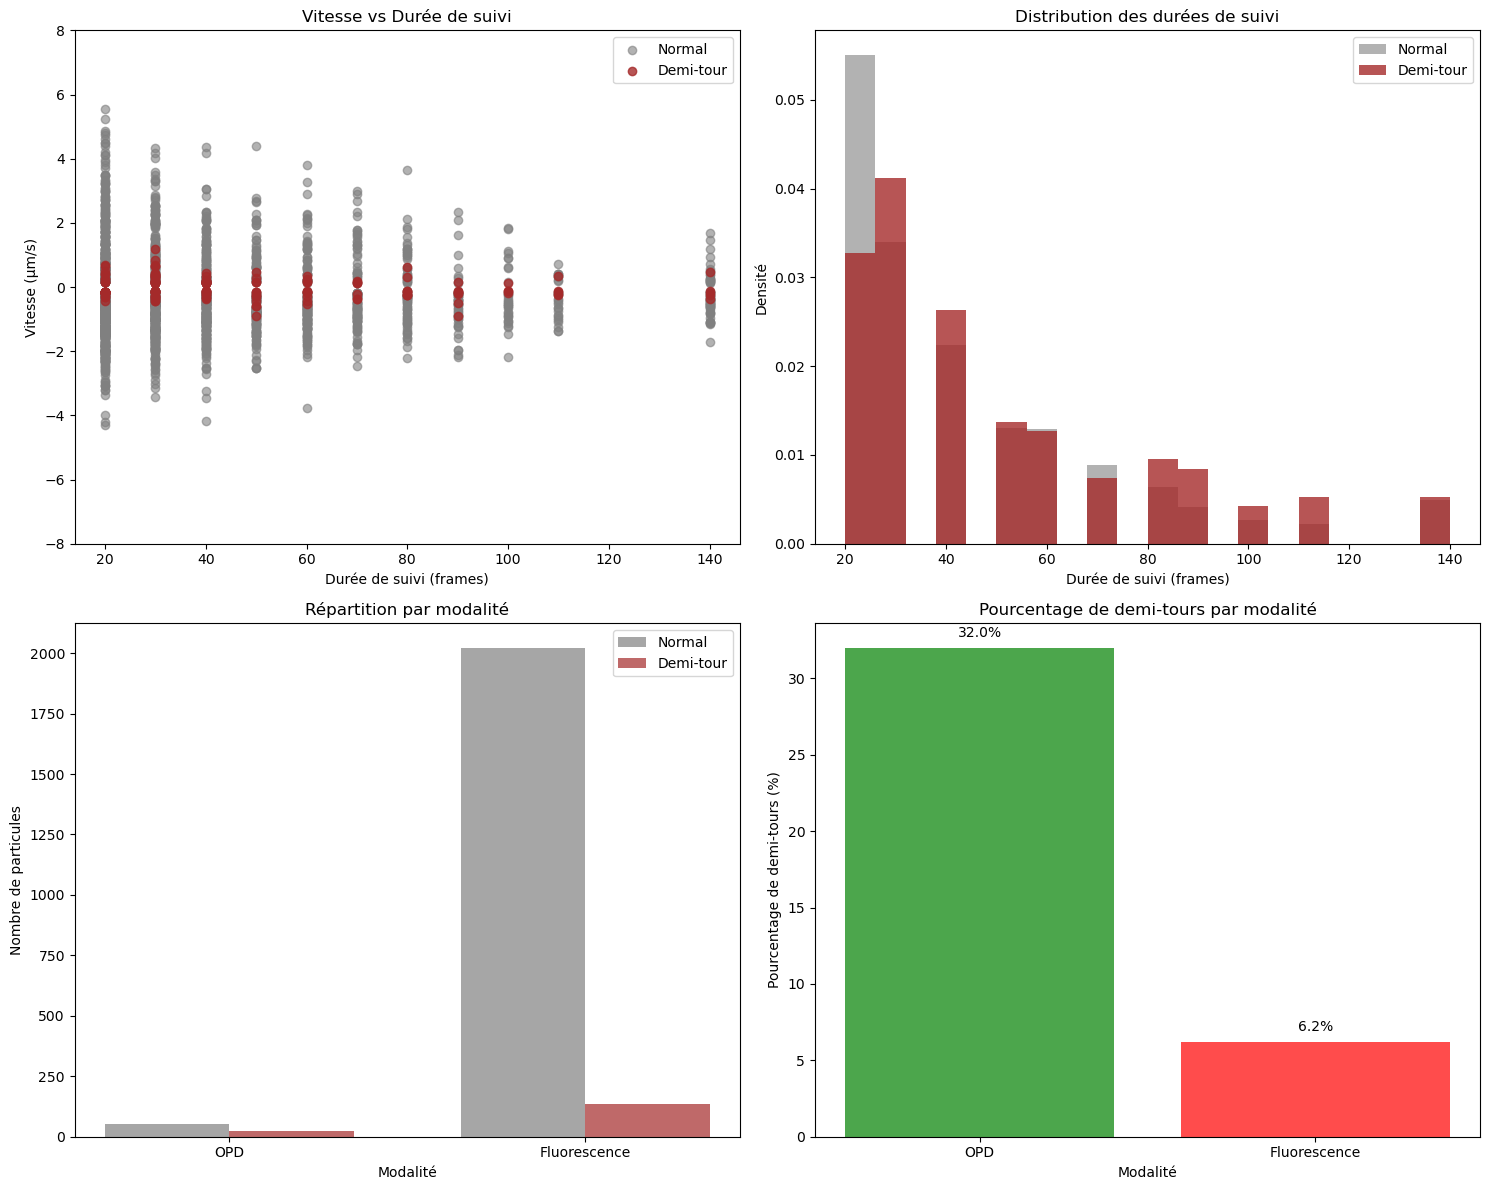


Statistiques comparatives globales :
Métrique        Normal (moy) Demi-tour (moy) Différence
------------------------------------------------------------
speed           -0.23        -0.02           -91.8     %
duree_suivi     42.90        48.99           14.2      %
nb_points       5.29         5.90            11.5      %

Statistiques par modalité :

OPD :
Métrique        Normal (moy) Demi-tour (moy) Différence
------------------------------------------------------------
speed           -0.05        -0.02           -55.5     %
duree_suivi     29.02        35.83           23.5      %
nb_points       3.90         4.58            17.5      %

Fluorescence :
Métrique        Normal (moy) Demi-tour (moy) Différence
------------------------------------------------------------
speed           -0.24        -0.02           -92.2     %
duree_suivi     43.25        51.34           18.7      %
nb_points       5.32         6.13            15.2      %


In [109]:
def analyser_demi_tours_statistiques(df):
    df_normal = df[df['demi_tour'] == False]
    df_demi_tour = df[df['demi_tour'] == True]
    
    print(f"Répartition globale :")
    print(f"Normal: {len(df_normal)} ({len(df_normal)/len(df)*100:.1f}%)")
    print(f"Demi-tour : {len(df_demi_tour)} ({len(df_demi_tour)/len(df)*100:.1f}%)")
    
    # Répartition par modalité
    if 'ID_modality' in df.columns:
        print(f"\nRépartition par modalité :")
        modalites = {1: "OPD", 2: "Fluorescence"}
        
        for modalite_id, modalite_nom in modalites.items():
            df_modalite = df[df['ID_modality'] == modalite_id]
            if len(df_modalite) > 0:
                normal_modalite = df_modalite[df_modalite['demi_tour'] == False]
                demi_tour_modalite = df_modalite[df_modalite['demi_tour'] == True]
                
                pct_normal = len(normal_modalite) / len(df_modalite) * 100
                pct_demi_tour = len(demi_tour_modalite) / len(df_modalite) * 100
                
                print(f"{modalite_nom} ({len(df_modalite)} particules) :")
                print(f"  Normal: {len(normal_modalite)} ({pct_normal:.1f}%)")
                print(f"  Demi-tour: {len(demi_tour_modalite)} ({pct_demi_tour:.1f}%)")
    
    # Comparaison des métriques
    metriques = ['speed', 'duree_suivi', 'nb_points']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Vitesse vs durée avec couleur selon demi-tour
    axes[0,0].scatter(df_normal['duree_suivi'], df_normal['speed'], 
                      alpha=0.6, label='Normal', color='grey')
    axes[0,0].scatter(df_demi_tour['duree_suivi'], df_demi_tour['speed'], 
                      alpha=0.8, label='Demi-tour', color='brown')
    axes[0,0].set_xlabel('Durée de suivi (frames)')
    axes[0,0].set_ylabel('Vitesse (µm/s)')
    axes[0,0].set_title('Vitesse vs Durée de suivi')
    axes[0,0].set_ylim(-8, 8)
    axes[0,0].legend()
    
    # Distribution des durées
    axes[0,1].hist(df_normal['duree_suivi'].dropna(), bins=20, alpha=0.6, 
                   label='Normal', density=True, color='grey')
    axes[0,1].hist(df_demi_tour['duree_suivi'].dropna(), bins=20, alpha=0.8, 
                   label='Demi-tour', density=True, color='brown')
    axes[0,1].set_xlabel('Durée de suivi (frames)')
    axes[0,1].set_ylabel('Densité')
    axes[0,1].set_title('Distribution des durées de suivi')
    axes[0,1].legend()
    
    # Répartition par modalité - graphique en barres
    if 'ID_modality' in df.columns:
        modalite_data = []
        labels = []
        
        for modalite_id, modalite_nom in modalites.items():
            df_modalite = df[df['ID_modality'] == modalite_id]
            if len(df_modalite) > 0:
                normal_count = len(df_modalite[df_modalite['demi_tour'] == False])
                demi_tour_count = len(df_modalite[df_modalite['demi_tour'] == True])
                modalite_data.append([normal_count, demi_tour_count])
                labels.append(modalite_nom)
        
        if modalite_data:
            modalite_data = np.array(modalite_data)
            x = np.arange(len(labels))
            width = 0.35
            
            axes[1,0].bar(x - width/2, modalite_data[:, 0], width, 
                         label='Normal', color='grey', alpha=0.7)
            axes[1,0].bar(x + width/2, modalite_data[:, 1], width, 
                         label='Demi-tour', color='brown', alpha=0.7)
            axes[1,0].set_xlabel('Modalité')
            axes[1,0].set_ylabel('Nombre de particules')
            axes[1,0].set_title('Répartition par modalité')
            axes[1,0].set_xticks(x)
            axes[1,0].set_xticklabels(labels)
            axes[1,0].legend()
        
        # Pourcentage de demi-tours par modalité
        pourcentages = []
        for modalite_id, modalite_nom in modalites.items():
            df_modalite = df[df['ID_modality'] == modalite_id]
            if len(df_modalite) > 0:
                pct_demi_tour = len(df_modalite[df_modalite['demi_tour'] == True]) / len(df_modalite) * 100
                pourcentages.append(pct_demi_tour)
        
        if pourcentages:
            axes[1,1].bar(labels, pourcentages, color=['green', 'red'], alpha=0.7)
            axes[1,1].set_xlabel('Modalité')
            axes[1,1].set_ylabel('Pourcentage de demi-tours (%)')
            axes[1,1].set_title('Pourcentage de demi-tours par modalité')
            
            # Ajouter les valeurs sur les barres
            for i, v in enumerate(pourcentages):
                axes[1,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Tableau de statistiques globales
    print(f"\nStatistiques comparatives globales :")
    print(f"{'Métrique':<15} {'Normal (moy)':<12} {'Demi-tour (moy)':<15} {'Différence':<10}")
    print("-" * 60)
    for metrique in metriques:
        if metrique in df.columns:
            moy_normal = df_normal[metrique].mean()
            moy_demi_tour = df_demi_tour[metrique].mean()
            diff = ((moy_demi_tour - moy_normal) / moy_normal * 100) if moy_normal != 0 else 0
            print(f"{metrique:<15} {moy_normal:<12.2f} {moy_demi_tour:<15.2f} {diff:<10.1f}%")
    
    # Tableau de statistiques par modalité
    if 'ID_modality' in df.columns:
        print(f"\nStatistiques par modalité :")
        for modalite_id, modalite_nom in modalites.items():
            df_modalite = df[df['ID_modality'] == modalite_id]
            if len(df_modalite) > 0:
                print(f"\n{modalite_nom} :")
                df_normal_mod = df_modalite[df_modalite['demi_tour'] == False]
                df_demi_tour_mod = df_modalite[df_modalite['demi_tour'] == True]
                
                print(f"{'Métrique':<15} {'Normal (moy)':<12} {'Demi-tour (moy)':<15} {'Différence':<10}")
                print("-" * 60)
                for metrique in metriques:
                    if metrique in df.columns and len(df_demi_tour_mod) > 0:
                        moy_normal = df_normal_mod[metrique].mean()
                        moy_demi_tour = df_demi_tour_mod[metrique].mean()
                        diff = ((moy_demi_tour - moy_normal) / moy_normal * 100) if moy_normal != 0 else 0
                        print(f"{metrique:<15} {moy_normal:<12.2f} {moy_demi_tour:<15.2f} {diff:<10.1f}%")

analyser_demi_tours_statistiques(df_implemented_exclude)

### Stat

Analyse complète des vitesses - Demi-tours vs Normaux
Total particules: 2231
Particules normales: 2073 (92.9%)
Particules demi-tours: 158 (7.1%)

1. Analyse globale des vitesses (Demi-tours vs Normal)
Statistiques descriptives:
Normal - Moyenne: -0.235 µm/s, Médiane: -0.450 µm/s
Normal - Écart-type: 1.322 µm/s
Demi-tour - Moyenne: -0.019 µm/s, Médiane: -0.133 µm/s
Demi-tour - Écart-type: 0.321 µm/s

Test Mann-Whitney U global: U=118155, p-value=5.10e-09
Test de Levene global: statistique=105.8522, p-value=2.75e-24

2. Analyse par modalité :

OPD (75 particules):
  Normal: 51 particules
  Demi-tour: 24 particules
  Normal - Moyenne: -0.049 µm/s, Médiane: -0.150 µm/s
  Demi-tour - Moyenne: -0.022 µm/s, Médiane: -0.142 µm/s
  Test Mann-Whitney: p-value=7.55e-01

Fluorescence (2156 particules):
  Normal: 2022 particules
  Demi-tour: 134 particules
  Normal - Moyenne: -0.240 µm/s, Médiane: -0.500 µm/s
  Demi-tour - Moyenne: -0.019 µm/s, Médiane: -0.133 µm/s
  Test Mann-Whitney: p-value=4.42

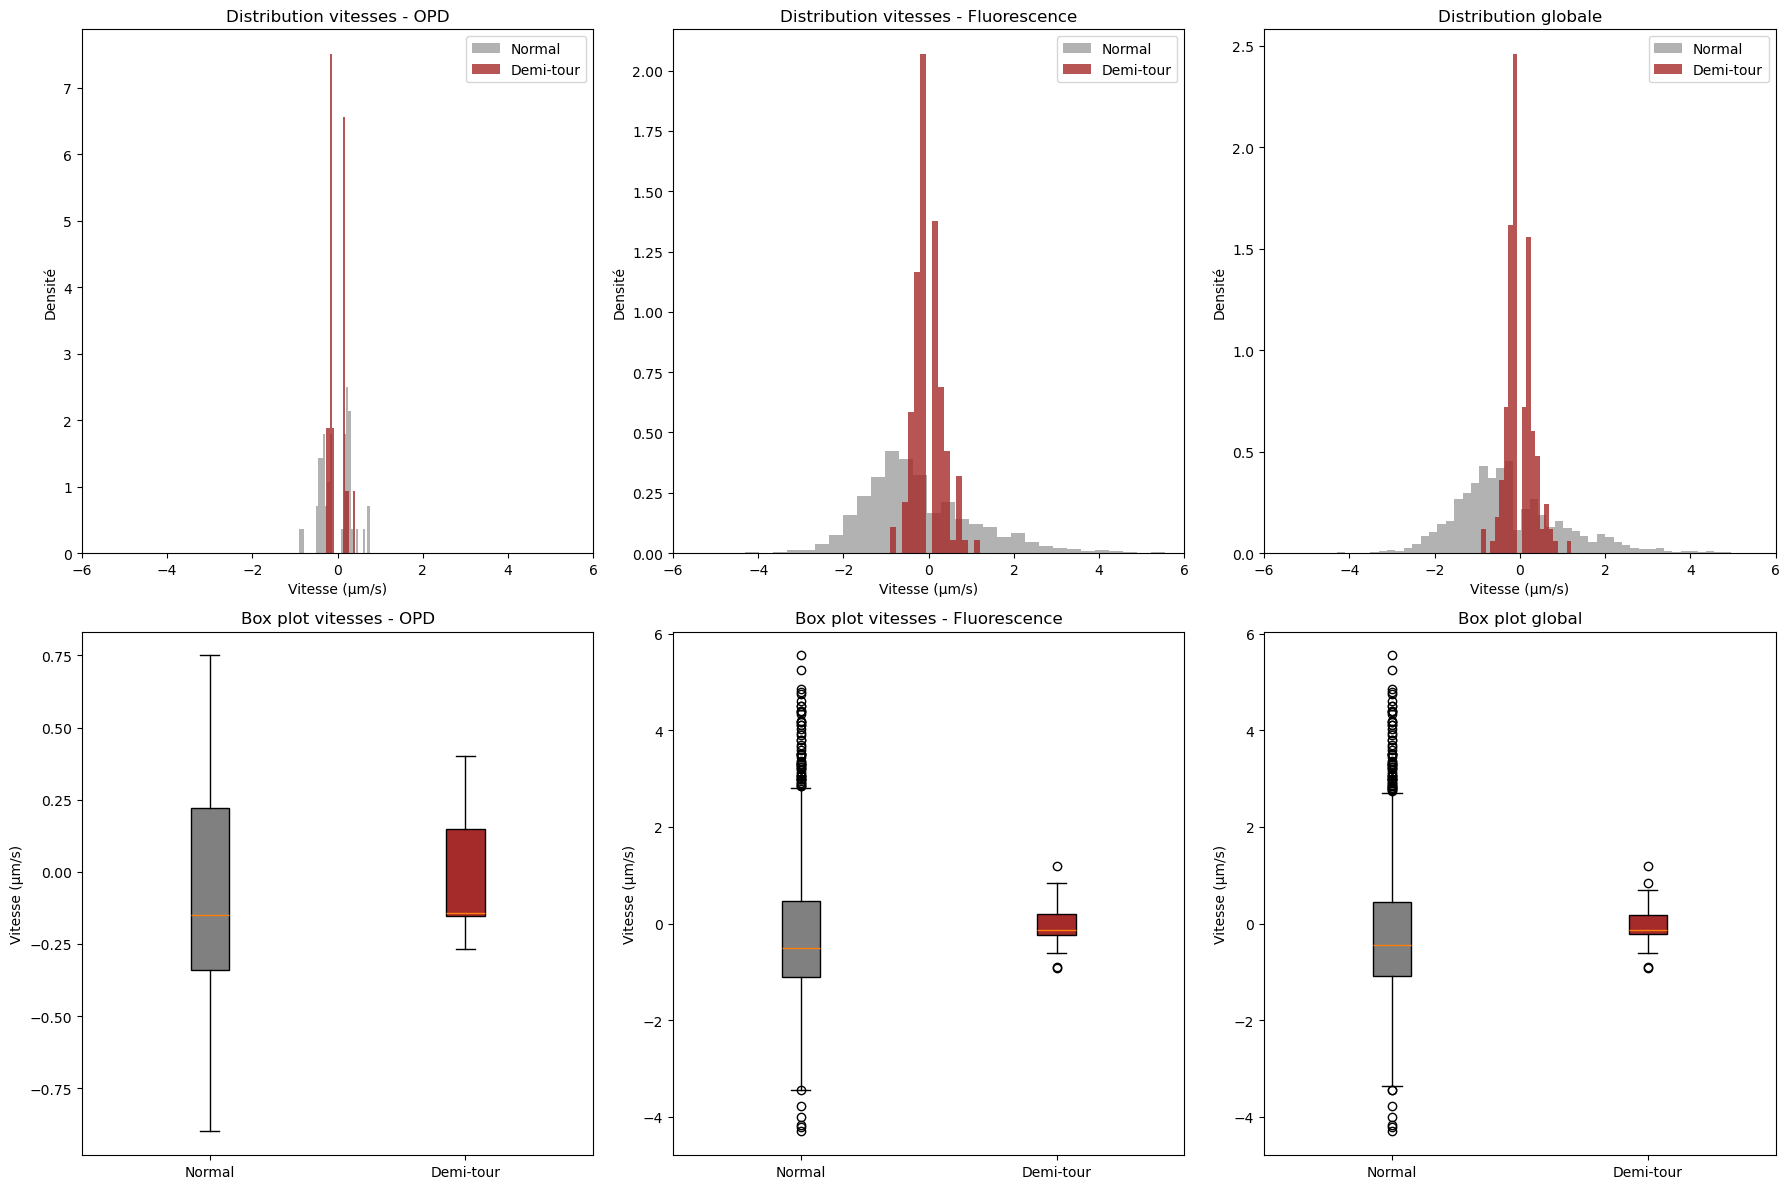


3. Analyse croisée avec la crossdétection
Répartition des groupes:
Normal + Non crossdétecté: 1920 particules
Normal + Crossdétecté: 153 particules
Demi-tour + Non crossdétecté: 141 particules
Demi-tour + Crossdétecté: 17 particules

Statistiques descriptives:
Normal + Non cross - Moyenne: -0.197 µm/s, Médiane: -0.422 µm/s
Normal + Cross - Moyenne: -0.710 µm/s, Médiane: -0.843 µm/s
Demi-tour + Non cross - Moyenne: -0.027 µm/s, Médiane: -0.133 µm/s
Demi-tour + Cross - Moyenne: 0.042 µm/s, Médiane: -0.144 µm/s


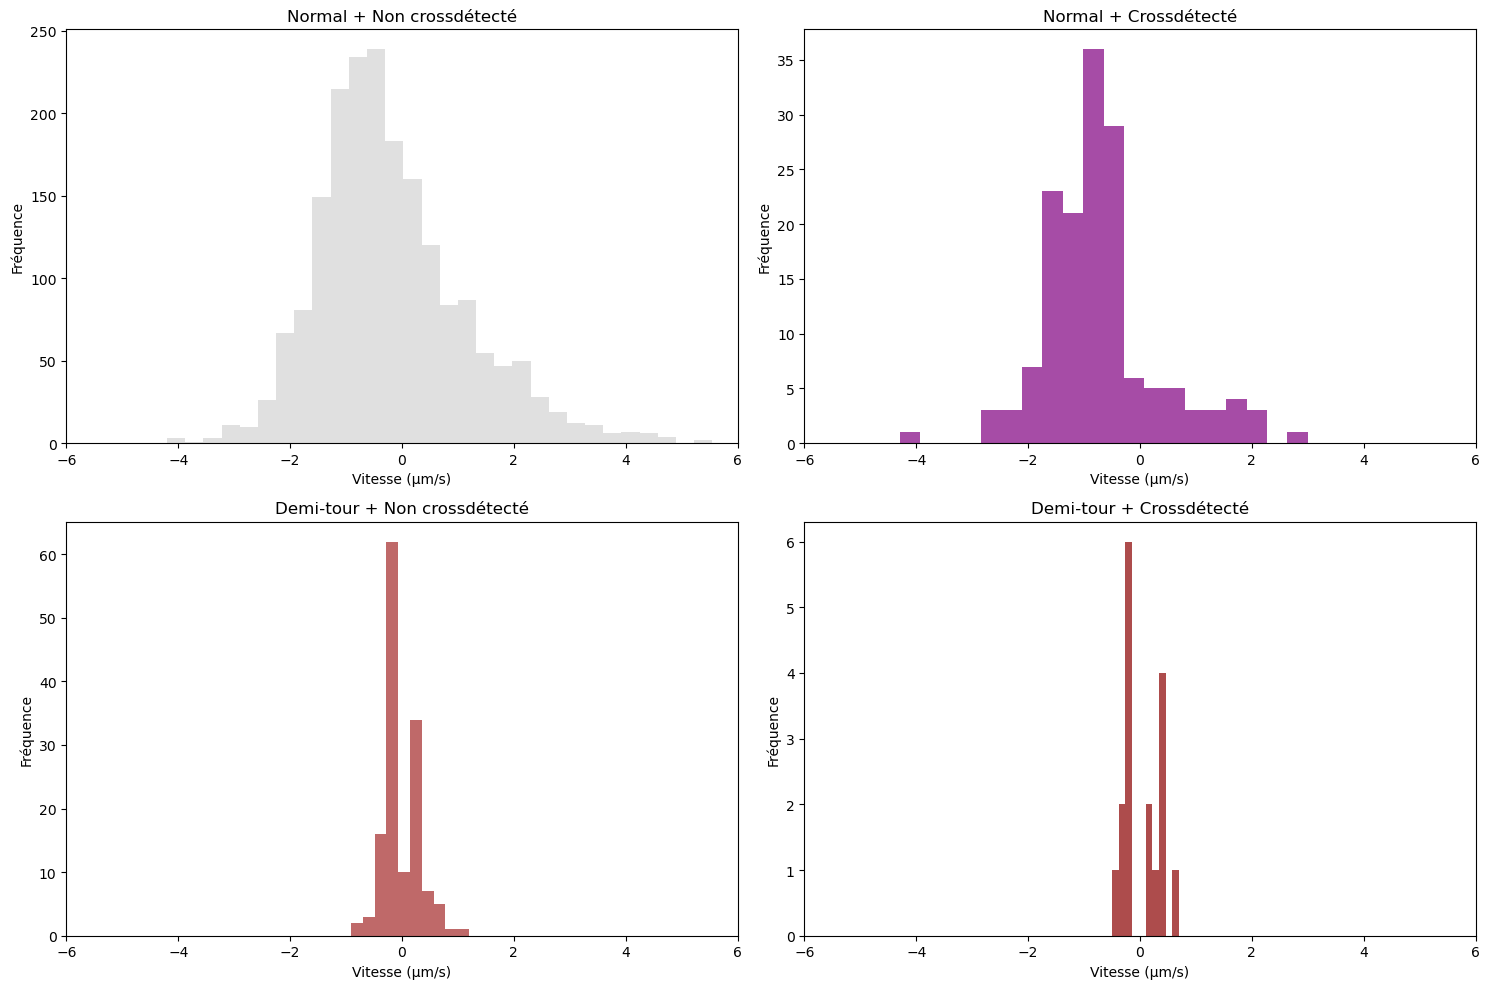


4. Analyse détaillée par modalité et crossdétection :

OPD:
  Normal + Non cross: 48 particules
  Normal + Cross: 3 particules
  Demi-tour + Non cross: 20 particules
  Demi-tour + Cross: 4 particules
  Normal + Non cross - Vitesse moyenne: -0.032 µm/s
  Normal + Cross - Vitesse moyenne: -0.325 µm/s
  Demi-tour + Non cross - Vitesse moyenne: -0.008 µm/s
  Demi-tour + Cross - Vitesse moyenne: -0.092 µm/s

Fluorescence:
  Normal + Non cross: 1872 particules
  Normal + Cross: 150 particules
  Demi-tour + Non cross: 121 particules
  Demi-tour + Cross: 13 particules
  Normal + Non cross - Vitesse moyenne: -0.201 µm/s
  Normal + Cross - Vitesse moyenne: -0.718 µm/s
  Demi-tour + Non cross - Vitesse moyenne: -0.030 µm/s
  Demi-tour + Cross - Vitesse moyenne: 0.083 µm/s

5. Tests statistiques approfondis :

Tests globaux (Normal vs Demi-tour):
Shapiro-Wilk Normal: W=0.9596, p=1.37e-23
Shapiro-Wilk Demi-tour: W=0.9506, p=2.30e-05
Skewness Normal: 0.814
Skewness Demi-tour: 0.537
Taille d'effet (

In [110]:
# Préparation des données
df_normal = df_implemented_exclude[df_implemented_exclude['demi_tour'] == False]
df_demi_tour = df_implemented_exclude[df_implemented_exclude['demi_tour'] == True]

print("Analyse complète des vitesses - Demi-tours vs Normaux")
print(f"Total particules: {len(df_implemented_exclude)}")
print(f"Particules normales: {len(df_normal)} ({len(df_normal)/len(df_implemented_exclude)*100:.1f}%)")
print(f"Particules demi-tours: {len(df_demi_tour)} ({len(df_demi_tour)/len(df_implemented_exclude)*100:.1f}%)")
print()

# 1. ANALYSE GLOBALE DES VITESSES (DEMI-TOURS vs NORMAL)
print("1. Analyse globale des vitesses (Demi-tours vs Normal)")
speeds_normal = df_normal['speed'].dropna()
speeds_demi_tour = df_demi_tour['speed'].dropna()

print("Statistiques descriptives:")
print(f"Normal - Moyenne: {speeds_normal.mean():.3f} µm/s, Médiane: {speeds_normal.median():.3f} µm/s")
print(f"Normal - Écart-type: {speeds_normal.std():.3f} µm/s")
print(f"Demi-tour - Moyenne: {speeds_demi_tour.mean():.3f} µm/s, Médiane: {speeds_demi_tour.median():.3f} µm/s")
print(f"Demi-tour - Écart-type: {speeds_demi_tour.std():.3f} µm/s")

# Tests statistiques globaux
if len(speeds_demi_tour) > 3:  # Vérifier qu'il y a assez de données
    # Test de Mann-Whitney U
    mann_whitney_global = stats.mannwhitneyu(speeds_normal, speeds_demi_tour, alternative='two-sided')
    print(f"\nTest Mann-Whitney U global: U={mann_whitney_global.statistic:.0f}, p-value={mann_whitney_global.pvalue:.2e}")
    
    # Test d'hétérogénéité des variances
    levene_global = levene(speeds_normal, speeds_demi_tour)
    print(f"Test de Levene global: statistique={levene_global.statistic:.4f}, p-value={levene_global.pvalue:.2e}")
else:
    print("Pas assez de données pour les tests statistiques sur les demi-tours")

print("\n" + "="*80)

# 2. ANALYSE PAR MODALITÉ
print("2. Analyse par modalité :")
modalites = {1: "OPD", 2: "Fluorescence"}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, (modalite_id, modalite_nom) in enumerate(modalites.items()):
    df_modalite = df_implemented_exclude[df_implemented_exclude['ID_modality'] == modalite_id]
    
    if len(df_modalite) == 0:
        continue
        
    df_normal_mod = df_modalite[df_modalite['demi_tour'] == False]
    df_demi_tour_mod = df_modalite[df_modalite['demi_tour'] == True]
    
    speeds_normal_mod = df_normal_mod['speed'].dropna()
    speeds_demi_tour_mod = df_demi_tour_mod['speed'].dropna()
    
    print(f"\n{modalite_nom} ({len(df_modalite)} particules):")
    print(f"  Normal: {len(df_normal_mod)} particules")
    print(f"  Demi-tour: {len(df_demi_tour_mod)} particules")
    
    if len(speeds_normal_mod) > 0:
        print(f"  Normal - Moyenne: {speeds_normal_mod.mean():.3f} µm/s, Médiane: {speeds_normal_mod.median():.3f} µm/s")
    if len(speeds_demi_tour_mod) > 0:
        print(f"  Demi-tour - Moyenne: {speeds_demi_tour_mod.mean():.3f} µm/s, Médiane: {speeds_demi_tour_mod.median():.3f} µm/s")
    
    # Tests statistiques par modalité
    if len(speeds_demi_tour_mod) > 3 and len(speeds_normal_mod) > 3:
        mann_whitney_mod = stats.mannwhitneyu(speeds_normal_mod, speeds_demi_tour_mod, alternative='two-sided')
        print(f"  Test Mann-Whitney: p-value={mann_whitney_mod.pvalue:.2e}")
    
    # Graphiques par modalité
    # Histogrammes
    axes[0, i].hist(speeds_normal_mod, bins=30, alpha=0.6, label='Normal', color='grey', density=True)
    if len(speeds_demi_tour_mod) > 0:
        axes[0, i].hist(speeds_demi_tour_mod, bins=15, alpha=0.8, label='Demi-tour', color='brown', density=True)
    axes[0, i].set_title(f'Distribution vitesses - {modalite_nom}')
    axes[0, i].set_xlabel('Vitesse (µm/s)')
    axes[0, i].set_ylabel('Densité')
    axes[0, i].legend()
    axes[0, i].set_xlim(-6, 6)

    # Box plots
    data_box = [speeds_normal_mod]
    labels_box = ['Normal']
    if len(speeds_demi_tour_mod) > 0:
        data_box.append(speeds_demi_tour_mod)
        labels_box.append('Demi-tour')
    
    box_plot = axes[1, i].boxplot(data_box, labels=labels_box, patch_artist=True)
    box_plot['boxes'][0].set_facecolor('grey')
    if len(box_plot['boxes']) > 1:
        box_plot['boxes'][1].set_facecolor('brown')
    axes[1, i].set_title(f'Box plot vitesses - {modalite_nom}')
    axes[1, i].set_ylabel('Vitesse (µm/s)')

# Graphique comparatif global
data_global = [speeds_normal, speeds_demi_tour] if len(speeds_demi_tour) > 0 else [speeds_normal]
labels_global = ['Normal', 'Demi-tour'] if len(speeds_demi_tour) > 0 else ['Normal']

axes[0, 2].hist(speeds_normal, bins=50, alpha=0.6, label='Normal', color='grey', density=True)
if len(speeds_demi_tour) > 0:
    axes[0, 2].hist(speeds_demi_tour, bins=20, alpha=0.8, label='Demi-tour', color='brown', density=True)
axes[0, 2].set_title('Distribution globale')
axes[0, 2].set_xlabel('Vitesse (µm/s)')
axes[0, 2].set_ylabel('Densité')
axes[0, 2].legend()
axes[0, 2].set_xlim(-6, 6)

box_plot_global = axes[1, 2].boxplot(data_global, labels=labels_global, patch_artist=True)
box_plot_global['boxes'][0].set_facecolor('grey')
if len(box_plot_global['boxes']) > 1:
    box_plot_global['boxes'][1].set_facecolor('brown')
axes[1, 2].set_title('Box plot global')
axes[1, 2].set_ylabel('Vitesse (µm/s)')

plt.tight_layout()
plt.show()

print("\n" + "="*80)

# 3. ANALYSE CROISÉE AVEC LA CROSSDÉTECTION
print("3. Analyse croisée avec la crossdétection")

# Création des groupes croisés
df_normal_cross = df_normal[df_normal['crossdetection_bool_clean'] == True]
df_normal_non_cross = df_normal[df_normal['crossdetection_bool_clean'] == False]
df_demi_tour_cross = df_demi_tour[df_demi_tour['crossdetection_bool_clean'] == True]
df_demi_tour_non_cross = df_demi_tour[df_demi_tour['crossdetection_bool_clean'] == False]

speeds_normal_cross = df_normal_cross['speed'].dropna()
speeds_normal_non_cross = df_normal_non_cross['speed'].dropna()
speeds_demi_tour_cross = df_demi_tour_cross['speed'].dropna()
speeds_demi_tour_non_cross = df_demi_tour_non_cross['speed'].dropna()

print("Répartition des groupes:")
print(f"Normal + Non crossdétecté: {len(speeds_normal_non_cross)} particules")
print(f"Normal + Crossdétecté: {len(speeds_normal_cross)} particules")
print(f"Demi-tour + Non crossdétecté: {len(speeds_demi_tour_non_cross)} particules")
print(f"Demi-tour + Crossdétecté: {len(speeds_demi_tour_cross)} particules")

# Statistiques descriptives croisées
print("\nStatistiques descriptives:")
if len(speeds_normal_non_cross) > 0:
    print(f"Normal + Non cross - Moyenne: {speeds_normal_non_cross.mean():.3f} µm/s, Médiane: {speeds_normal_non_cross.median():.3f} µm/s")
if len(speeds_normal_cross) > 0:
    print(f"Normal + Cross - Moyenne: {speeds_normal_cross.mean():.3f} µm/s, Médiane: {speeds_normal_cross.median():.3f} µm/s")
if len(speeds_demi_tour_non_cross) > 0:
    print(f"Demi-tour + Non cross - Moyenne: {speeds_demi_tour_non_cross.mean():.3f} µm/s, Médiane: {speeds_demi_tour_non_cross.median():.3f} µm/s")
if len(speeds_demi_tour_cross) > 0:
    print(f"Demi-tour + Cross - Moyenne: {speeds_demi_tour_cross.mean():.3f} µm/s, Médiane: {speeds_demi_tour_cross.median():.3f} µm/s")

# Graphique croisé
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogrammes croisés
axes[0, 0].hist(speeds_normal_non_cross, bins=30, alpha=0.7, label='Normal + Non cross', color='lightgrey')
axes[0, 0].set_title('Normal + Non crossdétecté')
axes[0, 0].set_xlabel('Vitesse (µm/s)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_xlim(-6, 6)

axes[0, 1].hist(speeds_normal_cross, bins=20, alpha=0.7, label='Normal + Cross', color='purple')
axes[0, 1].set_title('Normal + Crossdétecté')
axes[0, 1].set_xlabel('Vitesse (µm/s)')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].set_xlim(-6, 6)

if len(speeds_demi_tour_non_cross) > 0:
    axes[1, 0].hist(speeds_demi_tour_non_cross, bins=10, alpha=0.7, label='Demi-tour + Non cross', color='brown')
    axes[1, 0].set_title('Demi-tour + Non crossdétecté')
else:
    axes[1, 0].text(0.5, 0.5, 'Pas de données', ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('Demi-tour + Non crossdétecté')
axes[1, 0].set_xlabel('Vitesse (µm/s)')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_xlim(-6, 6)

if len(speeds_demi_tour_cross) > 0:
    axes[1, 1].hist(speeds_demi_tour_cross, bins=10, alpha=0.7, label='Demi-tour + Cross', color='darkred')
    axes[1, 1].set_title('Demi-tour + Crossdétecté')
else:
    axes[1, 1].text(0.5, 0.5, 'Pas de données', ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Demi-tour + Crossdétecté')
axes[1, 1].set_xlabel('Vitesse (µm/s)')
axes[1, 1].set_ylabel('Fréquence')
axes[1, 1].set_xlim(-6, 6)

plt.tight_layout()
plt.show()

# 4. ANALYSE PAR MODALITÉ ET CROSSDÉTECTION
print("\n" + "="*80)
print("4. Analyse détaillée par modalité et crossdétection :")

for modalite_id, modalite_nom in modalites.items():
    print(f"\n{modalite_nom}:")
    df_mod = df_implemented_exclude[df_implemented_exclude['ID_modality'] == modalite_id]
    
    # Sous-groupes par modalité
    df_mod_normal_cross = df_mod[(df_mod['demi_tour'] == False) & (df_mod['crossdetection_bool_clean'] == True)]
    df_mod_normal_non_cross = df_mod[(df_mod['demi_tour'] == False) & (df_mod['crossdetection_bool_clean'] == False)]
    df_mod_demi_tour_cross = df_mod[(df_mod['demi_tour'] == True) & (df_mod['crossdetection_bool_clean'] == True)]
    df_mod_demi_tour_non_cross = df_mod[(df_mod['demi_tour'] == True) & (df_mod['crossdetection_bool_clean'] == False)]
    
    print(f"  Normal + Non cross: {len(df_mod_normal_non_cross)} particules")
    print(f"  Normal + Cross: {len(df_mod_normal_cross)} particules")
    print(f"  Demi-tour + Non cross: {len(df_mod_demi_tour_non_cross)} particules")
    print(f"  Demi-tour + Cross: {len(df_mod_demi_tour_cross)} particules")
    
    # Vitesses moyennes par sous-groupe
    if len(df_mod_normal_non_cross) > 0:
        print(f"  Normal + Non cross - Vitesse moyenne: {df_mod_normal_non_cross['speed'].mean():.3f} µm/s")
    if len(df_mod_normal_cross) > 0:
        print(f"  Normal + Cross - Vitesse moyenne: {df_mod_normal_cross['speed'].mean():.3f} µm/s")
    if len(df_mod_demi_tour_non_cross) > 0:
        print(f"  Demi-tour + Non cross - Vitesse moyenne: {df_mod_demi_tour_non_cross['speed'].mean():.3f} µm/s")
    if len(df_mod_demi_tour_cross) > 0:
        print(f"  Demi-tour + Cross - Vitesse moyenne: {df_mod_demi_tour_cross['speed'].mean():.3f} µm/s")

# 5. TESTS STATISTIQUES APPROFONDIS
print("\n" + "="*80)
print("5. Tests statistiques approfondis :")

# Test global si assez de données
if len(speeds_demi_tour) > 3 and len(speeds_normal) > 3:
    print("\nTests globaux (Normal vs Demi-tour):")
    
    # Tests de normalité
    shapiro_normal = stats.shapiro(speeds_normal)
    shapiro_demi_tour = stats.shapiro(speeds_demi_tour)
    print(f"Shapiro-Wilk Normal: W={shapiro_normal.statistic:.4f}, p={shapiro_normal.pvalue:.2e}")
    print(f"Shapiro-Wilk Demi-tour: W={shapiro_demi_tour.statistic:.4f}, p={shapiro_demi_tour.pvalue:.2e}")
    
    # Test d'asymétrie
    skew_normal = stats.skew(speeds_normal)
    skew_demi_tour = stats.skew(speeds_demi_tour)
    print(f"Skewness Normal: {skew_normal:.3f}")
    print(f"Skewness Demi-tour: {skew_demi_tour:.3f}")
    
    # Calcul de la taille d'effet
    n1, n2 = len(speeds_normal), len(speeds_demi_tour)
    if mann_whitney_global.pvalue > 0:
        z_score = stats.norm.ppf(mann_whitney_global.pvalue/2)
        effect_size = abs(z_score) / np.sqrt(n1 + n2)
        print(f"Taille d'effet (r): {effect_size:.3f}")
        
        # Interprétation
        if mann_whitney_global.pvalue < 0.05:
            print("Différence significative entre normal et demi-tour")
            if speeds_normal.median() > speeds_demi_tour.median():
                print("Les particules normales sont plus rapides")
            else:
                print("Les particules faisant demi-tour sont plus rapides")
        else:
            print("Pas de différence significative entre normal et demi-tour")

## Signal

### Seuil intensité signal pour crossdétection :

In [111]:
seuil_OPD = seuil_signal_dispersion(df_implemented_exclude, quantile_signal=0.5, quantile_dispersion=0.5, modalite=1)

Calcul du seuil pour OPD (Front d'onde) (75 particules sur 2231 total)
Seuil signal_I (quantile 0.5): 9.77
Seuil dispersion (quantile 0.5): 3.34
Seuil ratio signal/dispersion: 2.92


Analyse sur 75 particules OPD (sur 2231 total)

Résultats (OPD uniquement):
OPD faible (≤2.92): 0/0 crossdétectées (0.0%)
OPD fort (>2.92): 7/75 crossdétectées (9.3%)


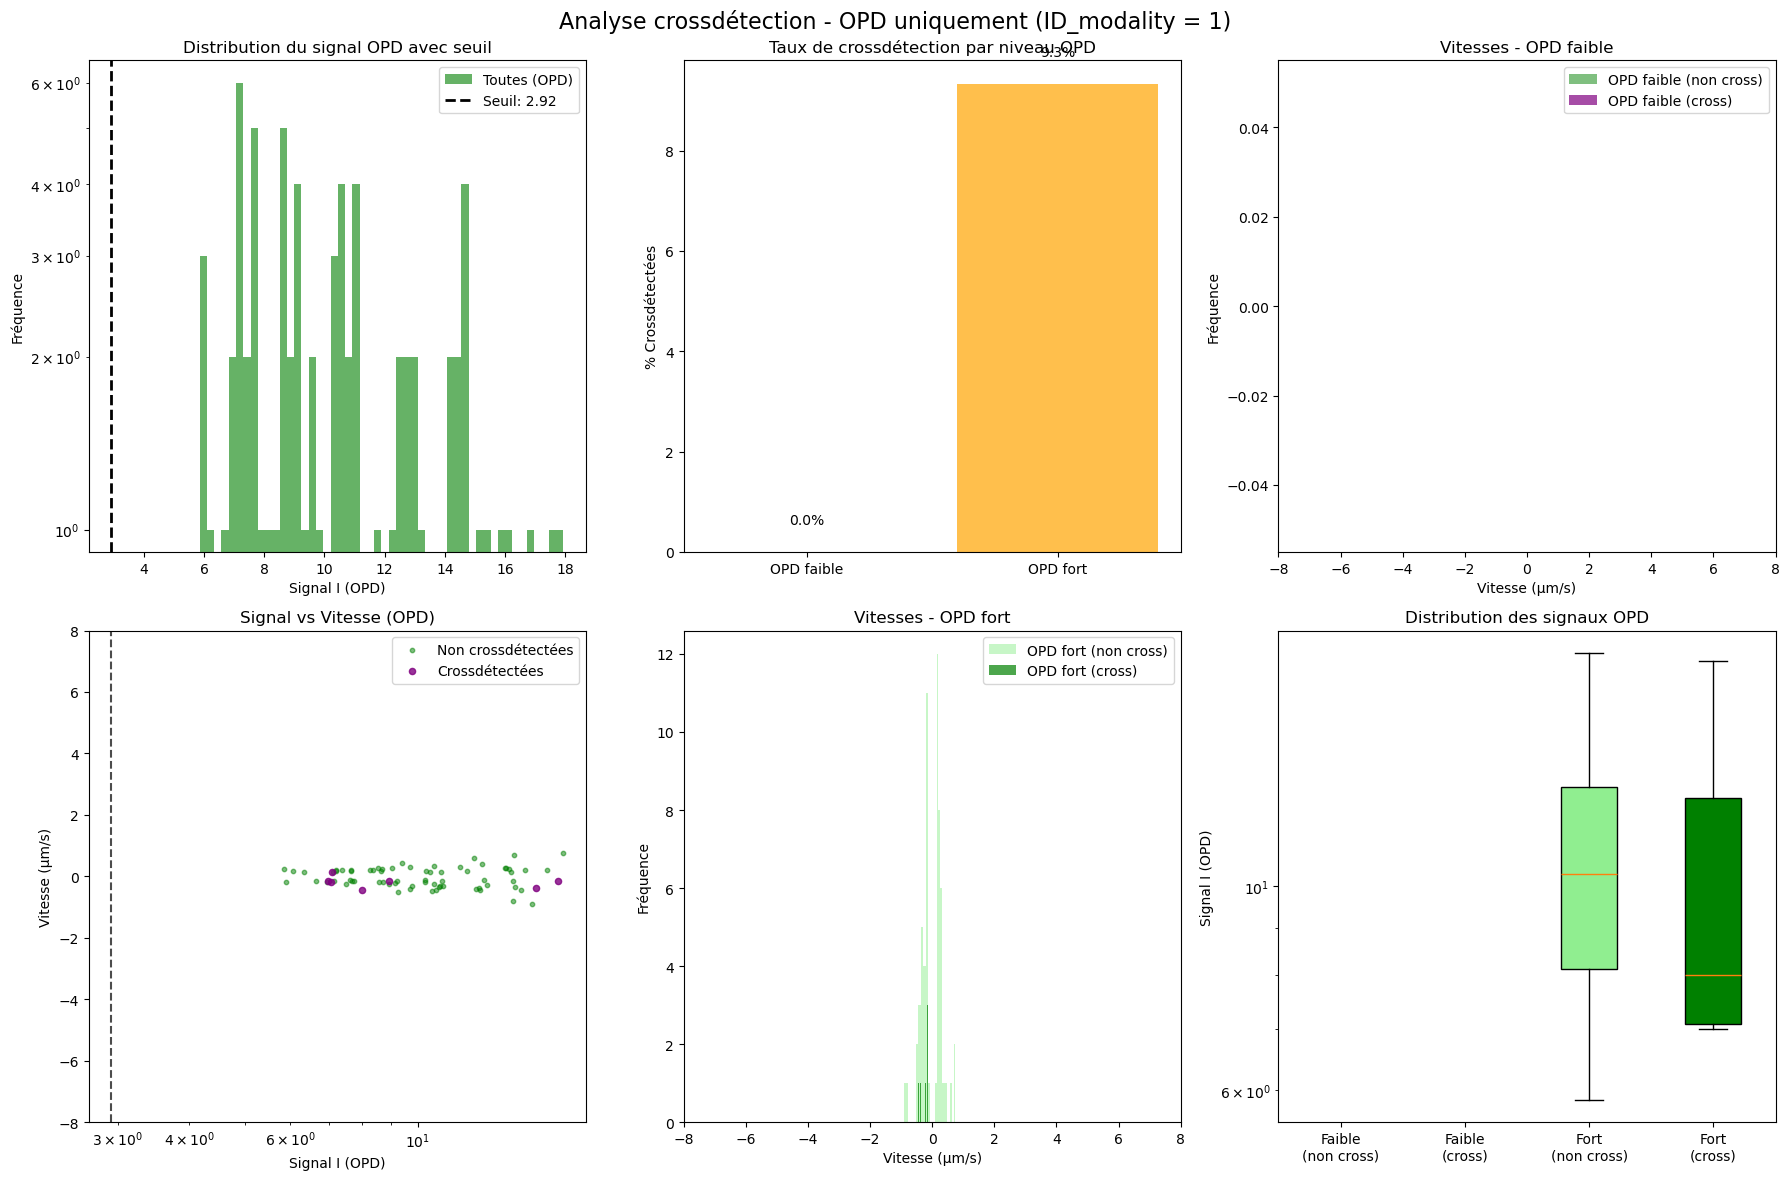


Statistiques détaillées (OPD uniquement):
Catégorie            Total      Crossdét.    %        Signal moy.  Vitesse moy.
--------------------------------------------------------------------------------
OPD faible           0          0            0.0      nan          nan         
OPD fort             75         7            9.3      10.47        -0.04       

Test Mann-Whitney vitesse OPD faible vs OPD fort : U=nan, p=nan
Pas de différence significative (p ≥ 0.05)


In [112]:
resultats_crossdetected_OPD = analyser_crossdetection_par_signal_OPD(df_implemented_exclude, seuil_signal=seuil_OPD)

In [113]:
seuil_Fluo = seuil_signal_dispersion(df_implemented_exclude, quantile_signal=0.5, quantile_dispersion=0.5, modalite=2)

Calcul du seuil pour Fluorescence (2156 particules sur 2231 total)
Seuil signal_I (quantile 0.5): 94.58
Seuil dispersion (quantile 0.5): 12.10
Seuil ratio signal/dispersion: 7.82


Analyse sur 2156 particules Fluo (sur 2231 total)

Résultats (Fluo uniquement):
Fluo faible (≤7.82): 0/0 crossdétectées (0.0%)
Fluo fort (>7.82): 163/2156 crossdétectées (7.6%)


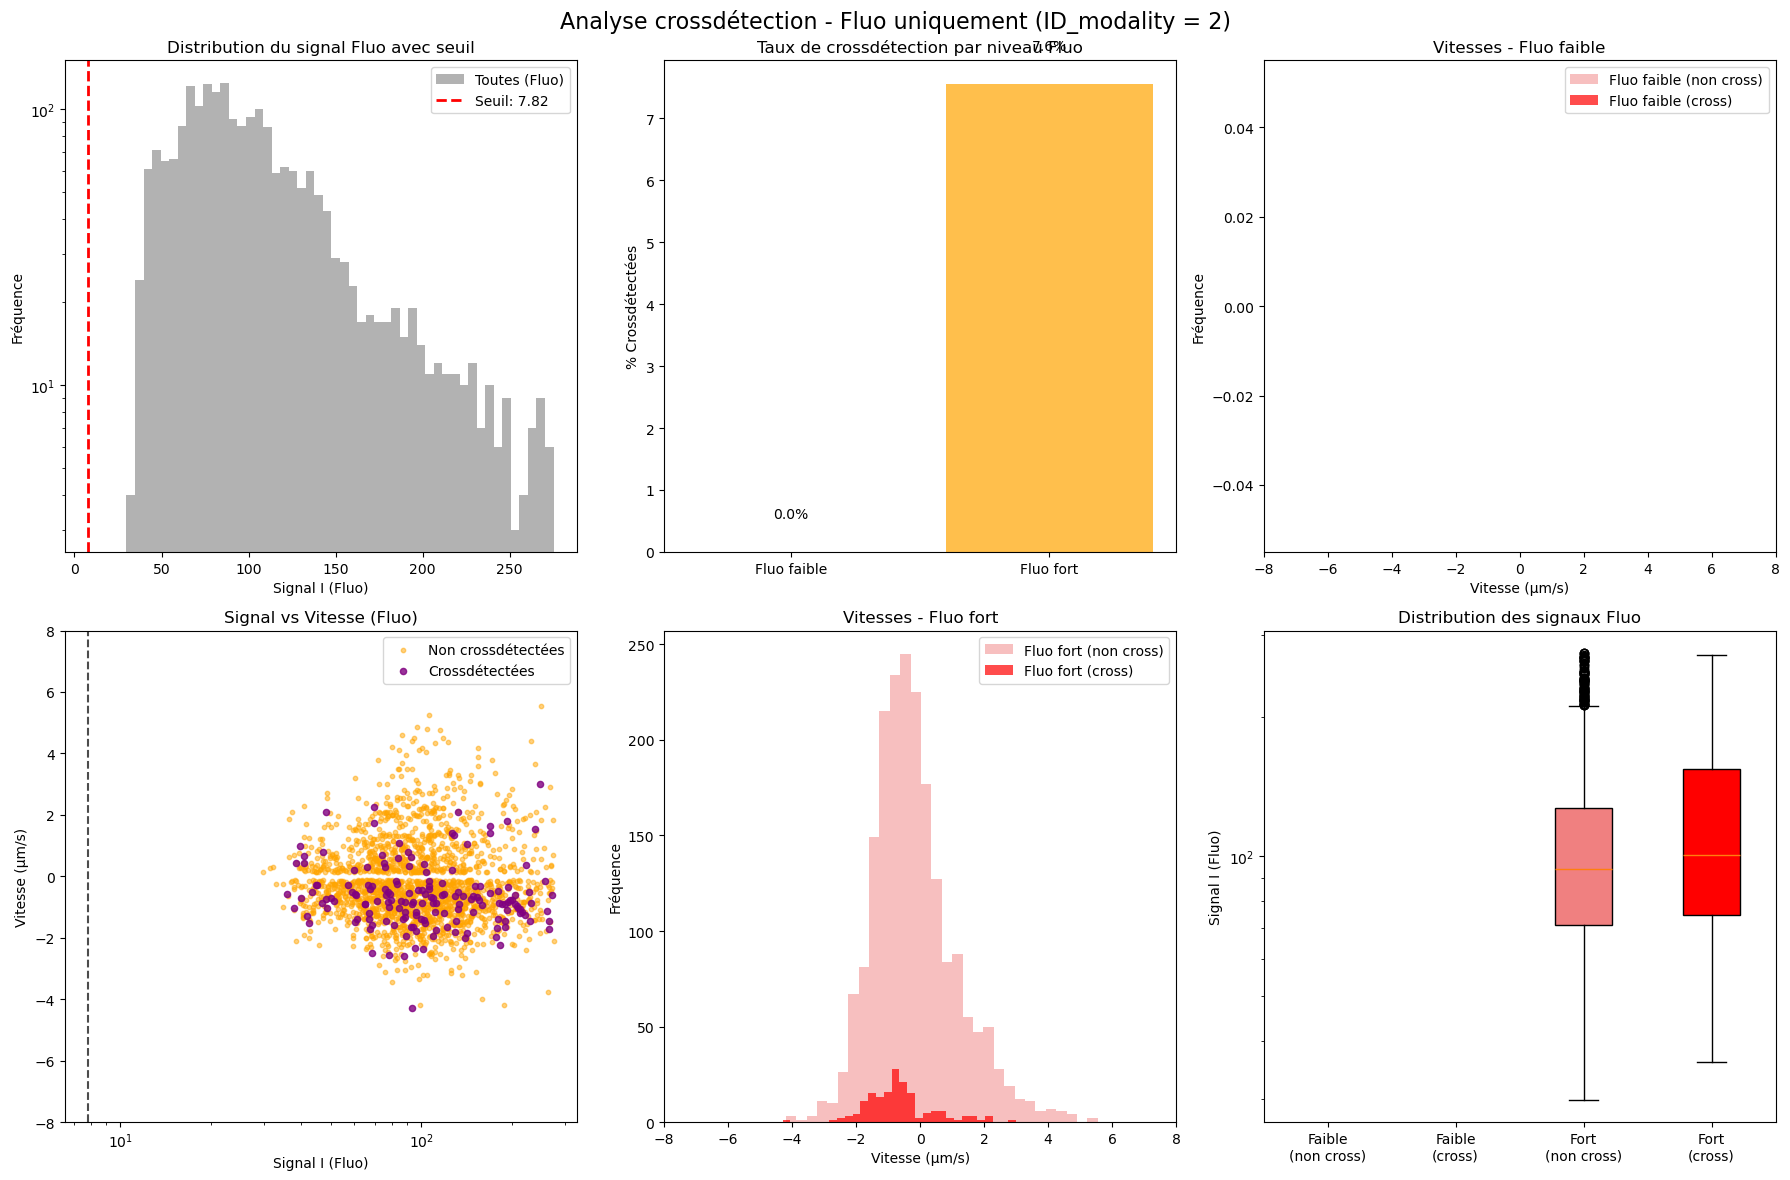


Statistiques détaillées (Fluo uniquement):
Catégorie            Total      Crossdét.    %        Signal moy.  Vitesse moy.
--------------------------------------------------------------------------------
Fluo faible          0          0            0.0      nan          nan         
Fluo fort            2156       163          7.6      105.64       -0.23       

Test Mann-Whitney vitesse Fluo faible vs Fluo fort : U=nan, p=nan
Pas de différence significative (p ≥ 0.05)


In [114]:
resultats_crossdetected_Fluo = analyser_crossdetection_par_signal_Fluo(df_implemented_exclude, seuil_signal=seuil_Fluo)

### S'intéresser à la fluorescence et au front d'onde et au signal :

In [115]:
"""colonnes_requises = ['ID_modality', 'signal_I', 'signal_sigma']
colonnes_presentes = [col for col in colonnes_requises if col in df_implemented_exclude.columns]
colonnes_manquantes = [col for col in colonnes_requises if col not in df_implemented_exclude.columns]
"""

# Statistiques des modalités
if 'ID_modality' in df_implemented_exclude.columns:
    print(f"\nRépartition des modalités :")
    modalite_counts = df_implemented_exclude['ID_modality'].value_counts().sort_index()
    print(modalite_counts)

    modalite_pct = df_implemented_exclude['ID_modality'].value_counts(normalize=True).sort_index() * 100
    print(f"\nPourcentages:")
    for modalite, pct in modalite_pct.items():
        nom_modalite = "Front d'onde" if modalite == 1 else "Fluorescence" if modalite == 2 else f"Modalité {modalite}"
        print(f"  {modalite} ({nom_modalite}): {pct:.1f}%")

# Vérification de la qualité du signal selon les critères
if all(col in df_implemented_exclude.columns for col in ['signal_I', 'signal_sigma']):
    print(f"\nAnalyse de la qualité du signal selon les critères :")
    
    # Critères de fiabilité
    signal_positif = df_implemented_exclude['signal_I'] > 0
    sigma_petit = df_implemented_exclude['signal_sigma'] <= df_implemented_exclude['signal_I']  # sigma de l'ordre de grandeur du signal
    duree_suffisante = df_implemented_exclude['duree_suivi'] > 1.0  # Plus d'1 seconde

    # Signal fiable selon tous les critères
    signal_fiable = signal_positif & sigma_petit & duree_suffisante

    print(f"Signal positif: {signal_positif.sum()} / {len(df_implemented_exclude)} ({signal_positif.mean()*100:.3f}%)")
    print(f"Sigma petit (≤ signal): {sigma_petit.sum()} / {len(df_implemented_exclude)} ({sigma_petit.mean()*100:.3f}%)")
    print(f"Durée suffisante (>1s): {duree_suffisante.sum()} / {len(df_implemented_exclude)} ({duree_suffisante.mean()*100:.3f}%)")
    print(f"Signal fiable (tous critères): {signal_fiable.sum()} / {len(df_implemented_exclude)} ({signal_fiable.mean()*100:.3f}%)")


Répartition des modalités :
ID_modality
1      75
2    2156
Name: count, dtype: int64

Pourcentages:
  1 (Front d'onde): 3.4%
  2 (Fluorescence): 96.6%

Analyse de la qualité du signal selon les critères :
Signal positif: 2231 / 2231 (100.000%)
Sigma petit (≤ signal): 2146 / 2231 (96.190%)
Durée suffisante (>1s): 2231 / 2231 (100.000%)
Signal fiable (tous critères): 2146 / 2231 (96.190%)


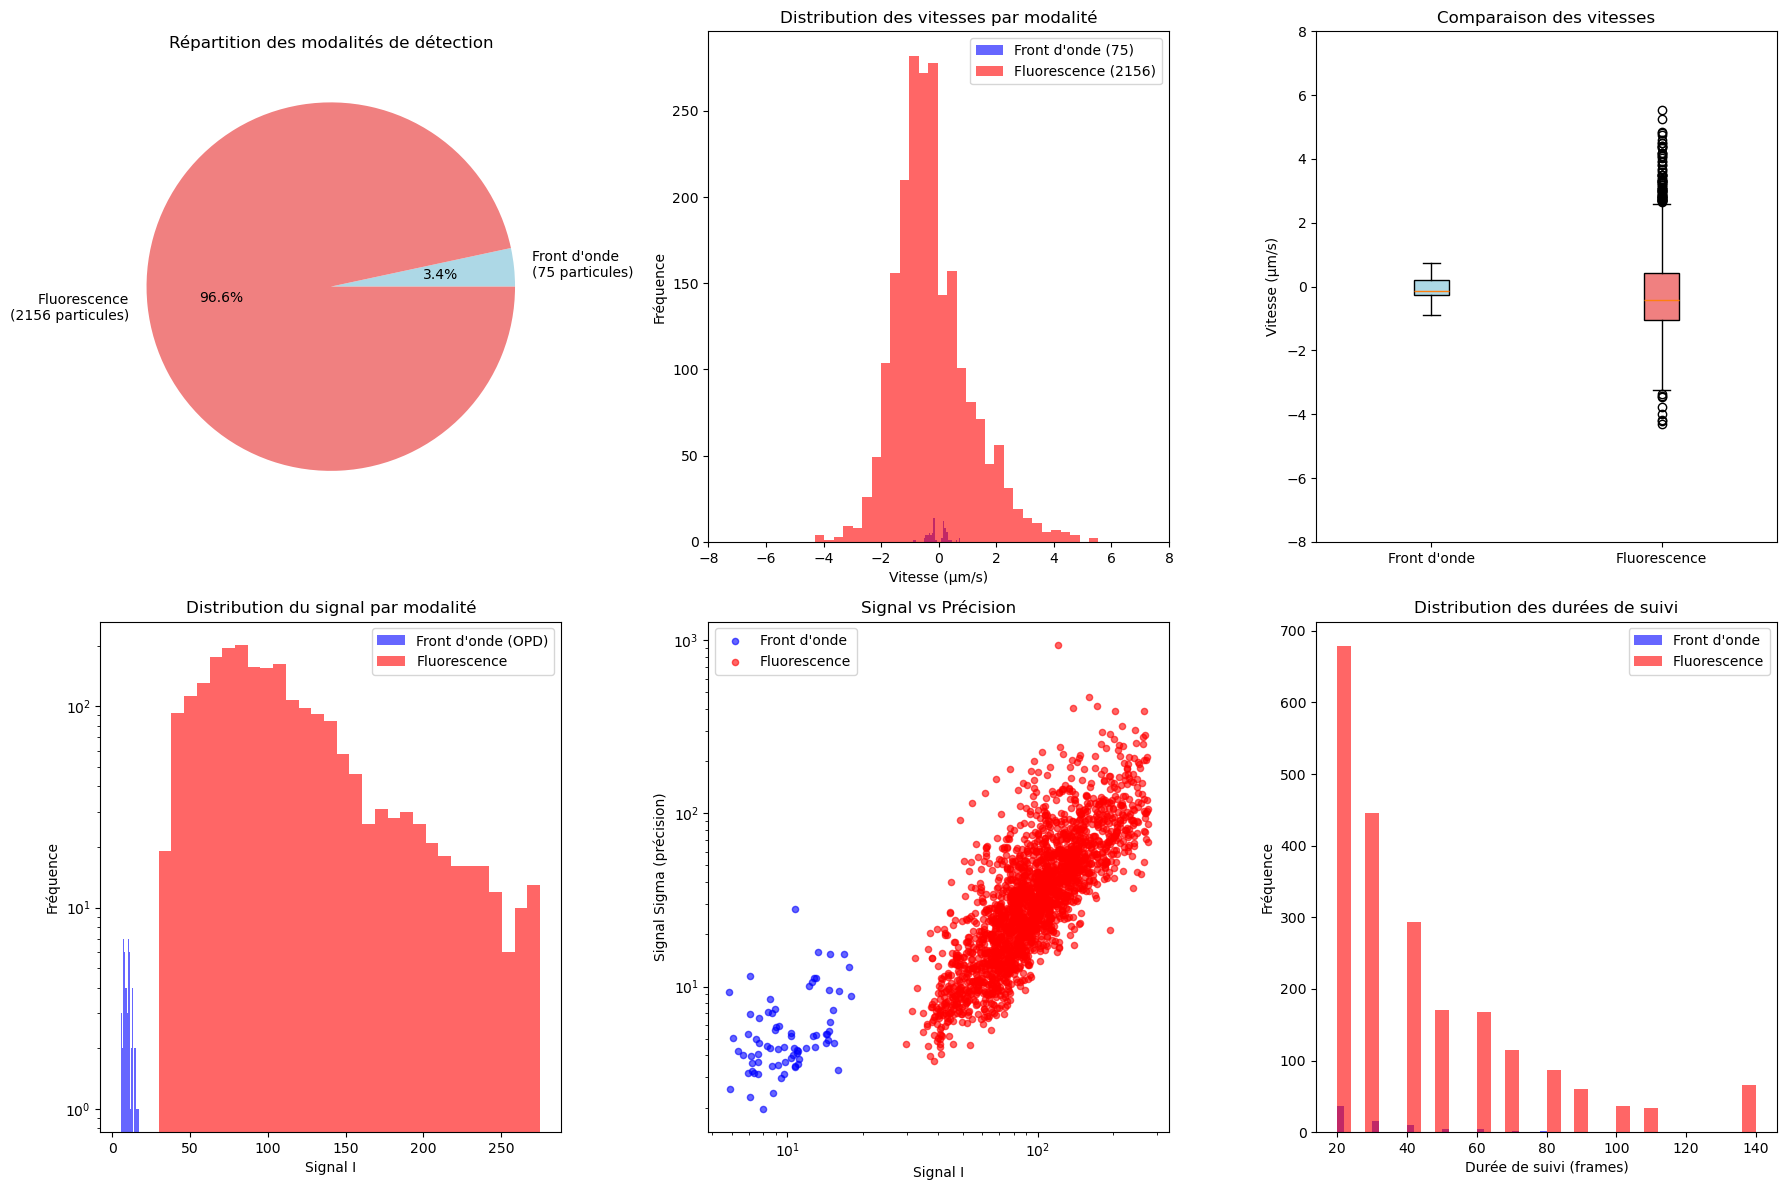

In [116]:
if 'ID_modality' in df_implemented_exclude.columns:
    # Séparer les données par modalité
    df_front_onde = df_implemented_exclude[df_implemented_exclude['ID_modality'] == 1]
    df_fluorescence = df_implemented_exclude[df_implemented_exclude['ID_modality'] == 2]

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Répartition des modalités
    modalite_counts = df_implemented_exclude['ID_modality'].value_counts().sort_index()
    axes[0,0].pie(modalite_counts.values, 
                  labels=[f"Front d'onde\n({modalite_counts[1]} particules)", 
                          f"Fluorescence\n({modalite_counts[2]} particules)"], 
                  autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
    axes[0,0].set_title('Répartition des modalités de détection')
    
    # Distribution des vitesses par modalité
    axes[0,1].hist(df_front_onde['speed'].dropna(), bins=30, alpha=0.6, 
                   label=f"Front d'onde ({len(df_front_onde)})", color='blue')
    axes[0,1].hist(df_fluorescence['speed'].dropna(), bins=30, alpha=0.6, 
                   label=f"Fluorescence ({len(df_fluorescence)})", color='red')
    axes[0,1].set_xlabel('Vitesse (µm/s)')
    axes[0,1].set_ylabel('Fréquence')
    axes[0,1].set_xlim(-8, 8)
    axes[0,1].set_title('Distribution des vitesses par modalité')
    axes[0,1].legend()
    
    # Boxplot des vitesses
    vitesses_par_modalite = [df_front_onde['speed'].dropna(), 
                            df_fluorescence['speed'].dropna()]
    box_plot = axes[0,2].boxplot(vitesses_par_modalite, 
                                labels=["Front d'onde", "Fluorescence"], 
                                patch_artist=True)
    box_plot['boxes'][0].set_facecolor('lightblue')
    box_plot['boxes'][1].set_facecolor('lightcoral')
    axes[0,2].set_ylim(-8, 8)
    axes[0,2].set_ylabel('Vitesse (µm/s)')
    axes[0,2].set_title('Comparaison des vitesses')
    
    # Distribution du signal_I par modalité
    if 'signal_I' in df_implemented_exclude.columns:
        axes[1,0].hist(df_front_onde['signal_I'].dropna(), bins=30, alpha=0.6, 
                       label="Front d'onde (OPD)", color='blue')
        axes[1,0].hist(df_fluorescence['signal_I'].dropna(), bins=30, alpha=0.6, 
                       label="Fluorescence", color='red')
        axes[1,0].set_xlabel('Signal I')
        axes[1,0].set_ylabel('Fréquence')
        axes[1,0].set_title('Distribution du signal par modalité')
        axes[1,0].legend()
        axes[1,0].set_yscale('log')  # Échelle log pour mieux voir les distributions
    
    # Relation signal vs sigma
    if all(col in df_implemented_exclude.columns for col in ['signal_I', 'signal_sigma']):
        axes[1,1].scatter(df_front_onde['signal_I'], df_front_onde['signal_sigma'], 
                         alpha=0.6, label="Front d'onde", color='blue', s=20)
        axes[1,1].scatter(df_fluorescence['signal_I'], df_fluorescence['signal_sigma'], 
                         alpha=0.6, label="Fluorescence", color='red', s=20)
        axes[1,1].set_xlabel('Signal I')
        axes[1,1].set_ylabel('Signal Sigma (précision)')
        axes[1,1].set_title('Signal vs Précision')
        axes[1,1].legend()
        axes[1,1].set_yscale('log')
        axes[1,1].set_xscale('log')
    
    # Durée de suivi par modalité
    axes[1,2].hist(df_front_onde['duree_suivi'].dropna(), bins=30, alpha=0.6, 
                   label="Front d'onde", color='blue')
    axes[1,2].hist(df_fluorescence['duree_suivi'].dropna(), bins=30, alpha=0.6, 
                   label="Fluorescence", color='red')
    axes[1,2].set_xlabel('Durée de suivi (frames)')
    axes[1,2].set_ylabel('Fréquence')
    axes[1,2].set_title('Distribution des durées de suivi')
    axes[1,2].legend()
    
    plt.tight_layout()
    plt.show()


FRONT D'ONDE (75 particules):
Signal positif: 75 (100.0%)
Sigma ≤ Signal: 70 (93.3%)
Durée > 1s: 75 (100.0%)
Fiable (tous critères): 70 (93.3%)
Fiable (signal + durée): 75 (100.0%)
Vitesse moyenne (fiable): -0.05 µm/s
Signal moyen (fiable): 10.49

FLUORESCENCE (2156 particules):
Signal positif: 2156 (100.0%)
Sigma ≤ Signal: 2076 (96.3%)
Durée > 1s: 2156 (100.0%)
Fiable (tous critères): 2076 (96.3%)
Fiable (signal + durée): 2156 (100.0%)
Vitesse moyenne (fiable): -0.24 µm/s
Signal moyen (fiable): 104.72


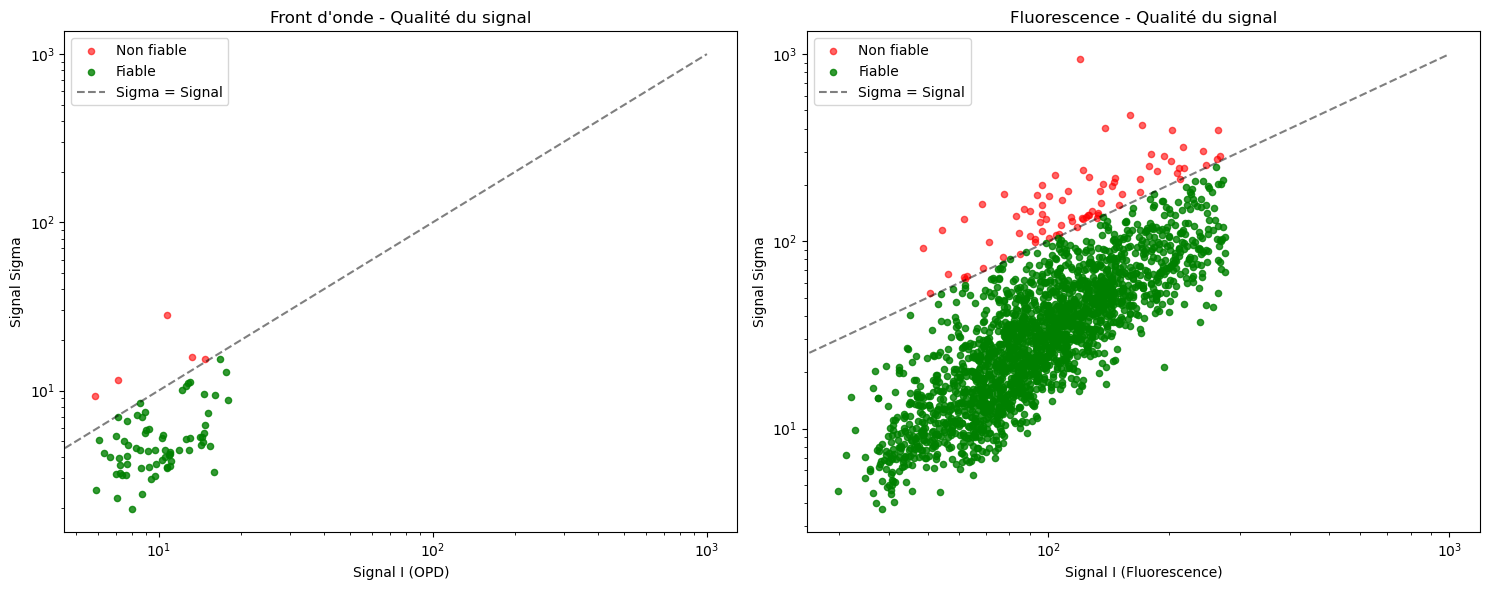

In [117]:
# Analyser chaque modalité
df_front_onde = df_implemented_exclude[df_implemented_exclude['ID_modality'] == 1]
df_fluorescence = df_implemented_exclude[df_implemented_exclude['ID_modality'] == 2]

fiable_front = analyser_qualite_signal(df_front_onde, "Front d'onde")
fiable_fluo = analyser_qualite_signal(df_fluorescence, "Fluorescence")

# Graphique de la qualité
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Données fiables vs non fiables - Front d'onde
df_front_fiable = df_front_onde[fiable_front]
df_front_non_fiable = df_front_onde[~fiable_front]

axes[0].scatter(df_front_non_fiable['signal_I'], df_front_non_fiable['signal_sigma'], 
                alpha=0.6, color='red', label='Non fiable', s=20)
axes[0].scatter(df_front_fiable['signal_I'], df_front_fiable['signal_sigma'], 
                alpha=0.8, color='green', label='Fiable', s=20)
axes[0].plot([0, 1000], [0, 1000], 'k--', alpha=0.5, label='Sigma = Signal')
axes[0].set_xlabel('Signal I (OPD)')
axes[0].set_ylabel('Signal Sigma')
axes[0].set_title("Front d'onde - Qualité du signal")
axes[0].legend()
axes[0].set_xscale('log')
axes[0].set_yscale('log')

# Données fiables vs non fiables - Fluorescence
df_fluo_fiable = df_fluorescence[fiable_fluo]
df_fluo_non_fiable = df_fluorescence[~fiable_fluo]

axes[1].scatter(df_fluo_non_fiable['signal_I'], df_fluo_non_fiable['signal_sigma'], 
                alpha=0.6, color='red', label='Non fiable', s=20)
axes[1].scatter(df_fluo_fiable['signal_I'], df_fluo_fiable['signal_sigma'], 
                alpha=0.8, color='green', label='Fiable', s=20)
axes[1].plot([0, 1000], [0, 1000], 'k--', alpha=0.5, label='Sigma = Signal')
axes[1].set_xlabel('Signal I (Fluorescence)')
axes[1].set_ylabel('Signal Sigma')
axes[1].set_title("Fluorescence - Qualité du signal")
axes[1].legend()
axes[1].set_xscale('log')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [118]:
print("Comparaison des modalités")

if 'ID_modality' in df_implemented_exclude.columns:
    df_front_onde = df_implemented_exclude[df_implemented_exclude['ID_modality'] == 1]
    df_fluorescence = df_implemented_exclude[df_implemented_exclude['ID_modality'] == 2]

    print(f"Répartition :")
    print(f"OPD : {len(df_front_onde)} particules ({len(df_front_onde)/len(df_implemented_exclude)*100:.1f}%)")
    print(f"Fluorescence : {len(df_fluorescence)} particules ({len(df_fluorescence)/len(df_implemented_exclude)*100:.1f}%)")

    print(f"\nVitesse :")
    print(f"Front d'onde : {df_front_onde['speed'].mean():.2f} ± {df_front_onde['speed'].std():.2f} µm/s")
    print(f"Fluorescence : {df_fluorescence['speed'].mean():.2f} ± {df_fluorescence['speed'].std():.2f} µm/s")

    print(f"\nDurées de suivi :")
    print(f"Front d'onde : {df_front_onde['duree_suivi'].mean():.2f} ± {df_front_onde['duree_suivi'].std():.2f} s")
    print(f"Fluorescence : {df_fluorescence['duree_suivi'].mean():.2f} ± {df_fluorescence['duree_suivi'].std():.2f} s")

    if 'signal_I' in df_implemented_exclude.columns:
        print(f"\nSignaux :")
        front_signal_pos = (df_front_onde['signal_I'] > 0).mean() * 100
        fluo_signal_pos = (df_fluorescence['signal_I'] > 0).mean() * 100
        print(f"Front d'onde - Signal positif : {front_signal_pos:.1f}%")
        print(f"Fluorescence - Signal positif : {fluo_signal_pos:.1f}%")
    
    # Test statistique sur les vitesses
    u_stat, p_value = stats.ttest_ind(df_front_onde['speed'].dropna(), 
                                    df_fluorescence['speed'].dropna())
    print(f"\nTest stat vitesse :")
    print(f"u-statistic (Mann-Whitney): {u_stat:.3f}")
    print(f"p-value: {p_value:.3f}")
    if p_value < 0.05:
        print("Différence significative entre les modalités (p < 0.05)")
    else:
        print("Pas de différence significative")

Comparaison des modalités
Répartition :
OPD : 75 particules (3.4%)
Fluorescence : 2156 particules (96.6%)

Vitesse :
Front d'onde : -0.04 ± 0.32 µm/s
Fluorescence : -0.23 ± 1.30 µm/s

Durées de suivi :
Front d'onde : 31.20 ± 14.88 s
Fluorescence : 43.75 ± 28.23 s

Signaux :
Front d'onde - Signal positif : 100.0%
Fluorescence - Signal positif : 100.0%

Test stat vitesse :
u-statistic (Mann-Whitney): 1.237
p-value: 0.216
Pas de différence significative


Analyse du signal de fluorescence des particules crossdétectées
Répartition en fluorescence:
Total particules fluorescence : 2156
Crossdétectées : 163 (7.6%)
Non crossdétectées : 1993 (92.4%)

Signaux de fluorescence:
Signal moyen (crossdétectées) : 117.53
Signal moyen (non crossdétectées) : 104.67
Signal médian (crossdétectées) : 100.50
Signal médian (non crossdétectées) : 94.00
Ratio signal (cross/non-cross): 1.12x


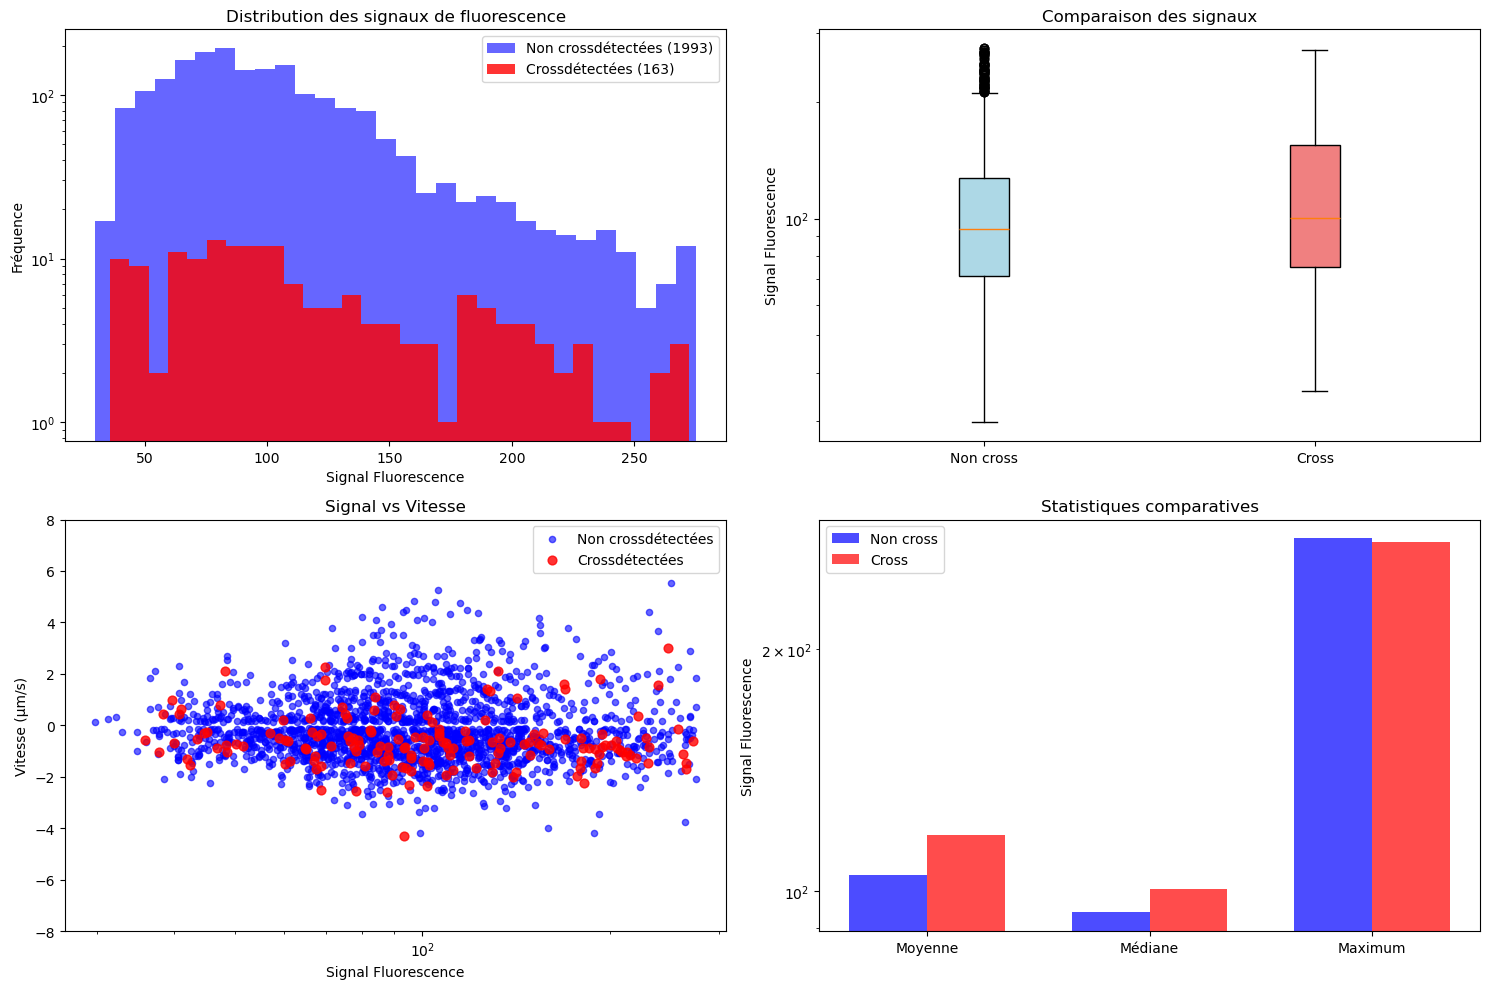

In [119]:
print("Analyse du signal de fluorescence des particules crossdétectées")

# Vérifier que nous avons toutes les colonnes nécessaires
colonnes_necessaires = ['crossdetection_bool_clean', 'ID_modality', 'signal_I']
colonnes_presentes = [col for col in colonnes_necessaires if col in df_implemented_exclude.columns]

if len(colonnes_presentes) == len(colonnes_necessaires):
    
    # Séparer les données de fluorescence
    df_fluorescence = df_implemented_exclude[df_implemented_exclude['ID_modality'] == 2]  # Modalité 2 = Fluorescence
    
    if len(df_fluorescence) > 0:
        # Particules crossdétectées en fluorescence
        df_fluo_cross = df_fluorescence[df_fluorescence['crossdetection_bool_clean'] == True]
        df_fluo_non_cross = df_fluorescence[df_fluorescence['crossdetection_bool_clean'] == False]

        print(f"Répartition en fluorescence:")
        print(f"Total particules fluorescence : {len(df_fluorescence)}")
        print(f"Crossdétectées : {len(df_fluo_cross)} ({len(df_fluo_cross)/len(df_fluorescence)*100:.1f}%)")
        print(f"Non crossdétectées : {len(df_fluo_non_cross)} ({len(df_fluo_non_cross)/len(df_fluorescence)*100:.1f}%)")

        if len(df_fluo_cross) > 0:
            print(f"\nSignaux de fluorescence:")
            print(f"Signal moyen (crossdétectées) : {df_fluo_cross['signal_I'].mean():.2f}")
            print(f"Signal moyen (non crossdétectées) : {df_fluo_non_cross['signal_I'].mean():.2f}")
            print(f"Signal médian (crossdétectées) : {df_fluo_cross['signal_I'].median():.2f}")
            print(f"Signal médian (non crossdétectées) : {df_fluo_non_cross['signal_I'].median():.2f}")

            # Ratio d'intensité
            ratio_moyen = df_fluo_cross['signal_I'].mean() / df_fluo_non_cross['signal_I'].mean()
            print(f"Ratio signal (cross/non-cross): {ratio_moyen:.2f}x")
            
            # Graph
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            
            # Histogrammes comparatifs
            axes[0,0].hist(df_fluo_non_cross['signal_I'].dropna(), bins=30, alpha=0.6, 
                          label=f'Non crossdétectées ({len(df_fluo_non_cross)})', color='blue')
            axes[0,0].hist(df_fluo_cross['signal_I'].dropna(), bins=30, alpha=0.8, 
                          label=f'Crossdétectées ({len(df_fluo_cross)})', color='red')
            axes[0,0].set_xlabel('Signal Fluorescence')
            axes[0,0].set_ylabel('Fréquence')
            axes[0,0].set_title('Distribution des signaux de fluorescence')
            axes[0,0].legend()
            axes[0,0].set_yscale('log')
            
            # Boxplot comparatif
            data_box = [df_fluo_non_cross['signal_I'].dropna(), df_fluo_cross['signal_I'].dropna()]
            box_plot = axes[0,1].boxplot(data_box, labels=['Non cross', 'Cross'], patch_artist=True)
            box_plot['boxes'][0].set_facecolor('lightblue')
            box_plot['boxes'][1].set_facecolor('lightcoral')
            axes[0,1].set_ylabel('Signal Fluorescence')
            axes[0,1].set_title('Comparaison des signaux')
            axes[0,1].set_yscale('log')
            
            # Signal vs Vitesse
            axes[1,0].scatter(df_fluo_non_cross['signal_I'], df_fluo_non_cross['speed'], 
                             alpha=0.6, label='Non crossdétectées', color='blue', s=20)
            axes[1,0].scatter(df_fluo_cross['signal_I'], df_fluo_cross['speed'], 
                             alpha=0.8, label='Crossdétectées', color='red', s=40)
            axes[1,0].set_xlabel('Signal Fluorescence')
            axes[1,0].set_ylabel('Vitesse (µm/s)')
            axes[1,0].set_title('Signal vs Vitesse')
            axes[1,0].legend()
            axes[1,0].set_ylim(-8, 8)
            axes[1,0].set_xscale('log')
            
            # Barres comparatives des statistiques
            stats_cross = [df_fluo_cross['signal_I'].mean(), df_fluo_cross['signal_I'].median(), 
                          df_fluo_cross['signal_I'].max()]
            stats_non_cross = [df_fluo_non_cross['signal_I'].mean(), df_fluo_non_cross['signal_I'].median(), 
                              df_fluo_non_cross['signal_I'].max()]
            
            x = np.arange(3)
            width = 0.35
            axes[1,1].bar(x - width/2, stats_non_cross, width, label='Non cross', alpha=0.7, color='blue')
            axes[1,1].bar(x + width/2, stats_cross, width, label='Cross', alpha=0.7, color='red')
            axes[1,1].set_title('Statistiques comparatives')
            axes[1,1].set_ylabel('Signal Fluorescence')
            axes[1,1].set_xticks(x)
            axes[1,1].set_xticklabels(['Moyenne', 'Médiane', 'Maximum'])
            axes[1,1].legend()
            axes[1,1].set_yscale('log')
            
            plt.tight_layout()
            plt.show()

In [120]:
df_fluorescence = df_implemented_exclude[df_implemented_exclude['ID_modality'] == 2]

if len(df_fluorescence) > 0:
    df_fluo_cross = df_fluorescence[df_fluorescence['crossdetection_bool_clean'] == True]
    df_fluo_non_cross = df_fluorescence[df_fluorescence['crossdetection_bool_clean'] == False]
    
    if len(df_fluo_cross) > 0 and len(df_fluo_non_cross) > 0:
                    
        # Statistiques descriptives
        print(f"métriques descriptives :")
        print(f"{'Métrique':<20} {'Non crossdétectées':<20} {'Crossdétectées':<20} {'Ratio':<10}")
        
        mean_non_cross = df_fluo_non_cross['signal_I'].mean()
        mean_cross = df_fluo_cross['signal_I'].mean()
        ratio_mean = mean_cross / mean_non_cross if mean_non_cross > 0 else np.nan
        
        median_non_cross = df_fluo_non_cross['signal_I'].median()
        median_cross = df_fluo_cross['signal_I'].median()
        ratio_median = median_cross / median_non_cross if median_non_cross > 0 else np.nan
        
        std_non_cross = df_fluo_non_cross['signal_I'].std()
        std_cross = df_fluo_cross['signal_I'].std()
        
        max_non_cross = df_fluo_non_cross['signal_I'].max()
        max_cross = df_fluo_cross['signal_I'].max()
        ratio_max = max_cross / max_non_cross if max_non_cross > 0 else np.nan
        
        print(f"{'Moyenne':<20} {mean_non_cross:<20.2f} {mean_cross:<20.2f} {ratio_mean:<10.2f}")
        print(f"{'Médiane':<20} {median_non_cross:<20.2f} {median_cross:<20.2f} {ratio_median:<10.2f}")
        print(f"{'Écart-type':<20} {std_non_cross:<20.2f} {std_cross:<20.2f} {'N/A':<10}")
        print(f"{'Maximum':<20} {max_non_cross:<20.2f} {max_cross:<20.2f} {ratio_max:<10.2f}")
        
        # Tests de Mann-Whitney
        u_stat, p_value_mw = stats.mannwhitneyu(
            df_fluo_cross['signal_I'].dropna(), 
            df_fluo_non_cross['signal_I'].dropna(),
            alternative='greater'  # Test si crossdétectées > non crossdétectées
        )
        
        print(f"\nTest de Mann-Whitney (crossdétectées > non crossdétectées) :")
        print(f"U-statistic: {u_stat:.2f}")
        print(f"p-value: {p_value_mw:.2e}")
        
        if p_value_mw < 0.05:
            print("Différence significative (p < 0.05)")
        else:
            print("Pas de différence significative (p ≥ 0.05)")
        
        # Analyse des percentiles
        print(f"\nAnalyse des percentiles :")
        percentiles = [10, 25, 50, 75, 90, 95, 99]
        
        print(f"{'Percentile':<15} {'Non cross':<15} {'Cross':<15} {'Ratio':<10}")
        
        for p in percentiles:
            val_non_cross = np.percentile(df_fluo_non_cross['signal_I'].dropna(), p)
            val_cross = np.percentile(df_fluo_cross['signal_I'].dropna(), p)
            ratio_p = val_cross / val_non_cross if val_non_cross > 0 else np.nan
            print(f"{p}%{'':<12} {val_non_cross:<15.2f} {val_cross:<15.2f} {ratio_p:<10.2f}")
        
        # Pourcentage de particules avec signal élevé
        seuils = [mean_non_cross, mean_non_cross * 2, mean_non_cross * 5, mean_non_cross * 10]
        
        print(f"\nParticules avec signaux élevés :")
        print(f"{'Seuil (x moyenne)':<20} {'Non cross (%)':<15} {'Cross (%)':<15}")
        
        for i, seuil in enumerate([1, 2, 5, 10]):
            seuil_val = mean_non_cross * seuil
            pct_non_cross = (df_fluo_non_cross['signal_I'] > seuil_val).mean() * 100
            pct_cross = (df_fluo_cross['signal_I'] > seuil_val).mean() * 100
            print(f"{seuil}x{'':<17} {pct_non_cross:<15.1f} {pct_cross:<15.1f}")

métriques descriptives :
Métrique             Non crossdétectées   Crossdétectées       Ratio     
Moyenne              104.67               117.53               1.12      
Médiane              94.00                100.50               1.07      
Écart-type           47.52                59.16                N/A       
Maximum              275.17               272.33               0.99      

Test de Mann-Whitney (crossdétectées > non crossdétectées) :
U-statistic: 178530.50
p-value: 1.76e-02
Différence significative (p < 0.05)

Analyse des percentiles :
Percentile      Non cross       Cross           Ratio     
10%             53.83           48.98           0.91      
25%             71.00           74.79           1.05      
50%             94.00           100.50          1.07      
75%             127.33          154.33          1.21      
90%             171.17          207.23          1.21      
95%             206.03          229.89          1.12      
99%             255.97    

In [121]:
print("Synthèse de la brillance des particules crossdétetées en fluo")

if all(col in df_implemented_exclude.columns for col in ['crossdetection_bool_clean', 'ID_modality', 'signal_I']):
    df_fluorescence = df_implemented_exclude[df_implemented_exclude['ID_modality'] == 2]

    if len(df_fluorescence) > 0:
        df_fluo_cross = df_fluorescence[df_fluorescence['crossdetection_bool_clean'] == True]
        df_fluo_non_cross = df_fluorescence[df_fluorescence['crossdetection_bool_clean'] == False]
        
        if len(df_fluo_cross) > 0:
            ratio_mean = df_fluo_cross['signal_I'].mean() / df_fluo_non_cross['signal_I'].mean()
            ratio_median = df_fluo_cross['signal_I'].median() / df_fluo_non_cross['signal_I'].median()
            
            print(f"Particules crossdétectées en fluorescence: {len(df_fluo_cross)}", f'alors qu\'il y a {len(df_implemented_exclude[df_implemented_exclude['crossdetection_bool_clean'] == True])} particules détectées au total.')
            print(f"Signal moyen: {ratio_mean:.2f}x plus élevé que les non crossdétectées")
            print(f"Signal médian: {ratio_median:.2f}x plus élevé que les non crossdétectées")
            
            # Conclusion
            if ratio_mean > 2.0:
                print(f"\nLes particules crossdétectées sont significativement plus brillantes en fluorescence ({ratio_mean:.1f}x plus élevé)")
            elif ratio_mean > 1.5:
                print(f"\nLes particules crossdétectées sont modérément plus brillantes en fluorescence ({ratio_mean:.1f}x plus élevé)")
            elif ratio_mean > 1.1:
                print(f"\nLes particules crossdétectées sont légèrement plus brillantes en fluorescence ({ratio_mean:.1f}x plus élevé)")
            else:
                print(f"\nPas de différence notable de brillance entre crossdétectées et non crossdétectées")

Synthèse de la brillance des particules crossdétetées en fluo
Particules crossdétectées en fluorescence: 163 alors qu'il y a 170 particules détectées au total.
Signal moyen: 1.12x plus élevé que les non crossdétectées
Signal médian: 1.07x plus élevé que les non crossdétectées

Les particules crossdétectées sont légèrement plus brillantes en fluorescence (1.1x plus élevé)


In [122]:
print("Synthèse de la brillance des particules crossdétetées en OPD")

if all(col in df_implemented_exclude.columns for col in ['crossdetection_bool_clean', 'ID_modality', 'signal_I']):
    df_opd = df_implemented_exclude[df_implemented_exclude['ID_modality'] == 1]

    if len(df_opd) > 0:
        df_opd_cross = df_opd[df_opd['crossdetection_bool_clean'] == True]
        df_opd_non_cross = df_opd[df_opd['crossdetection_bool_clean'] == False]

        if len(df_opd_cross) > 0:
            ratio_mean = df_opd_cross['signal_I'].mean() / df_opd_non_cross['signal_I'].mean()
            ratio_median = df_opd_cross['signal_I'].median() / df_opd_non_cross['signal_I'].median()

            print(f"Particules crossdétectées en OPD: {len(df_opd_cross)}", f'alors qu\'il y a {len(df_implemented_exclude[df_implemented_exclude['crossdetection_bool_clean'] == True])} particules détectées au total.')
            print(f"Signal moyen: {ratio_mean:.2f}x plus élevé que les non crossdétectées")
            print(f"Signal médian: {ratio_median:.2f}x plus élevé que les non crossdétectées")
            
            # Conclusion
            if ratio_mean > 2.0:
                print(f"\nLes particules crossdétectées sont significativement plus brillantes en OPD ({ratio_mean:.1f}x plus élevé)")
            elif ratio_mean > 1.5:
                print(f"\nLes particules crossdétectées sont modérément plus brillantes en OPD ({ratio_mean:.1f}x plus élevé)")
            elif ratio_mean > 1.1:
                print(f"\nLes particules crossdétectées sont légèrement plus brillantes en OPD ({ratio_mean:.1f}x plus élevé)")
            else:
                print(f"\nPas de différence notable de brillance entre crossdétectées et non crossdétectées")

Synthèse de la brillance des particules crossdétetées en OPD
Particules crossdétectées en OPD: 7 alors qu'il y a 170 particules détectées au total.
Signal moyen: 0.98x plus élevé que les non crossdétectées
Signal médian: 0.78x plus élevé que les non crossdétectées

Pas de différence notable de brillance entre crossdétectées et non crossdétectées


In [123]:
df = df_implemented_exclude.copy()

# 1. Test entre OPD et Fluorescence (toutes particules)
opd_signal = df[df['ID_modality'] == 1]['signal_I'].dropna()
fluo_signal = df[df['ID_modality'] == 2]['signal_I'].dropna()
u_mod, p_mod = mannwhitneyu(opd_signal, fluo_signal, alternative='two-sided')
print(f"Test Mann-Whitney OPD vs Fluorescence : U={u_mod:.2f}, p={p_mod:.3e}")

# 2. Test crossdétectées vs non crossdétectées pour toutes les particules
cross_all = df[df['crossdetection_bool_clean'] == True]['signal_I'].dropna()
non_cross_all = df[df['crossdetection_bool_clean'] == False]['signal_I'].dropna()
u_all, p_all = mannwhitneyu(cross_all, non_cross_all, alternative='two-sided')
print(f"Test Mann-Whitney cross vs non cross (toutes particules) : U={u_all:.2f}, p={p_all:.3e}")

# 3. Test crossdétectées vs non crossdétectées pour OPD
opd_cross = df[(df['ID_modality'] == 1) & (df['crossdetection_bool_clean'] == True)]['signal_I'].dropna()
opd_non_cross = df[(df['ID_modality'] == 1) & (df['crossdetection_bool_clean'] == False)]['signal_I'].dropna()
u_opd, p_opd = mannwhitneyu(opd_cross, opd_non_cross, alternative='two-sided')
print(f"Test Mann-Whitney OPD cross vs non cross : U={u_opd:.2f}, p={p_opd:.3e}")

# 4. Test crossdétectées vs non crossdétectées pour Fluorescence
fluo_cross = df[(df['ID_modality'] == 2) & (df['crossdetection_bool_clean'] == True)]['signal_I'].dropna()
fluo_non_cross = df[(df['ID_modality'] == 2) & (df['crossdetection_bool_clean'] == False)]['signal_I'].dropna()
u_fluo, p_fluo = mannwhitneyu(fluo_cross, fluo_non_cross, alternative='two-sided')
print(f"Test Mann-Whitney Fluorescence cross vs non cross : U={u_fluo:.2f}, p={p_fluo:.3e}")

# 5. Test crossdétectées OPD vs crossdétectées Fluorescence
u_cross, p_cross = mannwhitneyu(opd_cross, fluo_cross, alternative='two-sided')
print(f"Test Mann-Whitney OPD cross vs Fluorescence cross : U={u_cross:.2f}, p={p_cross:.3e}")

# 6. Test non crossdétectées OPD vs non crossdétectées Fluorescence
u_non_cross, p_non_cross = mannwhitneyu(opd_non_cross, fluo_non_cross, alternative='two-sided')
print(f"Test Mann-Whitney OPD non cross vs Fluorescence non cross : U={u_non_cross:.2f}, p={p_non_cross:.3e}")


Test Mann-Whitney OPD vs Fluorescence : U=0.00, p=3.447e-49
Test Mann-Whitney cross vs non cross (toutes particules) : U=189806.50, p=7.012e-02
Test Mann-Whitney OPD cross vs non cross : U=192.00, p=4.154e-01
Test Mann-Whitney Fluorescence cross vs non cross : U=178530.50, p=3.512e-02
Test Mann-Whitney OPD cross vs Fluorescence cross : U=0.00, p=7.815e-06
Test Mann-Whitney OPD non cross vs Fluorescence non cross : U=0.00, p=8.653e-45


#### Analyser la crossdétection des cargos en fonction de la modalité (fluorescence/OPD), du signal_I et du fait qu'ils font demi-tour ou non :

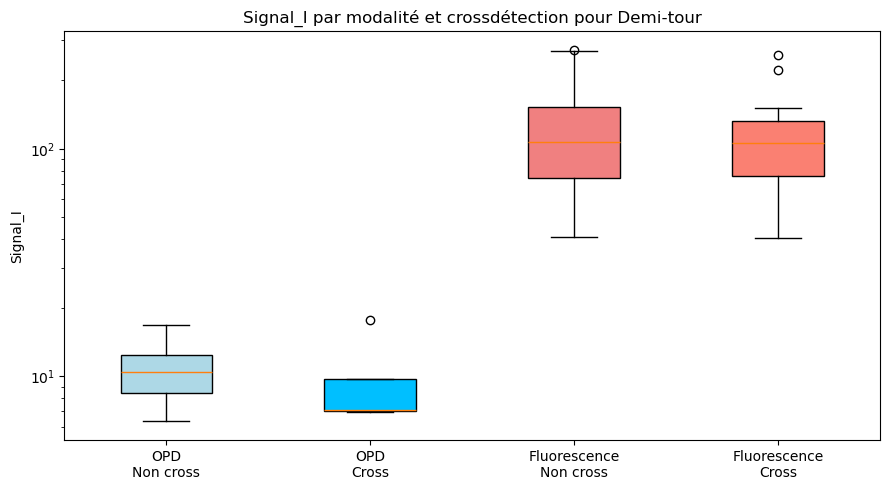

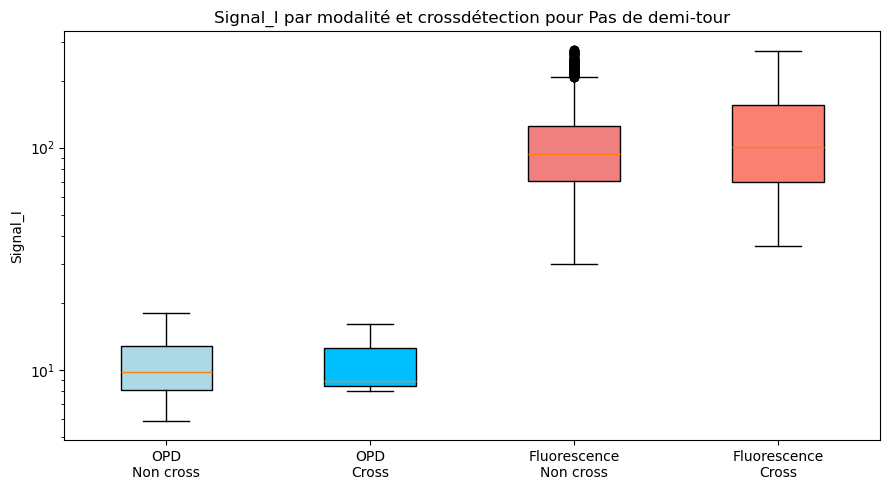

In [124]:
# Préparation des données pour le boxplot
df = df_implemented_exclude.copy()
modalites = {1: "OPD", 2: "Fluorescence"}

for demi_tour_val, demi_tour_label in zip([True, False], ["Demi-tour", "Pas de demi-tour"]):
    df_sub = df[df['demi_tour'] == demi_tour_val]
    data_plot = []
    labels_plot = []
    colors = []
    for mod_val, mod_name in modalites.items():
        # Non crossdétectées
        df_mod_non_cross = df_sub[(df_sub['ID_modality'] == mod_val) & (df_sub['crossdetection_bool_clean'] == False)]
        data_plot.append(df_mod_non_cross['signal_I'].dropna())
        labels_plot.append(f"{mod_name}\nNon cross")
        colors.append('lightblue' if mod_val == 1 else 'lightcoral')
        # Crossdétectées
        df_mod_cross = df_sub[(df_sub['ID_modality'] == mod_val) & (df_sub['crossdetection_bool_clean'] == True)]
        data_plot.append(df_mod_cross['signal_I'].dropna())
        labels_plot.append(f"{mod_name}\nCross")
        colors.append('deepskyblue' if mod_val == 1 else 'salmon')
    plt.figure(figsize=(9,5))
    box = plt.boxplot(data_plot, labels=labels_plot, patch_artist=True)
    plt.yscale('log')
    plt.title(f'Signal_I par modalité et crossdétection pour {demi_tour_label}')
    plt.ylabel('Signal_I')
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
    plt.tight_layout()
    plt.show()

=== ANALYSE STATISTIQUE COMPLÈTE SIGNAL_I ===
=== MODALITÉ x CROSSDÉTECTION x DEMI-TOURS ===

1. Statistiques descriptives globales : 
Total particules analysées: 2231

Répartition demi-tours:
Pas de demi-tour: 2073 (92.9%)
Demi-tour: 158 (7.1%)

Répartition crossdétection:
Non crossdétectées: 2061 (92.4%)
Crossdétectées: 170 (7.6%)

Répartition modalités:
OPD: 75 (3.4%)
Fluorescence: 2156 (96.6%)

2. Analyse détaillée par groupes :

--- DEMI-TOUR ---
Nombre total de particules: 158

OPD:
  Non crossdétectées: 20
  Crossdétectées: 4
  Signal non cross - Moyenne: 10.43, Médiane: 10.43, Écart-type: 2.78
  Signal cross - Moyenne: 9.69, Médiane: 7.08, Écart-type: 5.27
  Test Mann-Whitney (cross vs non cross): U=26, p=0.3091
    → Pas de différence significative

Fluorescence:
  Non crossdétectées: 121
  Crossdétectées: 13
  Signal non cross - Moyenne: 120.72, Médiane: 106.67, Écart-type: 57.07
  Signal cross - Moyenne: 119.50, Médiane: 106.25, Écart-type: 60.73
  Test Mann-Whitney (cross v

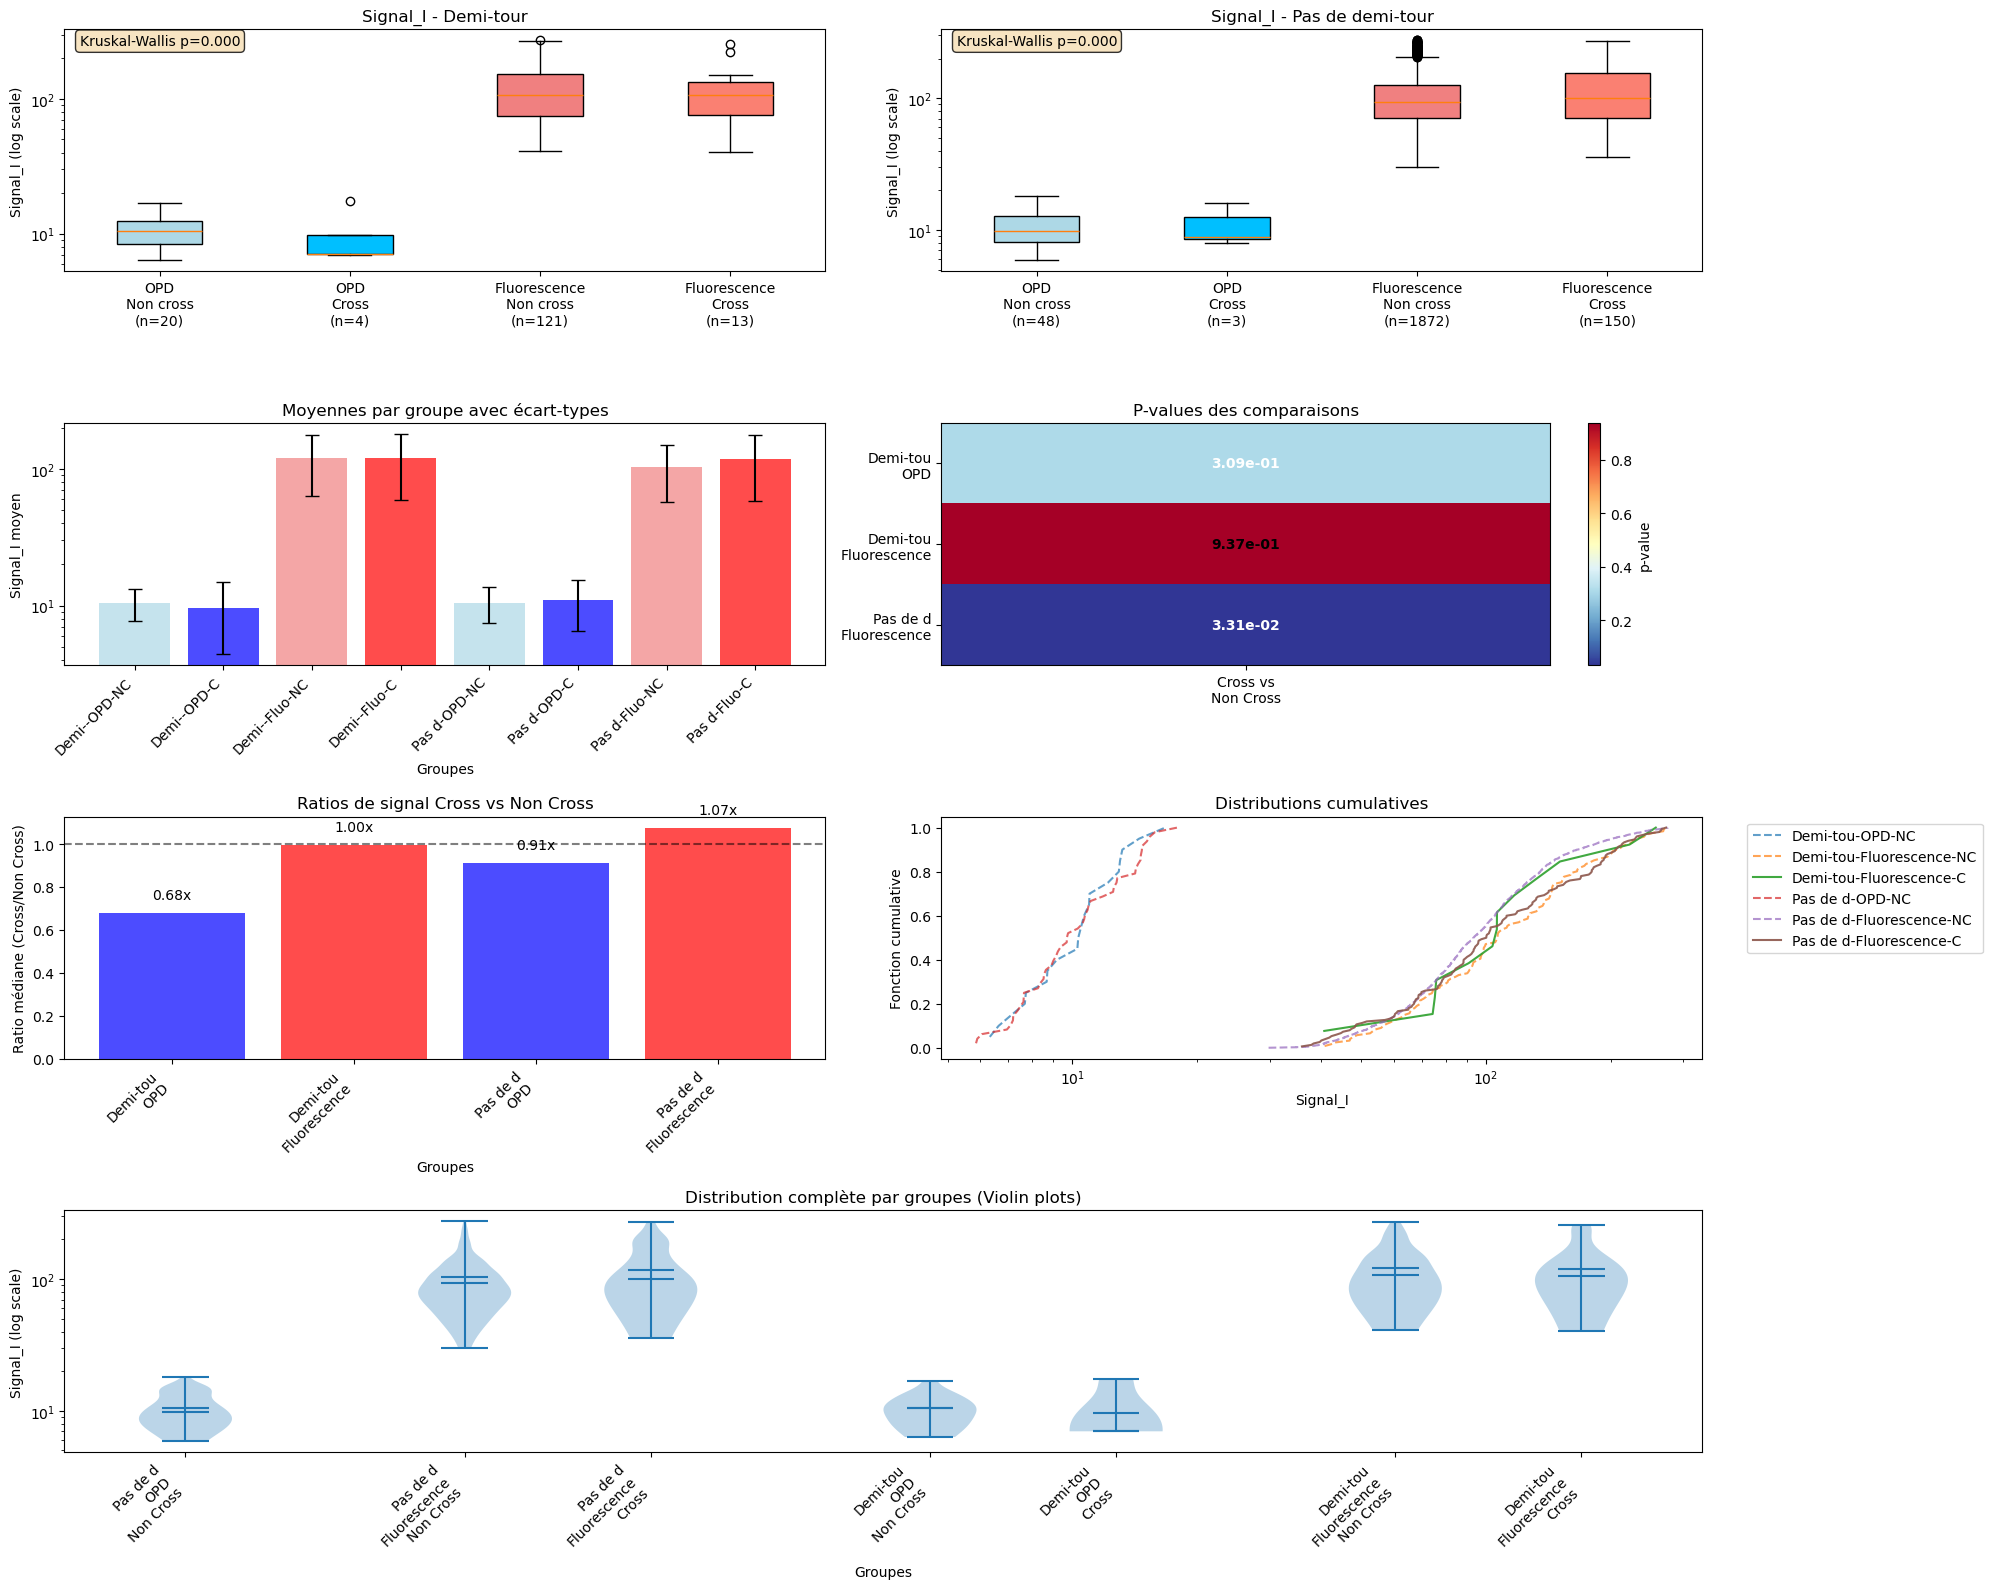


5. Résumé des conclusions statistiques :

1. EFFET DE LA CROSSDÉTECTION:
   - Pas de demi-tour + Fluorescence: La crossdétection augmente significativement le signal (ratio=1.07x, p=0.0331)

Sur 3 comparaisons, 1 montrent un effet significatif de la crossdétection.

2. EFFET DES MODALITÉS:

Demi-tour:
   Non cross - OPD vs Fluo: ratio=0.10x, p=0.0000
   Cross - OPD vs Fluo: ratio=0.07x, p=0.0008

Pas de demi-tour:
   Non cross - OPD vs Fluo: ratio=0.10x, p=0.0000

3. EFFET DES DEMI-TOURS:

OPD:
   Non cross - Demi-tour vs Normal: ratio=1.07x, p=0.9410

Fluorescence:
   Non cross - Demi-tour vs Normal: ratio=1.14x, p=0.0021
   Cross - Demi-tour vs Normal: ratio=1.06x, p=0.7899


In [125]:
# Analyse statistique complète du signal par modalité, crossdétection et demi-tours

# Préparation des données
df = df_implemented_exclude.copy()
modalites = {1: "OPD", 2: "Fluorescence"}

print("=== ANALYSE STATISTIQUE COMPLÈTE SIGNAL_I ===")
print("=== MODALITÉ x CROSSDÉTECTION x DEMI-TOURS ===")
print()

# ==================== 1. STATISTIQUES DESCRIPTIVES GLOBALES ====================
print("1. Statistiques descriptives globales : ")

# Vue d'ensemble des groupes
total_particules = len(df)
print(f"Total particules analysées: {total_particules}")

# Répartition des demi-tours
demi_tour_counts = df['demi_tour'].value_counts()
print(f"\nRépartition demi-tours:")
print(f"Pas de demi-tour: {demi_tour_counts[False]} ({demi_tour_counts[False]/total_particules*100:.1f}%)")
print(f"Demi-tour: {demi_tour_counts[True]} ({demi_tour_counts[True]/total_particules*100:.1f}%)")

# Répartition crossdétection
cross_counts = df['crossdetection_bool_clean'].value_counts()
print(f"\nRépartition crossdétection:")
print(f"Non crossdétectées: {cross_counts[False]} ({cross_counts[False]/total_particules*100:.1f}%)")
print(f"Crossdétectées: {cross_counts[True]} ({cross_counts[True]/total_particules*100:.1f}%)")

# Répartition modalités
modalite_counts = df['ID_modality'].value_counts()
print(f"\nRépartition modalités:")
for mod_id, mod_name in modalites.items():
    if mod_id in modalite_counts:
        count = modalite_counts[mod_id]
        print(f"{mod_name}: {count} ({count/total_particules*100:.1f}%)")

print("\n" + "="*80)

# ==================== 2. ANALYSE PAR GROUPES ====================
print("2. Analyse détaillée par groupes :")

# Création de tous les sous-groupes
groupes_stats = {}

for demi_tour_val, demi_tour_label in zip([True, False], ["Demi-tour", "Pas de demi-tour"]):
    print(f"\n--- {demi_tour_label.upper()} ---")
    df_demi_tour = df[df['demi_tour'] == demi_tour_val]
    
    if len(df_demi_tour) == 0:
        print(f"Aucune donnée pour {demi_tour_label}")
        continue
    
    print(f"Nombre total de particules: {len(df_demi_tour)}")
    
    groupes_stats[demi_tour_label] = {}
    
    for mod_val, mod_name in modalites.items():
        print(f"\n{mod_name}:")
        
        # Sous-groupes par modalité et crossdétection
        df_mod_non_cross = df_demi_tour[
            (df_demi_tour['ID_modality'] == mod_val) & 
            (df_demi_tour['crossdetection_bool_clean'] == False)
        ]
        df_mod_cross = df_demi_tour[
            (df_demi_tour['ID_modality'] == mod_val) & 
            (df_demi_tour['crossdetection_bool_clean'] == True)
        ]
        
        print(f"  Non crossdétectées: {len(df_mod_non_cross)}")
        print(f"  Crossdétectées: {len(df_mod_cross)}")
        
        # Statistiques signal_I
        if len(df_mod_non_cross) > 0:
            signal_non_cross = df_mod_non_cross['signal_I'].dropna()
            print(f"  Signal non cross - Moyenne: {signal_non_cross.mean():.2f}, "
                  f"Médiane: {signal_non_cross.median():.2f}, "
                  f"Écart-type: {signal_non_cross.std():.2f}")
        else:
            signal_non_cross = pd.Series(dtype=float)
        
        if len(df_mod_cross) > 0:
            signal_cross = df_mod_cross['signal_I'].dropna()
            print(f"  Signal cross - Moyenne: {signal_cross.mean():.2f}, "
                  f"Médiane: {signal_cross.median():.2f}, "
                  f"Écart-type: {signal_cross.std():.2f}")
        else:
            signal_cross = pd.Series(dtype=float)
        
        # Stockage pour analyses ultérieures
        groupes_stats[demi_tour_label][mod_name] = {
            'non_cross': signal_non_cross,
            'cross': signal_cross,
            'df_non_cross': df_mod_non_cross,
            'df_cross': df_mod_cross
        }
        
        # Test statistique si données suffisantes
        if len(signal_cross) > 3 and len(signal_non_cross) > 3:
            u_stat, p_val = mannwhitneyu(signal_cross, signal_non_cross, alternative='two-sided')
            print(f"  Test Mann-Whitney (cross vs non cross): U={u_stat:.0f}, p={p_val:.4f}")
            
            if p_val < 0.05:
                if signal_cross.median() > signal_non_cross.median():
                    print(f"    → Crossdétectées significativement plus élevées")
                else:
                    print(f"    → Non crossdétectées significativement plus élevées")
            else:
                print(f"    → Pas de différence significative")

print("\n" + "="*80)

# ==================== 3. TESTS STATISTIQUES GLOBAUX ====================
print("3. Tests statistiques globaux :")

# Test de Kruskal-Wallis pour tous les groupes
print("\nTest de Kruskal-Wallis (comparaison de tous les groupes):")

# Préparation des données pour le test global
all_groups = []
group_labels = []

for demi_tour_label, modalites_data in groupes_stats.items():
    for mod_name, cross_data in modalites_data.items():
        if len(cross_data['non_cross']) > 0:
            all_groups.append(cross_data['non_cross'])
            group_labels.append(f"{demi_tour_label}-{mod_name}-NonCross")
        
        if len(cross_data['cross']) > 0:
            all_groups.append(cross_data['cross'])
            group_labels.append(f"{demi_tour_label}-{mod_name}-Cross")

# Filtrer les groupes non vides
valid_groups = [(group, label) for group, label in zip(all_groups, group_labels) if len(group) > 0]

if len(valid_groups) >= 3:
    groups_data = [group for group, label in valid_groups]
    groups_labels = [label for group, label in valid_groups]
    
    kruskal_stat, kruskal_p = kruskal(*groups_data)
    print(f"Kruskal-Wallis: H={kruskal_stat:.3f}, p={kruskal_p:.4f}")
    
    if kruskal_p < 0.05:
        print("Différences significatives entre les groupes détectées")
    else:
        print("Pas de différences significatives entre les groupes")
    
    print(f"Groupes comparés: {', '.join(groups_labels)}")

# Tests par paires spécifiques
print("\n" + "="*50)
print("TESTS PAR PAIRES SPÉCIFIQUES:")

# 1. Effet de la crossdétection par modalité et demi-tour
print("\n1. Effet de la crossdétection:")
for demi_tour_label, modalites_data in groupes_stats.items():
    for mod_name, cross_data in modalites_data.items():
        if len(cross_data['cross']) > 3 and len(cross_data['non_cross']) > 3:
            u_stat, p_val = mannwhitneyu(cross_data['cross'], cross_data['non_cross'], 
                                       alternative='two-sided')
            ratio = cross_data['cross'].median() / cross_data['non_cross'].median() if cross_data['non_cross'].median() > 0 else np.nan
            
            print(f"{demi_tour_label} - {mod_name}: p={p_val:.4f}, ratio médiane={ratio:.2f}x")

# 2. Effet de la modalité
print("\n2. Effet de la modalité (OPD vs Fluorescence):")
for demi_tour_label, modalites_data in groupes_stats.items():
    if 'OPD' in modalites_data and 'Fluorescence' in modalites_data:
        # Non crossdétectées
        opd_non_cross = modalites_data['OPD']['non_cross']
        fluo_non_cross = modalites_data['Fluorescence']['non_cross']
        
        if len(opd_non_cross) > 3 and len(fluo_non_cross) > 3:
            u_stat, p_val = mannwhitneyu(opd_non_cross, fluo_non_cross, alternative='two-sided')
            print(f"{demi_tour_label} - Non cross (OPD vs Fluo): p={p_val:.4f}")
        
        # Crossdétectées
        opd_cross = modalites_data['OPD']['cross']
        fluo_cross = modalites_data['Fluorescence']['cross']
        
        if len(opd_cross) > 3 and len(fluo_cross) > 3:
            u_stat, p_val = mannwhitneyu(opd_cross, fluo_cross, alternative='two-sided')
            print(f"{demi_tour_label} - Cross (OPD vs Fluo): p={p_val:.4f}")

# 3. Effet des demi-tours
print("\n3. Effet des demi-tours:")
if 'Demi-tour' in groupes_stats and 'Pas de demi-tour' in groupes_stats:
    for mod_name in modalites.values():
        if mod_name in groupes_stats['Demi-tour'] and mod_name in groupes_stats['Pas de demi-tour']:
            # Non crossdétectées
            demitour_non_cross = groupes_stats['Demi-tour'][mod_name]['non_cross']
            normal_non_cross = groupes_stats['Pas de demi-tour'][mod_name]['non_cross']
            
            if len(demitour_non_cross) > 3 and len(normal_non_cross) > 3:
                u_stat, p_val = mannwhitneyu(demitour_non_cross, normal_non_cross, alternative='two-sided')
                print(f"{mod_name} - Non cross (Demi-tour vs Normal): p={p_val:.4f}")
            
            # Crossdétectées
            demitour_cross = groupes_stats['Demi-tour'][mod_name]['cross']
            normal_cross = groupes_stats['Pas de demi-tour'][mod_name]['cross']
            
            if len(demitour_cross) > 3 and len(normal_cross) > 3:
                u_stat, p_val = mannwhitneyu(demitour_cross, normal_cross, alternative='two-sided')
                print(f"{mod_name} - Cross (Demi-tour vs Normal): p={p_val:.4f}")

print("\n" + "="*80)

# ==================== 4. VISUALISATIONS STATISTIQUES ====================
print("4. Visualisations statistiques :")

# Figure principale avec analyses statistiques
fig = plt.figure(figsize=(20, 16))

# 1. Box plots par demi-tour (reproduction du code original avec stats)
for idx, (demi_tour_val, demi_tour_label) in enumerate(zip([True, False], ["Demi-tour", "Pas de demi-tour"])):
    plt.subplot(4, 2, idx + 1)
    
    df_sub = df[df['demi_tour'] == demi_tour_val]
    data_plot = []
    labels_plot = []
    colors = []
    
    for mod_val, mod_name in modalites.items():
        # Non crossdétectées
        df_mod_non_cross = df_sub[(df_sub['ID_modality'] == mod_val) & 
                                 (df_sub['crossdetection_bool_clean'] == False)]
        if len(df_mod_non_cross) > 0:
            data_plot.append(df_mod_non_cross['signal_I'].dropna())
            labels_plot.append(f"{mod_name}\nNon cross\n(n={len(df_mod_non_cross)})")
            colors.append('lightblue' if mod_val == 1 else 'lightcoral')
        
        # Crossdétectées
        df_mod_cross = df_sub[(df_sub['ID_modality'] == mod_val) & 
                             (df_sub['crossdetection_bool_clean'] == True)]
        if len(df_mod_cross) > 0:
            data_plot.append(df_mod_cross['signal_I'].dropna())
            labels_plot.append(f"{mod_name}\nCross\n(n={len(df_mod_cross)})")
            colors.append('deepskyblue' if mod_val == 1 else 'salmon')
    
    if data_plot:
        box = plt.boxplot(data_plot, labels=labels_plot, patch_artist=True)
        plt.yscale('log')
        plt.title(f'Signal_I - {demi_tour_label}')
        plt.ylabel('Signal_I (log scale)')
        
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
        
        # Ajouter des statistiques sur le graphique
        if len(data_plot) >= 2:
            # Test de Kruskal-Wallis pour ce groupe
            try:
                kruskal_stat, kruskal_p = kruskal(*data_plot)
                plt.text(0.02, 0.98, f'Kruskal-Wallis p={kruskal_p:.3f}', 
                        transform=plt.gca().transAxes, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
            except:
                pass

# 2. Comparaison des moyennes par groupe
plt.subplot(4, 2, 3)
# Préparer les données pour le graphique en barres
groupe_names = []
moyennes = []
stds = []
colors_bar = []

for demi_tour_label, modalites_data in groupes_stats.items():
    for mod_name, cross_data in modalites_data.items():
        if len(cross_data['non_cross']) > 0:
            groupe_names.append(f"{demi_tour_label[:5]}-{mod_name[:4]}-NC")
            moyennes.append(cross_data['non_cross'].mean())
            stds.append(cross_data['non_cross'].std())
            colors_bar.append('lightblue' if 'OPD' in mod_name else 'lightcoral')
        
        if len(cross_data['cross']) > 0:
            groupe_names.append(f"{demi_tour_label[:5]}-{mod_name[:4]}-C")
            moyennes.append(cross_data['cross'].mean())
            stds.append(cross_data['cross'].std())
            colors_bar.append('blue' if 'OPD' in mod_name else 'red')

if moyennes:
    x_pos = np.arange(len(groupe_names))
    bars = plt.bar(x_pos, moyennes, yerr=stds, capsize=5, color=colors_bar, alpha=0.7)
    plt.xlabel('Groupes')
    plt.ylabel('Signal_I moyen')
    plt.title('Moyennes par groupe avec écart-types')
    plt.xticks(x_pos, groupe_names, rotation=45, ha='right')
    plt.yscale('log')

# 3. Heatmap des p-values
plt.subplot(4, 2, 4)
# Créer une matrice des p-values pour les comparaisons principales
pvalues_matrix = []
labels_matrix = []

# Comparaisons crossdétection vs non crossdétection
for demi_tour_label, modalites_data in groupes_stats.items():
    for mod_name, cross_data in modalites_data.items():
        if len(cross_data['cross']) > 3 and len(cross_data['non_cross']) > 3:
            u_stat, p_val = mannwhitneyu(cross_data['cross'], cross_data['non_cross'], 
                                       alternative='two-sided')
            pvalues_matrix.append(p_val)
            labels_matrix.append(f"{demi_tour_label[:8]}\n{mod_name}")

if pvalues_matrix:
    pvalues_array = np.array(pvalues_matrix).reshape(-1, 1)
    im = plt.imshow(pvalues_array, cmap='RdYlBu_r', aspect='auto')
    plt.colorbar(im, label='p-value')
    plt.yticks(range(len(labels_matrix)), labels_matrix)
    plt.xticks([0], ['Cross vs\nNon Cross'])
    plt.title('P-values des comparaisons')
    
    # Ajouter les valeurs sur la heatmap
    for i in range(len(pvalues_matrix)):
        color = 'white' if pvalues_matrix[i] < 0.5 else 'black'
        plt.text(0, i, f'{pvalues_matrix[i]:.2e}', ha='center', va='center', 
                color=color, fontweight='bold')

# 4. Analyse des ratios cross/non-cross
plt.subplot(4, 2, 5)
ratios = []
ratio_labels = []

for demi_tour_label, modalites_data in groupes_stats.items():
    for mod_name, cross_data in modalites_data.items():
        if len(cross_data['cross']) > 0 and len(cross_data['non_cross']) > 0:
            ratio = cross_data['cross'].median() / cross_data['non_cross'].median()
            if not np.isnan(ratio) and ratio > 0:
                ratios.append(ratio)
                ratio_labels.append(f"{demi_tour_label[:8]}\n{mod_name}")

if ratios:
    colors_ratio = ['blue' if 'OPD' in label else 'red' for label in ratio_labels]
    bars = plt.bar(range(len(ratios)), ratios, color=colors_ratio, alpha=0.7)
    plt.axhline(y=1, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('Groupes')
    plt.ylabel('Ratio médiane (Cross/Non Cross)')
    plt.title('Ratios de signal Cross vs Non Cross')
    plt.xticks(range(len(ratios)), ratio_labels, rotation=45, ha='right')
    
    # Ajouter les valeurs sur les barres
    for i, (bar, ratio) in enumerate(zip(bars, ratios)):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                f'{ratio:.2f}x', ha='center', va='bottom')

# 5. Distribution cumulative
plt.subplot(4, 2, 6)
for demi_tour_label, modalites_data in groupes_stats.items():
    for mod_name, cross_data in modalites_data.items():
        if len(cross_data['non_cross']) > 10:
            sorted_data = np.sort(cross_data['non_cross'])
            y = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            plt.plot(sorted_data, y, label=f"{demi_tour_label[:8]}-{mod_name}-NC", 
                    linestyle='--', alpha=0.7)
        
        if len(cross_data['cross']) > 10:
            sorted_data = np.sort(cross_data['cross'])
            y = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            plt.plot(sorted_data, y, label=f"{demi_tour_label[:8]}-{mod_name}-C", 
                    linestyle='-', alpha=0.9)

plt.xscale('log')
plt.xlabel('Signal_I')
plt.ylabel('Fonction cumulative')
plt.title('Distributions cumulatives')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. Violin plot comparatif
plt.subplot(4, 1, 4)
# Préparer les données pour violin plot
violin_data = []
violin_labels = []
violin_positions = []
pos = 0

for demi_tour_label in ["Pas de demi-tour", "Demi-tour"]:
    if demi_tour_label in groupes_stats:
        modalites_data = groupes_stats[demi_tour_label]
        for mod_name in ['OPD', 'Fluorescence']:
            if mod_name in modalites_data:
                cross_data = modalites_data[mod_name]
                
                if len(cross_data['non_cross']) > 3:
                    violin_data.append(cross_data['non_cross'])
                    violin_labels.append(f"{demi_tour_label[:8]}\n{mod_name}\nNon Cross")
                    violin_positions.append(pos)
                    pos += 1
                
                if len(cross_data['cross']) > 3:
                    violin_data.append(cross_data['cross'])
                    violin_labels.append(f"{demi_tour_label[:8]}\n{mod_name}\nCross")
                    violin_positions.append(pos)
                    pos += 1
                
                pos += 0.5  # Espacement entre modalités

if violin_data:
    parts = plt.violinplot(violin_data, positions=violin_positions, showmeans=True, showmedians=True)
    plt.yscale('log')
    plt.xlabel('Groupes')
    plt.ylabel('Signal_I (log scale)')
    plt.title('Distribution complète par groupes (Violin plots)')
    plt.xticks(violin_positions, violin_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n" + "="*80)

# ==================== 5. RÉSUMÉ STATISTIQUE ====================
print("5. Résumé des conclusions statistiques :")

print("\n1. EFFET DE LA CROSSDÉTECTION:")
significant_cross_effects = 0
total_comparisons = 0

for demi_tour_label, modalites_data in groupes_stats.items():
    for mod_name, cross_data in modalites_data.items():
        if len(cross_data['cross']) > 3 and len(cross_data['non_cross']) > 3:
            total_comparisons += 1
            u_stat, p_val = mannwhitneyu(cross_data['cross'], cross_data['non_cross'], 
                                       alternative='two-sided')
            
            if p_val < 0.05:
                significant_cross_effects += 1
                ratio = cross_data['cross'].median() / cross_data['non_cross'].median()
                effect = "augmente" if ratio > 1 else "diminue"
                print(f"   - {demi_tour_label} + {mod_name}: La crossdétection {effect} significativement le signal (ratio={ratio:.2f}x, p={p_val:.4f})")

print(f"\nSur {total_comparisons} comparaisons, {significant_cross_effects} montrent un effet significatif de la crossdétection.")

print("\n2. EFFET DES MODALITÉS:")
# Comparer OPD vs Fluorescence dans chaque condition
for demi_tour_label, modalites_data in groupes_stats.items():
    if 'OPD' in modalites_data and 'Fluorescence' in modalites_data:
        print(f"\n{demi_tour_label}:")
        
        # Non crossdétectées
        opd_nc = modalites_data['OPD']['non_cross']
        fluo_nc = modalites_data['Fluorescence']['non_cross']
        if len(opd_nc) > 3 and len(fluo_nc) > 3:
            u_stat, p_val = mannwhitneyu(opd_nc, fluo_nc, alternative='two-sided')
            ratio = opd_nc.median() / fluo_nc.median() if fluo_nc.median() > 0 else np.nan
            print(f"   Non cross - OPD vs Fluo: ratio={ratio:.2f}x, p={p_val:.4f}")
        
        # Crossdétectées
        opd_c = modalites_data['OPD']['cross']
        fluo_c = modalites_data['Fluorescence']['cross']
        if len(opd_c) > 3 and len(fluo_c) > 3:
            u_stat, p_val = mannwhitneyu(opd_c, fluo_c, alternative='two-sided')
            ratio = opd_c.median() / fluo_c.median() if fluo_c.median() > 0 else np.nan
            print(f"   Cross - OPD vs Fluo: ratio={ratio:.2f}x, p={p_val:.4f}")

print("\n3. EFFET DES DEMI-TOURS:")
if 'Demi-tour' in groupes_stats and 'Pas de demi-tour' in groupes_stats:
    for mod_name in modalites.values():
        if (mod_name in groupes_stats['Demi-tour'] and 
            mod_name in groupes_stats['Pas de demi-tour']):
            
            print(f"\n{mod_name}:")
            
            # Non crossdétectées
            dt_nc = groupes_stats['Demi-tour'][mod_name]['non_cross']
            normal_nc = groupes_stats['Pas de demi-tour'][mod_name]['non_cross']
            if len(dt_nc) > 3 and len(normal_nc) > 3:
                u_stat, p_val = mannwhitneyu(dt_nc, normal_nc, alternative='two-sided')
                ratio = dt_nc.median() / normal_nc.median() if normal_nc.median() > 0 else np.nan
                print(f"   Non cross - Demi-tour vs Normal: ratio={ratio:.2f}x, p={p_val:.4f}")
            
            # Crossdétectées
            dt_c = groupes_stats['Demi-tour'][mod_name]['cross']
            normal_c = groupes_stats['Pas de demi-tour'][mod_name]['cross']
            if len(dt_c) > 3 and len(normal_c) > 3:
                u_stat, p_val = mannwhitneyu(dt_c, normal_c, alternative='two-sided')
                ratio = dt_c.median() / normal_c.median() if normal_c.median() > 0 else np.nan
                print(f"   Cross - Demi-tour vs Normal: ratio={ratio:.2f}x, p={p_val:.4f}")

Recommandations :
- Utiliser des tests non-paramétriques (Mann-Whitney, Kruskal-Wallis) car les données de signal suivent une distribution log-normale
- Les ratios de médiane sont plus robustes que les différences de moyennes pour ces données
- Corriger pour les comparaisons multiples si nécessaire (Bonferroni, FDR)
- Considérer la taille d'effet en plus de la significativité statistique"

## Impact de la longueur de détection sur la précision de détection :

In [126]:
df_cross_exclude = df_implemented_exclude[df_implemented_exclude['crossdetection_bool_clean'] == True]

df_non_cross_exclude = df_implemented_exclude[df_implemented_exclude['crossdetection_bool_clean'] == False]

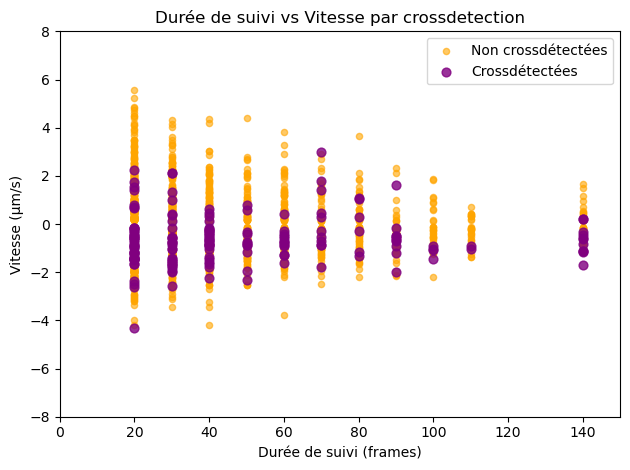

In [127]:

plt.scatter(df_non_cross_exclude['duree_suivi'], df_non_cross_exclude['speed'], 
                alpha=0.6, label='Non crossdétectées', color='orange', s=20)
plt.scatter(df_cross_exclude['duree_suivi'], df_cross_exclude['speed'], 
                alpha=0.8, label='Crossdétectées', color='purple', s=40)
plt.xlabel('Durée de suivi (frames)')
plt.ylabel('Vitesse (µm/s)')
plt.ylim(-8, 8)
plt.xlim(0, df_implemented_exclude['duree_suivi'].max() + 10)
plt.title('Durée de suivi vs Vitesse par crossdetection')
plt.legend()

plt.tight_layout()
plt.show()

In [128]:
# Préparation des données
df_cross = df_cross_exclude.copy()
df_non_cross = df_non_cross_exclude.copy()

print("=== ANALYSE STATISTIQUE DURÉE DE SUIVI vs VITESSE ===")
print("Analyse statistiques durée de suivi vs vitesse :")
print("Crossdétection vs Non crossdétection")
print()

print("Données de base:")
print(f"Particules crossdétectées: {len(df_cross)}")
print(f"Particules non crossdétectées: {len(df_non_cross)}")
print(f"Total: {len(df_implemented_exclude)}")
print()

# ==================== 1. ANALYSE GLOBALE ====================
print("1. Analyse globale :")

# Statistiques descriptives
duree_cross = df_cross['duree_suivi'].dropna()
duree_non_cross = df_non_cross['duree_suivi'].dropna()
vitesse_cross = df_cross['speed'].dropna()
vitesse_non_cross = df_non_cross['speed'].dropna()

print("Durée de suivi:")
print(f"Cross - Moyenne: {duree_cross.mean():.2f} frames, Médiane: {duree_cross.median():.2f} frames")
print(f"Cross - Écart-type: {duree_cross.std():.2f} frames")
print(f"Non Cross - Moyenne: {duree_non_cross.mean():.2f} frames, Médiane: {duree_non_cross.median():.2f} frames")
print(f"Non Cross - Écart-type: {duree_non_cross.std():.2f} frames")

print("\Vitesse:")
print(f"Cross - Moyenne: {vitesse_cross.mean():.3f} µm/s, Médiane: {vitesse_cross.median():.3f} µm/s")
print(f"Cross - Écart-type: {vitesse_cross.std():.3f} µm/s")
print(f"Non Cross - Moyenne: {vitesse_non_cross.mean():.3f} µm/s, Médiane: {vitesse_non_cross.median():.3f} µm/s")
print(f"Non Cross - Écart-type: {vitesse_non_cross.std():.3f} µm/s")

# Tests de comparaison pour la durée de suivi
print("\Tests de comparaison - durée de suivi :")
mann_whitney_duree = stats.mannwhitneyu(duree_cross, duree_non_cross, alternative='two-sided')
levene_duree = levene(duree_cross, duree_non_cross)
ks_duree = stats.ks_2samp(duree_cross, duree_non_cross)

print(f"Mann-Whitney U (durée): U={mann_whitney_duree.statistic:.0f}, p={mann_whitney_duree.pvalue:.2e}")
print(f"Levene (durée): statistique={levene_duree.statistic:.4f}, p={levene_duree.pvalue:.2e}")
print(f"Kolmogorov-Smirnov (durée): D={ks_duree.statistic:.4f}, p={ks_duree.pvalue:.2e}")

# Tests de comparaison pour la vitesse
print("\nTests de comparaison - vitesse :")
mann_whitney_vitesse = stats.mannwhitneyu(vitesse_cross, vitesse_non_cross, alternative='two-sided')
levene_vitesse = levene(vitesse_cross, vitesse_non_cross)
ks_vitesse = stats.ks_2samp(vitesse_cross, vitesse_non_cross)

print(f"Mann-Whitney U (vitesse): U={mann_whitney_vitesse.statistic:.0f}, p={mann_whitney_vitesse.pvalue:.2e}")
print(f"Levene (vitesse): statistique={levene_vitesse.statistic:.4f}, p={levene_vitesse.pvalue:.2e}")
print(f"Kolmogorov-Smirnov (vitesse): D={ks_vitesse.statistic:.4f}, p={ks_vitesse.pvalue:.2e}")

# Corrélations durée-vitesse
print("\nCorrélations durée-vitesse :")
# Pour les crossdétectées
if len(df_cross) > 3:
    corr_pearson_cross = pearsonr(df_cross['duree_suivi'], df_cross['speed'])
    corr_spearman_cross = spearmanr(df_cross['duree_suivi'], df_cross['speed'])
    print(f"Crossdétectées - Pearson: r={corr_pearson_cross.statistic:.4f}, p={corr_pearson_cross.pvalue:.2e}")
    print(f"Crossdétectées - Spearman: ρ={corr_spearman_cross.statistic:.4f}, p={corr_spearman_cross.pvalue:.2e}")

# Pour les non crossdétectées
if len(df_non_cross) > 3:
    corr_pearson_non_cross = pearsonr(df_non_cross['duree_suivi'], df_non_cross['speed'])
    corr_spearman_non_cross = spearmanr(df_non_cross['duree_suivi'], df_non_cross['speed'])
    print(f"Non crossdétectées - Pearson: r={corr_pearson_non_cross.statistic:.4f}, p={corr_pearson_non_cross.pvalue:.2e}")
    print(f"Non crossdétectées - Spearman: ρ={corr_spearman_non_cross.statistic:.4f}, p={corr_spearman_non_cross.pvalue:.2e}")

print("\n" + "="*80)

# ==================== 2. ANALYSE PAR MODALITÉ ====================
print("2. Analyse par modalité :")

modalites = {1: "OPD", 2: "Fluorescence"}
resultats_modalites = {}

for modalite_id, modalite_nom in modalites.items():
    print(f"\n--- {modalite_nom} ---")
    
    # Sous-ensembles par modalité
    df_cross_mod = df_cross[df_cross['ID_modality'] == modalite_id]
    df_non_cross_mod = df_non_cross[df_non_cross['ID_modality'] == modalite_id]
    
    if len(df_cross_mod) == 0 and len(df_non_cross_mod) == 0:
        print(f"Aucune donnée pour {modalite_nom}")
        continue
    
    print(f"Particules crossdétectées: {len(df_cross_mod)}")
    print(f"Particules non crossdétectées: {len(df_non_cross_mod)}")
    
    # Statistiques descriptives par modalité
    if len(df_cross_mod) > 0:
        duree_cross_mod = df_cross_mod['duree_suivi'].dropna()
        vitesse_cross_mod = df_cross_mod['speed'].dropna()
        print(f"Cross - Durée moyenne: {duree_cross_mod.mean():.2f} frames")
        print(f"Cross - Vitesse moyenne: {vitesse_cross_mod.mean():.3f} µm/s")
    
    if len(df_non_cross_mod) > 0:
        duree_non_cross_mod = df_non_cross_mod['duree_suivi'].dropna()
        vitesse_non_cross_mod = df_non_cross_mod['speed'].dropna()
        print(f"Non Cross - Durée moyenne: {duree_non_cross_mod.mean():.2f} frames")
        print(f"Non Cross - Vitesse moyenne: {vitesse_non_cross_mod.mean():.3f} µm/s")
    
    # Tests statistiques par modalité
    if len(df_cross_mod) > 3 and len(df_non_cross_mod) > 3:
        # Test durée
        mann_whitney_duree_mod = stats.mannwhitneyu(duree_cross_mod, duree_non_cross_mod, alternative='two-sided')
        print(f"Mann-Whitney durée: p={mann_whitney_duree_mod.pvalue:.2e}")
        
        # Test vitesse
        mann_whitney_vitesse_mod = stats.mannwhitneyu(vitesse_cross_mod, vitesse_non_cross_mod, alternative='two-sided')
        print(f"Mann-Whitney vitesse: p={mann_whitney_vitesse_mod.pvalue:.2e}")
        
        # Corrélations par modalité
        if len(df_cross_mod) > 3:
            corr_cross_mod = spearmanr(df_cross_mod['duree_suivi'], df_cross_mod['speed'])
            print(f"Corrélation cross durée-vitesse: ρ={corr_cross_mod.statistic:.4f}, p={corr_cross_mod.pvalue:.2e}")
        
        if len(df_non_cross_mod) > 3:
            corr_non_cross_mod = spearmanr(df_non_cross_mod['duree_suivi'], df_non_cross_mod['speed'])
            print(f"Corrélation non cross durée-vitesse: ρ={corr_non_cross_mod.statistic:.4f}, p={corr_non_cross_mod.pvalue:.2e}")
    
    resultats_modalites[modalite_id] = {
        'cross_mod': df_cross_mod,
        'non_cross_mod': df_non_cross_mod,
        'modalite_nom': modalite_nom
    }

print("\n" + "="*80)

=== ANALYSE STATISTIQUE DURÉE DE SUIVI vs VITESSE ===
Analyse statistiques durée de suivi vs vitesse :
Crossdétection vs Non crossdétection

Données de base:
Particules crossdétectées: 170
Particules non crossdétectées: 2061
Total: 2231

1. Analyse globale :
Durée de suivi:
Cross - Moyenne: 50.29 frames, Médiane: 40.00 frames
Cross - Écart-type: 33.31 frames
Non Cross - Moyenne: 42.76 frames, Médiane: 30.00 frames
Non Cross - Écart-type: 27.42 frames
\Vitesse:
Cross - Moyenne: -0.635 µm/s, Médiane: -0.755 µm/s
Cross - Écart-type: 1.015 µm/s
Non Cross - Moyenne: -0.185 µm/s, Médiane: -0.343 µm/s
Non Cross - Écart-type: 1.292 µm/s
\Tests de comparaison - durée de suivi :
Mann-Whitney U (durée): U=197564, p=4.55e-03
Levene (durée): statistique=6.5302, p=1.07e-02
Kolmogorov-Smirnov (durée): D=0.1067, p=5.16e-02

Tests de comparaison - vitesse :
Mann-Whitney U (vitesse): U=136280, p=1.44e-06
Levene (vitesse): statistique=12.0028, p=5.41e-04
Kolmogorov-Smirnov (vitesse): D=0.2290, p=1.02e-07

3. Visualisations :


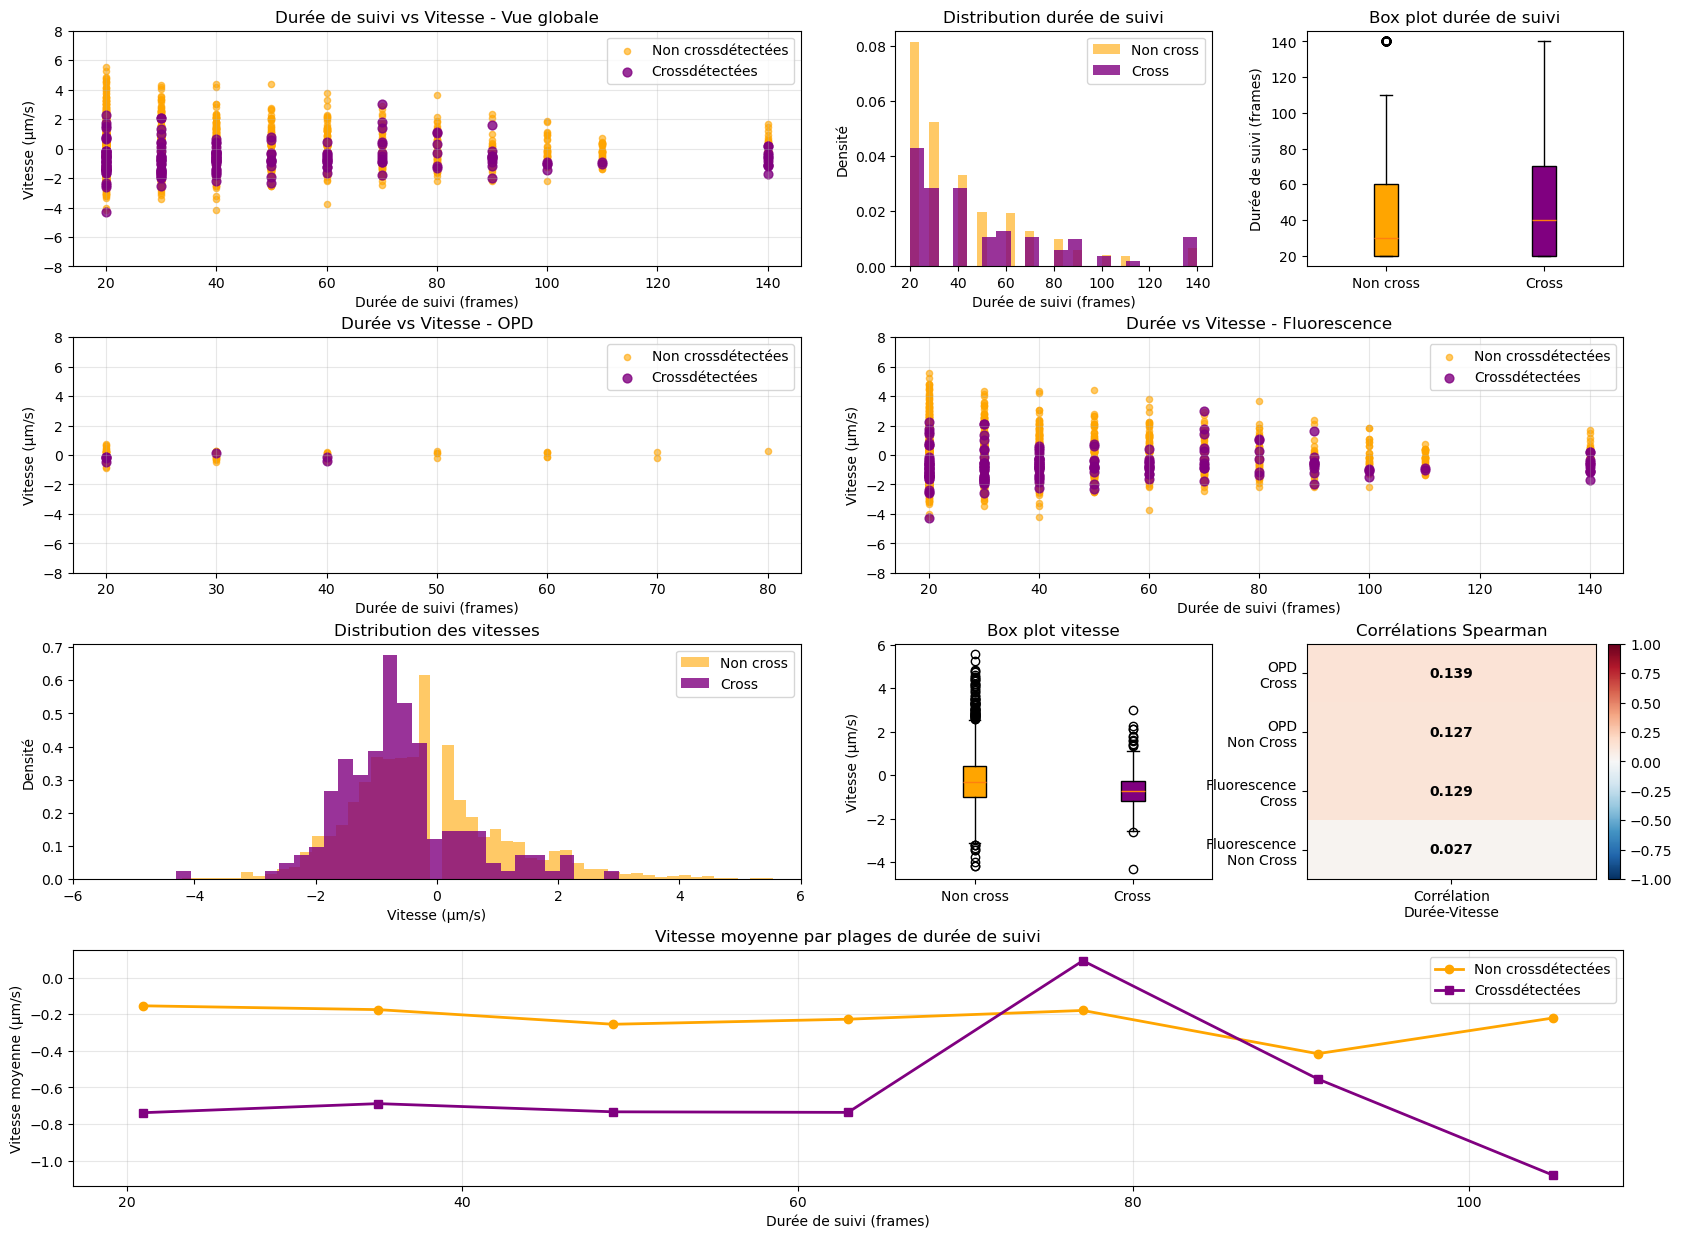

In [129]:
print("3. Visualisations :")

# Configuration de la figure principale
fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(4, 4, hspace=0.3, wspace=0.3)

# 1. Scatter plot global
ax1 = fig.add_subplot(gs[0, :2])
ax1.scatter(df_non_cross['duree_suivi'], df_non_cross['speed'], 
           alpha=0.6, label='Non crossdétectées', color='orange', s=20)
ax1.scatter(df_cross['duree_suivi'], df_cross['speed'], 
           alpha=0.8, label='Crossdétectées', color='purple', s=40)
ax1.set_xlabel('Durée de suivi (frames)')
ax1.set_ylabel('Vitesse (µm/s)')
ax1.set_ylim(-8, 8)
ax1.set_title('Durée de suivi vs Vitesse - Vue globale')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Histogrammes durée de suivi
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(duree_non_cross, bins=30, alpha=0.6, label='Non cross', color='orange', density=True)
ax2.hist(duree_cross, bins=20, alpha=0.8, label='Cross', color='purple', density=True)
ax2.set_xlabel('Durée de suivi (frames)')
ax2.set_ylabel('Densité')
ax2.set_title('Distribution durée de suivi')
ax2.legend()

# 3. Box plots durée
ax3 = fig.add_subplot(gs[0, 3])
box_data_duree = [duree_non_cross, duree_cross]
box_plot_duree = ax3.boxplot(box_data_duree, labels=['Non cross', 'Cross'], patch_artist=True)
box_plot_duree['boxes'][0].set_facecolor('orange')
box_plot_duree['boxes'][1].set_facecolor('purple')
ax3.set_ylabel('Durée de suivi (frames)')
ax3.set_title('Box plot durée de suivi')

# 4. Scatter plots par modalité
for i, (modalite_id, modalite_nom) in enumerate(modalites.items()):
    if modalite_id not in resultats_modalites:
        continue
    
    df_cross_mod = resultats_modalites[modalite_id]['cross_mod']
    df_non_cross_mod = resultats_modalites[modalite_id]['non_cross_mod']
    
    ax = fig.add_subplot(gs[1, i*2:(i+1)*2])
    
    if len(df_non_cross_mod) > 0:
        ax.scatter(df_non_cross_mod['duree_suivi'], df_non_cross_mod['speed'], 
                  alpha=0.6, label='Non crossdétectées', color='orange', s=20)
    if len(df_cross_mod) > 0:
        ax.scatter(df_cross_mod['duree_suivi'], df_cross_mod['speed'], 
                  alpha=0.8, label='Crossdétectées', color='purple', s=40)
    
    ax.set_xlabel('Durée de suivi (frames)')
    ax.set_ylabel('Vitesse (µm/s)')
    ax.set_ylim(-8, 8)
    ax.set_title(f'Durée vs Vitesse - {modalite_nom}')
    ax.legend()
    ax.grid(True, alpha=0.3)

# 5. Histogrammes vitesse globaux
ax5 = fig.add_subplot(gs[2, :2])
ax5.hist(vitesse_non_cross, bins=50, alpha=0.6, label='Non cross', color='orange', density=True)
ax5.hist(vitesse_cross, bins=30, alpha=0.8, label='Cross', color='purple', density=True)
ax5.set_xlabel('Vitesse (µm/s)')
ax5.set_ylabel('Densité')
ax5.set_xlim(-6, 6)
ax5.set_title('Distribution des vitesses')
ax5.legend()

# 6. Box plots vitesse
ax6 = fig.add_subplot(gs[2, 2])
box_data_vitesse = [vitesse_non_cross, vitesse_cross]
box_plot_vitesse = ax6.boxplot(box_data_vitesse, labels=['Non cross', 'Cross'], patch_artist=True)
box_plot_vitesse['boxes'][0].set_facecolor('orange')
box_plot_vitesse['boxes'][1].set_facecolor('purple')
ax6.set_ylabel('Vitesse (µm/s)')
ax6.set_title('Box plot vitesse')

# 7. Heatmap corrélations par modalité
ax7 = fig.add_subplot(gs[2, 3])
correlations_data = []
labels_corr = []

for modalite_id, modalite_nom in modalites.items():
    if modalite_id not in resultats_modalites:
        continue
    
    df_cross_mod = resultats_modalites[modalite_id]['cross_mod']
    df_non_cross_mod = resultats_modalites[modalite_id]['non_cross_mod']
    
    if len(df_cross_mod) > 3:
        corr_cross = spearmanr(df_cross_mod['duree_suivi'], df_cross_mod['speed']).statistic
        correlations_data.append(corr_cross)
        labels_corr.append(f'{modalite_nom}\nCross')
    
    if len(df_non_cross_mod) > 3:
        corr_non_cross = spearmanr(df_non_cross_mod['duree_suivi'], df_non_cross_mod['speed']).statistic
        correlations_data.append(corr_non_cross)
        labels_corr.append(f'{modalite_nom}\nNon Cross')

if correlations_data:
    corr_matrix = np.array(correlations_data).reshape(-1, 1)
    im = ax7.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax7.set_yticks(range(len(labels_corr)))
    ax7.set_yticklabels(labels_corr)
    ax7.set_xticks([0])
    ax7.set_xticklabels(['Corrélation\nDurée-Vitesse'])
    ax7.set_title('Corrélations Spearman')
    
    # Ajouter les valeurs sur la heatmap
    for i in range(len(correlations_data)):
        ax7.text(0, i, f'{correlations_data[i]:.3f}', 
                ha='center', va='center', color='black', fontweight='bold')
    
    plt.colorbar(im, ax=ax7, fraction=0.046, pad=0.04)

# 8. Analyse par plages de durée
ax8 = fig.add_subplot(gs[3, :])

# Créer des bins pour la durée de suivi
duree_max = df_implemented_exclude['duree_suivi'].max()
bins_duree = np.linspace(0, duree_max, 11)  # 10 bins
bin_centers = (bins_duree[:-1] + bins_duree[1:]) / 2

vitesse_moyenne_cross = []
vitesse_moyenne_non_cross = []
count_cross = []
count_non_cross = []

for i in range(len(bins_duree)-1):
    mask_cross = (df_cross['duree_suivi'] >= bins_duree[i]) & (df_cross['duree_suivi'] < bins_duree[i+1])
    mask_non_cross = (df_non_cross['duree_suivi'] >= bins_duree[i]) & (df_non_cross['duree_suivi'] < bins_duree[i+1])
    
    vitesses_cross_bin = df_cross[mask_cross]['speed'].dropna()
    vitesses_non_cross_bin = df_non_cross[mask_non_cross]['speed'].dropna()
    
    vitesse_moyenne_cross.append(vitesses_cross_bin.mean() if len(vitesses_cross_bin) > 0 else np.nan)
    vitesse_moyenne_non_cross.append(vitesses_non_cross_bin.mean() if len(vitesses_non_cross_bin) > 0 else np.nan)
    count_cross.append(len(vitesses_cross_bin))
    count_non_cross.append(len(vitesses_non_cross_bin))

ax8.plot(bin_centers, vitesse_moyenne_non_cross, 'o-', label='Non crossdétectées', color='orange', linewidth=2)
ax8.plot(bin_centers, vitesse_moyenne_cross, 's-', label='Crossdétectées', color='purple', linewidth=2)
ax8.set_xlabel('Durée de suivi (frames)')
ax8.set_ylabel('Vitesse moyenne (µm/s)')
ax8.set_title('Vitesse moyenne par plages de durée de suivi')
ax8.legend()
ax8.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [130]:
print("4. Analyse statistique avancée :")

# Tests de normalité
print("\nTESTS DE NORMALITÉ:")
shapiro_duree_cross = stats.shapiro(duree_cross)
shapiro_duree_non_cross = stats.shapiro(duree_non_cross)
shapiro_vitesse_cross = stats.shapiro(vitesse_cross)
shapiro_vitesse_non_cross = stats.shapiro(vitesse_non_cross)

print(f"Durée Cross - Shapiro: W={shapiro_duree_cross.statistic:.4f}, p={shapiro_duree_cross.pvalue:.2e}")
print(f"Durée Non Cross - Shapiro: W={shapiro_duree_non_cross.statistic:.4f}, p={shapiro_duree_non_cross.pvalue:.2e}")
print(f"Vitesse Cross - Shapiro: W={shapiro_vitesse_cross.statistic:.4f}, p={shapiro_vitesse_cross.pvalue:.2e}")
print(f"Vitesse Non Cross - Shapiro: W={shapiro_vitesse_non_cross.statistic:.4f}, p={shapiro_vitesse_non_cross.pvalue:.2e}")

# Analyse des quantiles
print("\n Analyse des quantiles :")
quantiles = [0.25, 0.5, 0.75, 0.9, 0.95]

print("Durée de suivi (frames):")
print(f"{'Quantile':<10} {'Non Cross':<12} {'Cross':<12} {'Différence':<12}")
for q in quantiles:
    q_non_cross = np.quantile(duree_non_cross, q)
    q_cross = np.quantile(duree_cross, q)
    diff = q_cross - q_non_cross
    print(f"{q:<10} {q_non_cross:<12.1f} {q_cross:<12.1f} {diff:<12.1f}")

print("\n Vitesse (µm/s):")
print(f"{'Quantile':<10} {'Non Cross':<12} {'Cross':<12} {'Différence':<12}")
for q in quantiles:
    q_non_cross = np.quantile(vitesse_non_cross, q)
    q_cross = np.quantile(vitesse_cross, q)
    diff = q_cross - q_non_cross
    print(f"{q:<10} {q_non_cross:<12.3f} {q_cross:<12.3f} {diff:<12.3f}")

# Calcul des tailles d'effet
print("\n Tailles d'effet :")
n1_duree, n2_duree = len(duree_non_cross), len(duree_cross)
n1_vitesse, n2_vitesse = len(vitesse_non_cross), len(vitesse_cross)

if mann_whitney_duree.pvalue > 0:
    z_duree = stats.norm.ppf(mann_whitney_duree.pvalue/2) if mann_whitney_duree.pvalue > 0 else 0
    effect_size_duree = abs(z_duree) / np.sqrt(n1_duree + n2_duree)
    print(f"Taille d'effet durée (r): {effect_size_duree:.3f}")

if mann_whitney_vitesse.pvalue > 0:
    z_vitesse = stats.norm.ppf(mann_whitney_vitesse.pvalue/2) if mann_whitney_vitesse.pvalue > 0 else 0
    effect_size_vitesse = abs(z_vitesse) / np.sqrt(n1_vitesse + n2_vitesse)
    print(f"Taille d'effet vitesse (r): {effect_size_vitesse:.3f}")

print("\n" + "="*80)
print("Résumé des conclusions statistiques :")

# Conclusions basées sur les tests statistiques
alpha = 0.05

print("1. Comparaisons globales :")
if mann_whitney_duree.pvalue < alpha:
    if duree_cross.median() > duree_non_cross.median():
        print(f"   - Les particules crossdétectées ont une durée de suivi significativement PLUS LONGUE")
    else:
        print(f"   - Les particules crossdétectées ont une durée de suivi significativement PLUS COURTE")
    print(f"     (p = {mann_whitney_duree.pvalue:.2e})")
else:
    print(f"   - Pas de différence significative de durée de suivi (p = {mann_whitney_duree.pvalue:.2e})")

if mann_whitney_vitesse.pvalue < alpha:
    if vitesse_cross.median() > vitesse_non_cross.median():
        print(f"   - Les particules crossdétectées ont une vitesse significativement PLUS ÉLEVÉE")
    else:
        print(f"   - Les particules crossdétectées ont une vitesse significativement PLUS FAIBLE")
    print(f"     (p = {mann_whitney_vitesse.pvalue:.2e})")
else:
    print(f"   - Pas de différence significative de vitesse (p = {mann_whitney_vitesse.pvalue:.2e})")

print("\n2. Corrélation durée-vitesse:")
if len(df_cross) > 3:
    if corr_spearman_cross.pvalue < alpha:
        direction = "positive" if corr_spearman_cross.statistic > 0 else "négative"
        print(f"   - Corrélation {direction} significative pour les crossdétectées (ρ = {corr_spearman_cross.statistic:.3f})")
    else:
        print(f"   - Pas de corrélation significative pour les crossdétectées")

if len(df_non_cross) > 3:
    if corr_spearman_non_cross.pvalue < alpha:
        direction = "positive" if corr_spearman_non_cross.statistic > 0 else "négative"
        print(f"   - Corrélation {direction} significative pour les non crossdétectées (ρ = {corr_spearman_non_cross.statistic:.3f})")
    else:
        print(f"   - Pas de corrélation significative pour les non crossdétectées")

print("\n3. Différences par modalités:")
for modalite_id, modalite_nom in modalites.items():
    if modalite_id in resultats_modalites:
        df_cross_mod = resultats_modalites[modalite_id]['cross_mod']
        df_non_cross_mod = resultats_modalites[modalite_id]['non_cross_mod']
        
        if len(df_cross_mod) > 0 and len(df_non_cross_mod) > 0:
            duree_diff = df_cross_mod['duree_suivi'].mean() - df_non_cross_mod['duree_suivi'].mean()
            vitesse_diff = df_cross_mod['speed'].mean() - df_non_cross_mod['speed'].mean()
            print(f"   - {modalite_nom}: Δ durée = {duree_diff:.1f} frames, Δ vitesse = {vitesse_diff:.3f} µm/s")

4. Analyse statistique avancée :

TESTS DE NORMALITÉ:
Durée Cross - Shapiro: W=0.8191, p=3.05e-13
Durée Non Cross - Shapiro: W=0.7907, p=1.60e-45
Vitesse Cross - Shapiro: W=0.9490, p=8.18e-06
Vitesse Non Cross - Shapiro: W=0.9630, p=1.54e-22

 Analyse des quantiles :
Durée de suivi (frames):
Quantile   Non Cross    Cross        Différence  
0.25       20.0         20.0         0.0         
0.5        30.0         40.0         10.0        
0.75       60.0         70.0         10.0        
0.9        80.0         91.0         11.0        
0.95       100.0        140.0        40.0        

 Vitesse (µm/s):
Quantile   Non Cross    Cross        Différence  
0.25       -1.000       -1.200       -0.200      
0.5        -0.343       -0.755       -0.412      
0.75       0.425        -0.277       -0.702      
0.9        1.550        0.655        -0.895      
0.95       2.233        1.408        -0.825      

 Tailles d'effet :
Taille d'effet durée (r): 0.060
Taille d'effet vitesse (r): 0.102

Ré